In [1]:
# Purpose: Import necessary libraries for data analysis, visualization, and geographic mapping.
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import re
from copy import deepcopy
import json
import us

In [2]:
#Purpose: latex fonts in figures...
import os
import shutil
import matplotlib.pyplot as plt

# 1. Force the system MacTeX path to the front of the list
mactex_path = "/Library/TeX/texbin"
os.environ["PATH"] = mactex_path + os.pathsep + os.environ["PATH"]

# 2. Verify that Python sees the 2024 version now
print(f"Using latex at: {shutil.which('latex')}")

# 3. Setup Matplotlib
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Using latex at: /Library/TeX/texbin/latex


In [ ]:
#Purpose: Test LaTeX rendering in Matplotlib
import matplotlib.pyplot as plt

# Apply your settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1])
plt.title(r"LaTeX Test: $\alpha + \beta = \gamma$")
plt.xlabel(r"Value of $x^2$")
plt.ylabel(r"Result of $\int f(x) dx$")
plt.show()

In [4]:
# Purpose: Define a function to map BV-BRC genome data to a format compatible with Nextstrain metadata.
def map_bvbrc_to_nextstrain(bvbrc_df):
    """
    Maps a pandas DataFrame representing BV-BRC genome data to a DataFrame
    suitable for appending to a Nextstrain metadata DataFrame.

    Args:
        bvbrc_df (pd.DataFrame): Pandas DataFrame representing BV-BRC genome data.

    Returns:
        pd.DataFrame: Pandas DataFrame formatted to be appended to a Nextstrain
                      metadata DataFrame.  Returns an empty DataFrame if
                      input DataFrame is empty.
    """

    if bvbrc_df.empty:
        return pd.DataFrame()  # Return an empty DataFrame if input is empty

    nextstrain_data = {
        'data_source': bvbrc_df['Genome ID'].apply(lambda x: 'bvbrc' if pd.isna(x) else 'bvbrc'),
        'strain': bvbrc_df['candidate_strain'],
        'virus': 'avian_flu',
        'isolate_id': bvbrc_df['GenBank Accessions'],
        'date': bvbrc_df['Collection Date'],
        'region': "North America",
        'country': "USA",
        'division': bvbrc_df['Geographic Location'].fillna('').str.replace("USA: ", "", regex=False),
        'location': '?',  #Not mapping any of BVBRC source data
        'host': bvbrc_df['Host Name'],
        'domestic_status': '?', # Not mapping any of BVBRC source data
        'subtype': "h5n1",
        'originating_lab': '?',  # Store value in Submitting_lab
        'submitting_lab': '?',# To Additional Metadata
        'authors': '?',
        'PMID': '?', #reference instead
        'gisaid_clade': '?',
        'h5_clade': '?',
        'genbank_accession': bvbrc_df['GenBank Accessions'],
        'sra_accessions': bvbrc_df['SRA Accession'],
        'date_released': '?', # To Comments
        'n_segments': '?',# To Additional Metadata
        'genoflu': bvbrc_df['Subclade'],
        'genoflu_PB2': '?', #To Additional Metadata
        'genoflu_PB1': '?', # To Additional Metadata
        'genoflu_PA': '?', # To Additional Metadata
        'genoflu_HA': '?', # To Additional Metadata
        'genoflu_NP': '?', # To Additional Metadata
        'genoflu_NA': '?', # To Additional Metadata
        'genoflu_MP': '?', # To Additional Metadata
        'genoflu_NS': '?',  # To Additional Metadata
        'fasta_id': bvbrc_df.apply(lambda x: f"accn|{x['GenBank Accessions']}" if pd.notna(x['GenBank Accessions']) else f"accn|{x['Genome ID']}.con.0001", axis=1) # To Additional Metadata
        }

    nextstrain_df = pd.DataFrame(nextstrain_data)

    # Handle missing values by filling with empty string
    nextstrain_df = nextstrain_df.fillna('')
    nextstrain_df['date_dt'] = pd.to_datetime(nextstrain_df['date'], format='%Y-%m-%d', errors='coerce')
    #for rows with date_dt == NaT retry using format that looks like 11-Aug-2023
    nextstrain_df.loc[nextstrain_df['date_dt'].isna(), 'date_dt'] = pd.to_datetime(nextstrain_df.loc[nextstrain_df['date_dt'].isna(), 'date'], format='%d-%b-%Y', errors='coerce')
    nextstrain_df.loc[~nextstrain_df['date_dt'].isna(), 'date'] = nextstrain_df['date_dt'].dt.strftime('%Y-%m-%d')
    #split date by "-" if there is two parts fill out for the third, if one part add -XX-XX
    nextstrain_df['date'] = nextstrain_df['date'].apply(lambda x: x+"-XX" if len(x.split("-"))==2 else x)
    nextstrain_df['date'] = nextstrain_df['date'].apply(lambda x: x+"-XX-XX" if len(x.split("-"))==1 else x)


    return nextstrain_df

In [6]:
# Purpose: Read in state-level risk scores and perform initial data cleaning and transformation.
st_risk_scores = pd.read_csv('../../risk/results/state_comprehensive.csv', dtype={'state_code': str})
#map state_code to lowercase state name
state_names = []
print(st_risk_scores['time'].max())
print(st_risk_scores.head())
na_codes = set()
for code in st_risk_scores['state_code']:
    #if single digt, add leading 0
    if len(code) == 1:
        code = '0' + code
    result=us.states.lookup(code)
    if result is not None:
        state_names.append(result.name)
    else:
        state_names.append('NA')
        if code not in na_codes:
            print(code)
            na_codes.add(code)
st_risk_scores['state'] = state_names
format="new_format"
#old format
if format=="old_format":
    st_risk_scores['date']=pd.to_datetime(st_risk_scores['month'], format='%Y-%m')
else:
    st_risk_scores['date']=pd.to_datetime(st_risk_scores['time'], format='%Y-%m')
    st_risk_scores['month']=st_risk_scores['time']
    st_risk_scores['risk']=st_risk_scores['1']

#for the subtype column replace "milk" with "dairy"
st_risk_scores['subtype'] = st_risk_scores['subtype'].replace({'milk': 'dairy'})
st_risk_scores.head()

2025-12
  state_code     time       subtype         0         1         2         3  \
0          1  2022-01  ckn-broilers  0.052730  0.033591  0.025342  0.012875   
1          1  2022-01    ckn-layers  0.049493  0.031013  0.021865  0.010944   
2          1  2022-01         ducks  0.000000  0.000000  0.000000  0.000000   
3          1  2022-01          milk  0.000028  0.000019  0.000017  0.000009   
4          1  2022-01       turkeys  0.003186  0.002042  0.001491  0.000814   

          4         5  
0  0.011683  0.008219  
1  0.010154  0.007074  
2  0.000000  0.000000  
3  0.000009  0.000005  
4  0.000819  0.000535  
11


,state_code,time,subtype,0,1,2,3,4,5,state,date,month,risk
0,1,2022-01,ckn-broilers,0.052730,0.033591,0.025342,0.012875,0.011683,0.008219,Alabama,2022-01-01,2022-01,0.033591
1,1,2022-01,ckn-layers,0.049493,0.031013,0.021865,0.010944,0.010154,0.007074,Alabama,2022-01-01,2022-01,0.031013
2,1,2022-01,ducks,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Alabama,2022-01-01,2022-01,0.000000
3,1,2022-01,dairy,0.000028,0.000019,0.000017,0.000009,0.000009,0.000005,Alabama,2022-01-01,2022-01,0.000019
4,1,2022-01,turkeys,0.003186,0.002042,0.001491,0.000814,0.000819,0.000535,Alabama,2022-01-01,2022-01,0.002042


In [7]:
# Purpose: Display the head of the conditional risk scores DataFrame.
len(st_risk_scores.state_code.unique())

52

In [ ]:
import matplotlib as mpl
import os
import shutil

# Identify the cache directory
cache_dir = mpl.get_cachedir()

# Clear the directory
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache cleared at: {cache_dir}")
else:
    print("No cache directory found.")

import shutil

programs = ["latex", "pdflatex", "dvipng"]
for prog in programs:
    path = shutil.which(prog)
    print(f"{prog}: {'FOUND at ' + path if path else 'NOT FOUND'}")

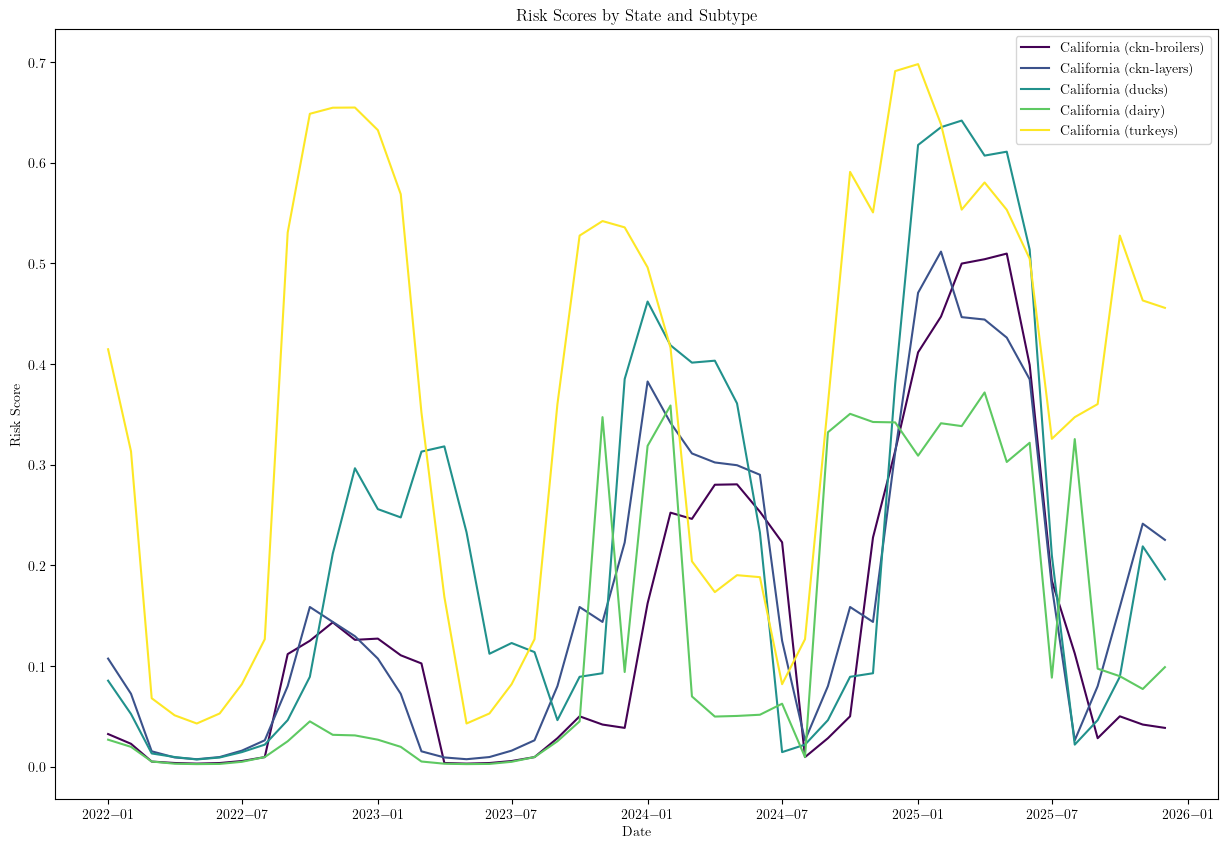

In [9]:
# Purpose: Filter for the top state by risk score and plot risk scores over time by subtype for that state.
#calculate the top 10 states by risk score
top_10_states = st_risk_scores.groupby('state')['risk'].max().nlargest(1).index.tolist()
#filter the dataframe to only include the top 10 states
st_risk_scores_filter = st_risk_scores[st_risk_scores['state'].isin(['California'])]

#plot the st_risk_scores.risk per state over time, grouped and colored by subtype
fig, ax = plt.subplots(figsize=(15, 10))
ax.set_title('Risk Scores by State and Subtype')
ax.set_xlabel('Date')
ax.set_ylabel('Risk Score')

#plot each state and subtype combination in a different color
colors = plt.cm.viridis(np.linspace(0, 1, len(st_risk_scores_filter['subtype'].unique())))
for i, subtype in enumerate(st_risk_scores_filter['subtype'].unique()):
    subtype_df = st_risk_scores_filter[st_risk_scores_filter['subtype'] == subtype]
    for state in subtype_df['state'].unique():
        state_df = subtype_df[subtype_df['state'] == state]
        ax.plot(state_df['date'], state_df['risk'], label=f"{state} ({subtype})", color=colors[i])

ax.legend()
plt.show()

In [9]:
# Purpose: Read in unconditional risk scores and perform initial data cleaning and transformation.
unc_risk_scores = pd.read_csv('../../risk/results/state_spillover.csv', dtype={'state_code': str})
#map state_code to lowercase state name

state_names = []
na_codes = set()
print(unc_risk_scores['time'].max())
print(unc_risk_scores.head())
for code in unc_risk_scores['state_code']:
    #if single digt, add leading 0
    if len(code) == 1:
        code = '0' + code
    result=us.states.lookup(code)
    if result is not None:
        state_names.append(result.name)
    else:
        state_names.append('NA')
        if code not in na_codes:
            print(code)
            na_codes.add(code)

unc_risk_scores['state'] = state_names
format="new_format"
#old format
if format=="old_format":
    unc_risk_scores['date']=pd.to_datetime(unc_risk_scores['month'], format='%Y-%m')
else:
    unc_risk_scores['date']=pd.to_datetime(unc_risk_scores['time'], format='%Y-%m')
    unc_risk_scores['month']=unc_risk_scores['time']
    unc_risk_scores['risk']=unc_risk_scores['1']

unc_risk_scores['subtype'] = unc_risk_scores['subtype'].replace({'milk': 'dairy'})

unc_risk_scores.head()

2025-12
  state_code     time       subtype         0         1         2         3  \
0          1  2022-01  ckn-broilers  0.052730  0.033591  0.025342  0.012875   
1          1  2022-01    ckn-layers  0.049493  0.031013  0.021865  0.010944   
2          1  2022-01         ducks  0.000000  0.000000  0.000000  0.000000   
3          1  2022-01          milk  0.000028  0.000019  0.000017  0.000009   
4          1  2022-01       turkeys  0.003186  0.002042  0.001491  0.000814   

          4         5  
0  0.011683  0.008219  
1  0.010154  0.007074  
2  0.000000  0.000000  
3  0.000009  0.000005  
4  0.000819  0.000535  
11


,state_code,time,subtype,0,1,2,3,4,5,state,date,month,risk
0,1,2022-01,ckn-broilers,0.052730,0.033591,0.025342,0.012875,0.011683,0.008219,Alabama,2022-01-01,2022-01,0.033591
1,1,2022-01,ckn-layers,0.049493,0.031013,0.021865,0.010944,0.010154,0.007074,Alabama,2022-01-01,2022-01,0.031013
2,1,2022-01,ducks,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Alabama,2022-01-01,2022-01,0.000000
3,1,2022-01,dairy,0.000028,0.000019,0.000017,0.000009,0.000009,0.000005,Alabama,2022-01-01,2022-01,0.000019
4,1,2022-01,turkeys,0.003186,0.002042,0.001491,0.000814,0.000819,0.000535,Alabama,2022-01-01,2022-01,0.002042


In [10]:
# Purpose: Define a function to normalize BV-BRC strain names for consistency with Nextstrain.
import re

def normalize_strain(bv_brc_strain, mode=0):
    """
    Normalizes a BV_BRC strain name to match Nextstrain formatting.

    Args:
        bv_brc_strain: The BV_BRC strain name.

    Returns:
        The normalized strain name, or the original if no changes were made.
    """
    normalized_strain = bv_brc_strain

    # Lowercase location names for consistency
    parts = normalized_strain.split("/")

    #if len(parts) >= 3:
    #     try:
    #        parts[2] = parts[2][:4] #Keep year only
    #    except IndexError: # Handles cases where the location is missing
    #          pass
    #parts[1]=parts[1].lower().replace(" ", "")
    normalized_strain = "/".join(parts)
    if mode == 0:
        parts[2]=parts[2].replace(" ", "")
        normalized_strain = "/".join(parts)
    elif mode == 1:
        parts[1]=parts[1].replace(" ", "")
        parts[2]=parts[2].replace(" ", "")
        normalized_strain = "/".join(parts)
    normalized_strain = normalized_strain.replace("'", "")
    normalized_strain = normalized_strain.replace("\\", "")
    return normalized_strain

In [11]:
# Purpose: Define a dictionary to map various host names to standardized categories and a function to apply this mapping.
#Categorize Host 2
host_convert={
"Chicken": {"chicken"},
"Turkey": {"turkey"},
"Avian-Domestic-Other":{"domesticgoose",  "peafowl"},
"Domestic-Duck": {"domesticduck"},
"Nonhuman-mammal": {"feline", "goat", "skunk", "raccoon",  "mountainlion",  "cat", "redfox", "housemouse", "bear",
                     "alpaca", "tiger", "ferret", "lynx", "geoffroyscat", "serval", "savannahcat", "bobcat", "lion", "fox",
                       "HouseMouse",  "RedFox", "Alpaca","Mustelaputoriusfuro","COUGAR","domesticcat","nonhuman mammal", "nonhuman-mammal",
                       'pig', 'mustela putorius furo', 'mountain lion', 'domestic cat', 'red fox', "mountain-lion", "mink", "dolphin", "weasel", "house mouse", "felis catus"},
"Cattle": {"bovine", "cattle", "dairycattle", "dairycow", "cattlemilkproduct", 'dairy cow', 'bostaurus', "dairy cattle", 'striped skunk', 'StripedSkunk'},
"Human":{"human","homo sapiens"},
"Avian-Wild": {"hoodedmerganser", "woodduck", "blackbird", "canadagoose", "snowgoose", "greathornedowl",
                      "redtailedhawk", "crow", "harrishawk", "westerngull", "canadagoose", "duck", "grackle", "pigeon",
                      "americancrow", "mallard", "muteswan", "peregrinefalcon", "baldeagle", "commonraven", "snowgoose",
                      "turkeyvulture", "redheadduck", "redtailed_hawk", "sanderling", "ruddyturnstone", "grackle", "hawk",
                      "goose", "housesparrow", "wildbird", "americanrobin", "hornedgrebe", "eurasiancollareddove", "peafowl",
                      "guineafowl", "emu", "dove", "westernsandpiper", "americanwigeon", "blackbilledmagpie", "westernkingbird",
                      "pheasant", "rockpigeon", "whitewingeddove", "american white pelican", "red tailed hawk", "ruddyturnstone",
                      "greathornedowl", "peregrinefalcon", "baldeagle", "commonraven", "turkeyvulture", "mallard",
                      "mountainlion", "westerngull", "common grackle", "white winged scoter", "commoneider", "commonloon",
                      "greatblackbackedgull", "herringgull", "brandtgoose", "blackscoter", "surfscoter", "canadagoose",
                      "commonraven", "wildgoose", "ostrich", "swan", "whitestork", "seagull", "great white pelican",
                      "eurasiangoshawk", "greylaggoose", "americanrobin", "house parrow", "harrishawk",
                      "washington", "americanrow", "red-tailed_hawk", "canada_goose", "snow_goose", "red-tailedhawk", "harris-hawk", "americanwhitepelican", "white-wingeddove", "wild-bird",
                      'Pelican', 'White-facedIbis', 'CRANE',
                      'SNOWYOWL', 'SWALLOW', 'CACKLINGGOOSE', 'TRUMPETERSWAN',
                      'GREEN-WINGEDTEAL', 'GADWALL', 'BLUE-WINGEDTEAL',
                      'NORTHERNSHOVELER', 'CRESTEDCARACARA', 'FLAMINGO',
                      'white-wingedscoter', 'GreatBlack-backedGull',
                      'Greatblack-backedgull', 'lesserscaup', 'Greatblack-backedGull',
                      'GreatBlack-backedGulll', 'Corvusossifragus', 'Scoter',
                      'GreatBlack-BackedGull', 'White-wingedScoter', 'gull',
                      'Blackvulture', 'Backyard_bird', 'Bald_Eagle', 'Royal_Tern',
                      'Great_Horned_Owl', 'Ring-necked_Pheasant', 'Owl', 'Black_Vulture',
                      'Merganser', 'Heron', 'Vulture', 'American_Pelican',
                      'Red-shouldered_Hawk', 'Muscovy_Duck', 'Cooper_s_Hawk',
                      'Ross_s_Goose', 'Fish_Crow', 'Eagle', 'Peregrine_Falcon',
                      'Sharp-shinned_Hawk', 'Hooded_Merganser', 'Herring_Gull',
                      'Wood_Duck', 'Wild_Turkey', 'Magpie', 'Turkey_Vulture',
                      'Sandhill_Crane', 'American_Crow', 'Lesser_Scaup', 'Mute_Swan',
                      'Tundra_Swan', 'Trumpeter_Swan', 'Mergus',
                      'Greater_White-fronted_Goose', 'Snowy_Owl', 'Barred_Owl',
                      'American_White_Pelican', 'Ring-necked_Duck', 'Cormorant',
                      'Parrot', 'American_Wigeon', 'American_Black_Duck',
                      'Green-winged_Teal', 'Gadwall', 'Common_Goldeneye',
                      'Northern_Pintail', 'Great_Blue_Heron', 'Graylag_Goose',
                      'Lesser_Snow_Goose_White-morph', 'Poultry', 'Redhead',
                      'Common_Raven', 'Brown_Pelican', 'Ring-billed_Gull', 'Gull',
                      'Lesser_Snow_Goose_Blue-morph', 'Black_Swift', 'Northern_Shoveler',
                      'Common_Loon', 'Baikal_Teal', 'Blue-winged_Teal', 'Blue-winged',
                      'American_Green-winged_Teal', 'GREATBLUEHERON', 'COOPER_SHAWK',
                      'AMERICANWOODCOCK', 'BURROWINGOWL', 'BROWNPELICAN', 'BARNOWL',
                      'VULTURE', 'BLACK-CROWNEDNIGHT-HERON', 'GULL',
                      'RED-SHOULDEREDHAWK', 'RED-BREASTEDMERGANSER', 'FALCON', 'OWL',
                      'MERGANSER', 'QUAIL', 'RING-BILLEDGULL', 'NORWAYRAT',
                      'NORTHERNPINTAIL', 'MOTTLEDDUCK', 'HARBORSEAL', 'TUNDRASWAN',
                      'SANDHILLCRANE', 'RUDDYDUCK', 'BUFFLEHEAD', 'BLACKVULTURE',
                      'BLUEJAY', 'AMERICANBLACKDUCK', 'DEERMOUSE', 'ROCK DOVE',
                      'MALLARD DUCK', 'DUCK, MALLARD', 'Avian', 'WILD Duck', 'TEAL, GREEN-WINGED',
                      'NorthernFulmar','AmericanGoshawk', 'American Goshawk', 'Anatinae', 'Pica hudsonia', 'Sterna hirundo', 'Avian', 'Aves', 'Buteo regalis', 'Merlin',
                      'DOUBLE-CRESTEDCORMORANT', 'anser caerulescens', 'pelecanus erythrorhynchos',
                      'aythya affinis', 'buteo jamaicensis', 'anas platyrhynchos', 'vulpes vulpes',
                      'coragyps atratus', 'branta canadensis', 'spatula discors', 'mephitis mephitis',
                      'anas carolinensis', 'larus argentatus', 'larus marinus', 'silver pheasant',
                      'bald eagle', 'wood duck', 'canada goose', 'snow goose', 'black vulture',
                      'american black duck', 'american crow', 'american green-winged teal', 'american wigeon',
                      'baikal teal', 'blue-winged teal', 'common goldeneye', 'common loon', 'common raven',
                      "coopers hawk", 'great horned owl', 'greater white-fronted goose', 'green-winged teal',
                      'herring gull', 'hooded merganser', 'lesser scaup', 'muscovy duck', 'mute swan', 'northern pintail',
                      'northern shoveler', 'peregrine falcon', 'red-tailed hawk', 'ring-billed gull', 'ring-necked duck',
                      'ring-necked pheasant', "rosss goose", 'snowy owl', 'tundra swan', 'turkey vulture', 'wild turkey',
                      'aythya americana', 'mareca americana', 'mareca strepera', 'anser albifrons', 'cairina moschata',
                      'chenonetta jubata', 'western sandpiper', 'glaucous gull', 'arctic tern', 'cackling goose',
                      'red-necked grebe', 'otaria byronia', 'common murre', 'glaucous-winged gull', 'pintail', 'lesser snow goose',
                      'greater scaup', 'black skimmer', 'black scoter', 'willet', 'wild bird', 'white-winged scoter', 'western grebe',
                      'western gull', 'waterfowl', 'teal', 'sparrow', 'sandwich tern', 'redhead duck', 'raven', 'mottled duck',
                      'lesser white-fronted goose', 'green winged teal', 'green heron', 'great egret', 'great black-backed gull',
                      'dunlin', 'double-crested cormorant', 'common tern', 'common eider', 'cinnamon teal', 'brant',
                      'black-crowned night heron', 'black swan', 'american coot', 'american green-winged teal', 'bald eagle',
                      'black vulture', 'blue-winged teal', 'cackling goose', 'canada goose', 'red-tailed hawk', 'ring-necked duck',
                      'snow goose', 'wood duck', 'gallus', 'avian', 'american crow', 'ganada goose', 'great horned owl',
                      'mute swan', 'turkey vulture', 'common raven', 'western gull', 'harris hawk', 'great-horned owl',
                      "ross's goose","cooper's hawk", "commonmerganser", "common grackle", "sand crane", "commongrackle", "commongoldeneye", 
                      "falcoperegrinus", "ross_sgoose", "ring-neckedduck", "calidris alba",
                      "muscovyduck","chukar", "americangreen-wingedteal", "guinea", "partridge", "mallardxamericanblackduckhybrid",
                      "europeanstarling", "goldeneagle", "comongoldeneye", "wildturkey", "northernharrier",
                      "swanson_shawk", "dark-eyedjunco", "glaucousgull", "greategret", "sharp-shinnedhawk", "snowyegret", "peregrine",
                      "bonaparte_sgull", "rockgoose", "rough-leggedhawk", "osprey", "sandcrane", "greaterscaup", "barredowl", "americancoot",
                      "lophodytes cucullatus", "arenaria interpres", "corvus brachyrhynchos", "surf scoter", "house sparrow",
                      "american robin", "falco peregrinus", "mustela putorius", "guinea fowl", "common merganser", "ruddy duck", "blue jay",
                      "corvus ossifragus", 'Red-breasted Goose', 'American blue-winged Teal', 'Eared Grebe', 'Hydroprogne caspia', 'Buteo swainsoni',
                      'Grus americana', 'Bufflehead Duck', 'Spatula cyanoptera', 'Asio otus', 'Cougar', 'Catharus guttatus', 'Didelphis virginiana',
                      'Nene Goose', 'Loon, Common', 'MOURNING DOVE', 'GREAT-TAILED GRACKLE', 'OPOSSUM', 'LESSER SNOW GOOSE', 'EARED GREBE', 'CANVASBACK',
                      'SNOWY PLOVER', 'LAUGHING GULL', 'CASPIAN TERN', 'BLACK RAT', 'MALLARD DUCK', 'DUCK, MALLARD', 'TEAL, BLUE-WINGED', 'VULTURE, BLACK',
                      'KITTIWAKE, BLACK-LEGGED', 'TEAL, GREEN-WINGED', 'DUCK, WOOD', 'DUCK, PINTAIL', 'SHOVELER, NORTHERN', 'WIGEON, AMERICAN', 'TEAL (NOT OTHERWISE SPECIFIED)',
                      'DUCK, RING-NECKED', 'DUCK, AMERICAN BLACK', 'TEAL, CINNAMON', 'BLACK BEAR', 'AMERICAN BLUE-WINGED TEAL', 'RUNNER DUCK', 'GADWELL', 'AMERICAN WIDGEON',
                      'WILD DUCK', 'PEACOCK', 'BUFFLEHEAD DUCK', 'HOODED MERGANSER DUCK', 'GREATER WHITE-FRONTED GOOSE', 'NORTHERN HERRIER', 'CANVASBACK DUCK', 'BIRD', 'WILD Duck',
                      'ROCK DOVE', 'EASTERN GRAY SQUIRREL', 'SONG SPARROW', 'WILD DuckL', 'FULVOUS WHISTLING-DUCK', 'EMPEROR GOOSE', 'WILD DUCK HYBRID', 'BARROW-GOLDENEYE', 'WIGEON',
                      'EURASIAN WIGEON', 'CATTLE EGRET', 'COOPER S HAWK', 'ROYAL TERN', 'BLACK-NECKED STILT', 'BLACK SKIMMER', 'BLACK SWAN', 'MERLIN', 'RAPTOR', 'BLACK-NECK SWAN',
                      'BLACK-BELLIED PLOVER', 'RED-NECKED GREBE', 'GANNET','Black-BilledMagpie',
                      'CommonTern', 'CoopersHawk', 'Domesticbird', 'FerruginousHawk', 'mallardduck', 'MallardDuck', 'DomesticGrower', 'DomesticTurkey', 'Red-breastedGoose',
                      'Americanblue-wingedTeal', 'EaredGrebe', 'AmericanWidgeon', 'wildduck', 'CaspianTern', 'PintailDuck', 'Swainson_sHawk', 'WhoopingCrane', 'BuffleheadDuck',
                      'CinnamonTeal', 'Long-earedOwl', 'FishCrow', 'BlackSwan', 'HermitThrush', 'VirginiaOpossum', 'NeneGoose', 'Loon_Common', '', 'MOURNINGDOVE', 'GREAT-TAILEDGRACKLE',
                      'LESSERSNOWGOOSE', 'EAREDGREBE', 'SNOWYPLOVER', 'LAUGHINGGULL', 'CASPIANTERN', 'BLACKRAT', 'MALLARDDUCK', 'DUCK_MALLARD', 'TEAL_BLUE-WINGED', 'VULTURE_BLACK',
                      'KITTIWAKE_BLACK-LEGGED', 'TEAL_GREEN-WINGED', 'DUCK_WOOD', 'DUCK_PINTAIL', 'SHOVELER_NORTHERN', 'WIGEON_AMERICAN', 'TEAL_NOTOTHERWISESPECIFIED_', 'DUCK_RING-NECKED',
                      'DUCK_AMERICANBLACK', 'TEAL_CINNAMON', 'BLACKBEAR', 'AMERICANBLUE-WINGEDTEAL', 'RUNNERDUCK', 'AMERICANWIDGEON', 'WILDDUCK', 'BUFFLEHEADDUCK', 'HOODEDMERGANSERDUCK',
                      'GREATERWHITE-FRONTEDGOOSE', 'NORTHERNHERRIER', 'CANVASBACKDUCK', 'WILDDuck', 'ROCKDOVE', 'EASTERNGRAYSQUIRREL', 'SONGSPARROW', 'WILDDuckL', 'FULVOUSWHISTLING-DUCK',
                      'EMPERORGOOSE', 'WILDDUCKHYBRID', 'EURASIANWIGEON', 'CATTLEEGRET', 'COOPERSHAWK', 'ROYALTERN', 'BLACK-NECKEDSTILT', 'BLACKSKIMMER', 'BLACKSWAN', 'BLACK-NECKSWAN',
                      'BLACK-BELLIEDPLOVER', 'RED-NECKEDGREBE'},
    "Environment": {"environment", "petfood", "rawpetfood"}}
host_convert["Avian-Wild"]=set([i.lower() for i in host_convert["Avian-Wild"]])
def categorize_host(host_str):
    """Categorizes a host string into one of the five categories."""

    host_str = host_str.strip()
    host_lower = host_str.lower()

    for key, value in host_convert.items():
        if host_lower in value or host_str in value:
            return key
    breakpoint()
    return "Unknown"

In [ ]:
# Purpose: Read in Nextstrain and BV-BRC data, categorize hosts, normalize strains, and compare strains between the two datasets.
#data from https://nextstrain.org/avian-flu/h5n1-cattle-outbreak/genome
nextstrain = pd.read_csv("../intermediate_data/nextstrain_metadata.tsv_2026_01_08.zst", sep='\t')
#split the strain_nextstrain by "/" and use the 2nd element to populate a column called host_string
nextstrain['host_string'] = nextstrain.strain.str.split("/").apply(lambda x: x[1])
#in nextstrain for rows with host == 'Human' or 'human' set host_string to 'Human'
# Ensure variations of 'nonhuman' do not interfere by standardizing the case
nextstrain.loc[nextstrain.host.fillna('').str.contains('Human', case=False), 'host_string'] = 'Human'
nextstrain.loc[nextstrain.host.fillna('').str.contains('nonhuman', case=False), 'host_string'] = 'Nonhuman-mammal'
nextstrain['host_category'] = nextstrain.host_string.apply(categorize_host)

# data from https://www.bv-brc.org/view/Taxonomy/11320#view_tab=genomes&filter=and(eq(subtype,%22H5N1%22),or(eq(genome_status,%22Complete%22),eq(genome_status,%22Partial%22)),eq(segment,%224%22),or(eq(collection_year,%222022%22),eq(collection_year,%222023%22),eq(collection_year,%222024%22),eq(collection_year,%222025%22)),eq(isolation_country,%22USA%22),or(eq(host_group,%22Nonhuman%20Mammal%22),eq(host_group,%22Avian%22),eq(host_group,%22Human%22)))&defaultColumns=-cds,h5_clade,segment,sra_accession,collection_date&defaultSort=genome_name,segment
bv_brc = pd.read_csv("../intermediate_data/bvbrc_2026_01_08_all_usa.tsv", sep='\t')
bv_brc['host_category'] = bv_brc['Host Name'].apply(categorize_host)

bv_brc['original_strain']=bv_brc.Strain
bv_brc['Strain'] = bv_brc.Strain.apply(normalize_strain)
#look directly at strains not matching betweeen bv_brc and nextstrain
#filter rows by unique strain
bv_brc_unique = bv_brc.drop_duplicates(subset='Strain')
print("Initial matching stats:")
print(f"BVBRC total by strain {len(bv_brc_unique)}")
print(f"BVBRC NextStrain intersection {bv_brc_unique[bv_brc_unique.Strain.isin(nextstrain.strain)].shape[0]}")

#get strain values that are in nextstrain but not in bv_brc
nextstrain_diff = list(set(nextstrain.strain) - set(bv_brc_unique.Strain))
print(f"In NextStrain missing BVBRC {len(nextstrain_diff)}")
print(f"Missing breakdown\n {nextstrain[nextstrain.strain.isin(nextstrain_diff)].data_source.value_counts()}")
print("\nBVBRC Missing examples\n")
#use first 10 strain_diff to print strain and data_source
print(nextstrain[nextstrain.strain.isin(nextstrain_diff)].head(10)[['strain', 'data_source','date']])
#get value_counts from nextstrain of source for strain_diff
#unique to bvbrc
bv_brc_diff = list(set(bv_brc_unique.Strain) - set(nextstrain.strain))
print(f"In BVBRC missing NexStrain {len(bv_brc_diff)}")
#breakdown bv_brc_diff by data_source
print(f"Missing breakdown\n {bv_brc[bv_brc.Strain.isin(bv_brc_diff)].Subclade.value_counts()}")

Initial matching stats:
BVBRC total by strain 14053
BVBRC NextStrain intersection 4361
In NextStrain missing BVBRC 14742
Missing breakdown
 data_source
sra-via-andersen-lab    10306
genbank                  4436
Name: count, dtype: int64

BVBRC Missing examples

                                               strain data_source        date
0        A/hoodedmerganser/SouthCarolina/W24-028/2024     genbank  2024-01-10
1               A/woodduck/NorthCarolina/W24-026/2024     genbank  2024-01-04
5                           A/cattle/Texas/56283/2024     genbank  2024-03-21
8                         A/Dairycattle/Kansas/5/2024     genbank  2024-04-XX
25         A/greathornedowl/Oregon/24-006223-001/2024     genbank  2024-02-21
26  A/red-tailedhawk/SouthCarolina/24-005993-001/2024     genbank  2024-01-09
34        A/westerngull/California/24-004708-001/2024     genbank  2024-01-30
35         A/canadagoose/NewMexico/24-005749-001/2024     genbank  2024-02-15
54             A/domesticcat/Texas/

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/725149265.py:14: DtypeWarning: Columns (79,84) have mixed types. Specify dtype option on import or set low_memory=False.
  bv_brc = pd.read_csv("../intermediate_data/bvbrc_2026_01_08_all_usa.tsv", sep='\t')


In [14]:
# Purpose: Analyze and display the value counts of the 'host' column for rows with 'host_category' as 'Unknown'.
#for those host_category Unkown what are the host.value_counts()?
print(nextstrain[nextstrain.host_category == 'Unknown'].host.value_counts())
nextstrain.host_category.value_counts()
#print a python list format of the unique values in nextstrain.host where host_category is Unknown
unknown_hosts = nextstrain[nextstrain.host_category == 'Unknown'].host_string.unique().tolist()
print("Unknown hosts:")
print(unknown_hosts)

host
Unknown    1
Name: count, dtype: int64
Unknown hosts:
['Unknown']


In [17]:
# Purpose: Display Nextstrain column names and value counts of host categories for entries from 'USDA NVSL'.
#change display width to full
print(nextstrain.columns)
pd.set_option('display.max_colwidth', None)
#select rows where originting_lab is USDA NVSL
print(nextstrain[nextstrain.originating_lab == 'USDA NVSL'].host_category.value_counts())

Index(['data_source', 'strain', 'virus', 'isolate_id', 'date', 'region',
       'country', 'division', 'location', 'host', 'domestic_status', 'subtype',
       'originating_lab', 'submitting_lab', 'authors', 'PMID', 'gisaid_clade',
       'h5_clade', 'genbank_accession', 'sra_accessions', 'date_released',
       'n_segments', 'genoflu', 'genoflu_PB2', 'genoflu_PB1', 'genoflu_PA',
       'genoflu_HA', 'genoflu_NP', 'genoflu_NA', 'genoflu_MP', 'genoflu_NS',
       'host_string', 'host_category'],
      dtype='object')
host_category
Avian-Wild              8397
Cattle                   508
Chicken                  310
Turkey                   112
Nonhuman-mammal           57
Environment               36
Avian-Domestic-Other       3
Name: count, dtype: int64


In [15]:
# Purpose: Define a function to map accessions (GenBank and SRA) from BV-BRC to Nextstrain strains.
def map_accessions(bv_brc, nextstrain):
    bv_brc['strain_nextstrain'] = None
    bv_brc['nx_strain_source'] = 'None'
    bv_brc['candidate_strain'] = None

    #set bv_brc.strain_nextstrain to nextstrain.strain if bv_brc.Strain matches nextstrain.strain
    bv_brc.loc[bv_brc.Strain.isin(nextstrain.strain), 'strain_nextstrain'] = bv_brc.Strain
    #for all those that have a strain_nextstrain set, set nx_strain_source to 'Strain'
    bv_brc.loc[bv_brc.strain_nextstrain.notnull(), 'nx_strain_source'] = 'strain'

    count=0
    for i, row in bv_brc.iterrows():
        # get the genbank_accession and sra_accessions from nextstrain
        genbank_accession = nextstrain[nextstrain.genbank_accession == row['GenBank Accessions']]['strain']
        sra_accession = nextstrain[nextstrain.sra_accessions.str.contains(str(row['SRA Accession']), na=False)]['strain']
        # if there is a genbank_accession and sra_accession then set strain_nextstrain to the strain
        if not genbank_accession.empty:
            bv_brc.at[i, 'strain_nextstrain'] = genbank_accession.values[0]
            bv_brc.at[i, 'nx_strain_source'] = 'genbank'
        elif not sra_accession.empty:
            bv_brc.at[i, 'strain_nextstrain'] = sra_accession.values[0]
            bv_brc.at[i, 'nx_strain_source'] = 'sra'
    for i in [0,1]:
        # Normalize strains and check for matches in nextstrain
        strains = bv_brc[bv_brc.strain_nextstrain.isnull()].Strain.apply(normalize_strain, mode=i)
        for idx, strain in strains.items():
            bv_brc.at[idx, 'candidate_strain'] = strain
            if strain in nextstrain.strain.values:
                bv_brc.at[idx, 'strain_nextstrain'] = strain
                bv_brc.at[idx, 'nx_strain_source'] = f"strain{i}"
                count += 1
    print(count)
    return bv_brc

In [16]:
# Purpose: Run the accession mapping function, analyze strains unique to Nextstrain, and display examples.
print(f"size of nextstrain {nextstrain.shape[0]}")
print(f"size of bv_brc {bv_brc.shape[0]}")

#run the map accessions function
test=map_accessions(bv_brc, nextstrain)

#look at data_source for nexstrain.strain that are not in test.strain_nextstrain
print(f"source of nextstrain that couldn't be matched to bvbrc {nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].data_source.value_counts()}")
#write nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)][['strain', 'data_source','date', 'genbank_accession', 'sra_accessions']] out to TSV
print(nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].to_csv("../intermediate_data/nextstrain_missing_bvbrc.tsv", sep='\t', index=False))
print(f"\n host of nextstrain that couldn't be matched to bvbrc\n {nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].host_category.value_counts()}")
print(f"\n division of nextstrain that couldn't be matched to bvbrc\n{nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].division.value_counts()}")

#show all columns
pd.set_option('display.max_columns', None)
nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].head(5)

size of nextstrain 19103
size of bv_brc 14613
9
source of nextstrain that couldn't be matched to bvbrc data_source
sra-via-andersen-lab    9357
genbank                 2120
Name: count, dtype: int64
None

 host of nextstrain that couldn't be matched to bvbrc
 host_category
Avian-Wild              9848
Chicken                  738
Cattle                   370
Turkey                   340
Nonhuman-mammal           93
Environment               69
Human                      9
Avian-Domestic-Other       8
Unknown                    1
Domestic-Duck              1
Name: count, dtype: int64

 division of nextstrain that couldn't be matched to bvbrc
division
?                   8216
Ohio                 194
Minnesota            190
North Dakota         189
Michigan             178
                    ... 
British_Columbia       1
Sonora                 1
Zell                   1
Brookings              1
Nl                     1
Name: count, Length: 63, dtype: int64


,data_source,strain,virus,isolate_id,date,region,country,division,location,host,domestic_status,subtype,originating_lab,submitting_lab,authors,PMID,gisaid_clade,h5_clade,genbank_accession,sra_accessions,date_released,n_segments,genoflu,genoflu_PB2,genoflu_PB1,genoflu_PA,genoflu_HA,genoflu_NP,genoflu_NA,genoflu_MP,genoflu_NS,host_string,host_category
379,genbank,A/Grackle/NewMexico/24-012607-002-original/2024,avian_flu,PQ011051,2024-04-23,North America,USA,New Mexico,NaN,Avian,?,h5n1,?,USDA Animal Plant Health Inspection Service-Na...,"Aufderhar,M., Franzen,K., Killian,M., Lantz,K....",?,?,?,PQ011051,SRR29040281,2024-07-17,8,B3.13,am2.2,am4,ea1,ea1,am8,ea1,ea1,am1.1,Grackle,Avian-Wild
855,genbank,A/dairycow/Georgia/2_reducedfatmilk-4454-4/2024,avian_flu,PQ162268,2024-04-XX,North America,USA,Georgia,NaN,Cattle,?,h5n1,?,Exotic and Emerging Avian Viral Diseases Resea...,"Suarez,D.L., Goraichuk,I.V., Killmaster,L., Sp...",?,?,?,PQ162268,NaN,2024-08-14,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dairycow,Cattle
956,genbank,A/hornedgrebe/Virginia/W24-248C/2024,avian_flu,PQ367304,2024-04-17,North America,USA,Virginia,NaN,Avian,?,h5n1,?,St. Jude Center of Excellence for Influenza Re...,"Poulson,R., Stallknecht,D., Rubrum,A., Jeevan,...",?,?,?,PQ367304,NaN,2024-09-24,8,B3.6,am5,am4,ea1,ea1,am1.4.1,ea1,ea1,am1.1,hornedgrebe,Avian-Wild
957,genbank,A/hornedgrebe/Virginia/W24-219B/2024,avian_flu,PQ367322,2024-03-29,North America,USA,Virginia,NaN,Avian,?,h5n1,?,St. Jude Center of Excellence for Influenza Re...,"Poulson,R., Stallknecht,D., Rubrum,A., Jeevan,...",?,?,?,PQ367322,NaN,2024-09-24,8,B3.6,am5,am4,ea1,ea1,am1.4.1,ea1,ea1,am1.1,hornedgrebe,Avian-Wild
960,genbank,A/hornedgrebe/Virginia/W24-248B/2024,avian_flu,PQ367378,2024-04-17,North America,USA,Virginia,NaN,Avian,?,h5n1,?,St. Jude Center of Excellence for Influenza Re...,"Poulson,R., Stallknecht,D., Rubrum,A., Jeevan,...",?,?,?,PQ367378,NaN,2024-09-24,8,B3.6,am5,am4,ea1,ea1,am1.4.1,ea1,ea1,am1.1,hornedgrebe,Avian-Wild


In [156]:
# Purpose: Display the subclades present in BV-BRC entries that did not have a matching strain in Nextstrain.
#what subclades/genoflu types in bv_brc have bv_brc.strain_nextstrain == None
test[test.strain_nextstrain.isnull()].Subclade.value_counts()

Subclade
B3.13      209
B3.6        88
B3.3        61
B1.3        31
A1          17
B3.2        11
B3.12       10
B3.5        10
B1.2         8
B3.7         8
B1.1         5
B2.2         4
D1.3         3
A3           3
B4.1         2
A2           1
Minor94      1
Minor50      1
D1.1         1
Name: count, dtype: int64

In [15]:
# Purpose: Analyze the genoflu types and host categories for strains unique to Nextstrain, particularly focusing on D1.1.
#what subclades/genoflu types are in nextstrain but not in bv_brc
print(nextstrain[~nextstrain.strain.isin(test.strain_nextstrain)].genoflu.value_counts().head(10))
print("\nAll D1.1 host breakdown")
print(nextstrain[(nextstrain.genoflu == 'D1.1')].host_category.value_counts())
#what is the host_cateogory value_counts of those with D1.1
print("\nUnique to nextstrain D1.1 host breakdown")
print(nextstrain[~nextstrain.strain.isin(test.strain_nextstrain) & (nextstrain.genoflu == 'D1.1')].host_category.value_counts())

genoflu
D1.1                            1370
B3.13                           1011
B2.1                             389
A1                               298
D1.3                             260
Not assigned (too divergent)     177
B1.1                             137
B1.2                              84
B3.2                              59
B3.1                              46
Name: count, dtype: int64

All D1.1 host breakdown
host_category
Avian-Wild              1698
Chicken                  591
Turkey                   181
Nonhuman-mammal           93
Cattle                    43
Human                      9
Avian-Domestic-Other       1
Unknown                    1
Name: count, dtype: int64

Unique to nextstrain D1.1 host breakdown
host_category
Avian-Wild         806
Chicken            387
Turkey              81
Nonhuman-mammal     68
Cattle              26
Unknown              1
Human                1
Name: count, dtype: int64


In [158]:
# Purpose: Investigate the host string breakdown for entries in Nextstrain with an 'Unknown' host category.
#what is the host_string breakdown of host_category == 'Unknown' for nextstrain
print("\nNextstrain Unknown host breakdown")
nextstrain[nextstrain.host_category == 'Unknown'].host_string.value_counts()[0:60]


Nextstrain Unknown host breakdown


host_string
Unknown    1
Name: count, dtype: int64

In [159]:
# Purpose: Report the number of BV-BRC entries that could not be matched to Nextstrain and analyze their host groups, subtypes, and geographic locations.
#print a message with the number of strain_nextstrain that are null
print(f"Number of strain_nextstrain that are null (in BRC and missing from nextstrain): {test.strain_nextstrain.isnull().sum()}")
#print the value counts of the hosts that have strain_nextstrain null
print(test[test.strain_nextstrain.isnull()]['Host Group'].value_counts())
#print the subtypes that have strain_nextstrain null
print(test[test.strain_nextstrain.isnull()]['Subclade'].value_counts())
print(test[test.strain_nextstrain.isnull()]['Geographic Location'].value_counts())

Number of strain_nextstrain that are null (in BRC and missing from nextstrain): 4199
Host Group
Avian              3900
Nonhuman Mammal     298
Human                 1
Name: count, dtype: int64
Subclade
B3.13      209
B3.6        88
B3.3        61
B1.3        31
A1          17
B3.2        11
B3.12       10
B3.5        10
B1.2         8
B3.7         8
B1.1         5
B2.2         4
D1.3         3
A3           3
B4.1         2
A2           1
Minor94      1
Minor50      1
D1.1         1
Name: count, dtype: int64
Geographic Location
USA                         537
USA: MN                     274
USA: CA                     191
USA: PA                     177
USA: North Dakota           168
                           ... 
USA: Oklahoma                 1
USA: California               1
USA: Maricopa County, AZ      1
Torres                        1
USA: nan                      1
Name: count, Length: 97, dtype: int64


In [17]:
# Purpose: Create a Nextstrain-formatted DataFrame from the unmatched BV-BRC entries using the mapping function and display the head of the resulting DataFrame.
#creating Nextstrain format from BVBRC test[test.strain_nextstrain.isnull()] using map_bvbrc_to_nextstrain
nextstrain_bvbrc = map_bvbrc_to_nextstrain(test[test.strain_nextstrain.isnull()])
nextstrain_bvbrc['host_category']=test[test.strain_nextstrain.isnull()]['host_category']

target_list=nextstrain_bvbrc.head()['strain']
nextstrain_bvbrc.head()
#look at test rows that have test.Strain in target_list
#test[test.Strain.isin(target_list)]
#get nexstrain_bvbrc rows that fasta_id that end with .con.0001
nextstrain_bvbrc[nextstrain_bvbrc.fasta_id.str.endswith('.con.0001')].head()

,data_source,strain,virus,isolate_id,date,region,country,division,location,host,domestic_status,subtype,originating_lab,submitting_lab,authors,PMID,gisaid_clade,h5_clade,genbank_accession,sra_accessions,date_released,n_segments,genoflu,genoflu_PB2,genoflu_PB1,genoflu_PA,genoflu_HA,genoflu_NP,genoflu_NA,genoflu_MP,genoflu_NS,fasta_id,date_dt,host_category
1,bvbrc,A/GreatHornedOwl/USA/25-006499-001/2025,avian_flu,,2025-XX-XX,North America,USA,USA,?,Great Horned Owl,?,h5n1,?,?,?,?,?,?,,SRR33370199,?,?,,?,?,?,?,?,?,?,?,accn|11320.1097406.con.0001,NaT,Avian-Wild
3,bvbrc,A/BlackVulture/USA/25-010338-003/2025,avian_flu,,2025-XX-XX,North America,USA,USA,?,Black Vulture,?,h5n1,?,?,?,?,?,?,,SRR33319041,?,?,,?,?,?,?,?,?,?,?,accn|11320.1097429.con.0001,NaT,Avian-Wild
4,bvbrc,A/BlackVulture/USA/25-010747-001/2025,avian_flu,,2025-XX-XX,North America,USA,USA,?,Black Vulture,?,h5n1,?,?,?,?,?,?,,SRR33508747,?,?,,?,?,?,?,?,?,?,?,accn|11320.1097437.con.0001,NaT,Avian-Wild
330,bvbrc,A/BlackVulture/USA/25-006120-002/2025,avian_flu,,2025-XX-XX,North America,USA,USA,?,Black Vulture,?,h5n1,?,?,?,?,?,?,,SRR33370212,?,?,,?,?,?,?,?,?,?,?,accn|11320.1100979.con.0001,NaT,Avian-Wild
610,bvbrc,A/Green-wingedTeal/USA/25-002583-006/2025,avian_flu,,2025-XX-XX,North America,USA,USA,?,Green-winged Teal,?,h5n1,?,?,?,?,?,?,,SRR33319046,?,?,,?,?,?,?,?,?,?,?,accn|11320.1103404.con.0001,NaT,Avian-Wild


In [18]:
# Purpose: Determine the number of rows in the new BV-BRC Nextstrain-formatted data that are not of the 'B3.13' genoflu type.
#look in nextstrain_bvbrc for genoflu == 'B3.13'
nextstrain_bvbrc[nextstrain_bvbrc.genoflu != 'B3.13'].shape

(3990, 34)

In [ ]:
# Purpose: Combine Nextstrain and BV-BRC data, filter for non-D1.1 and non-B3.13 genoflu types, analyze host categories, and write out FASTA sequences based on genoflu type.
#how many nextstrain rows are there with genoflu != 'D1.1' & genoflu != 'B3.13
nextstrain['fasta_id'] = ""
combined_df = pd.concat([nextstrain, nextstrain_bvbrc], ignore_index=True)
print(combined_df[(combined_df.genoflu != 'D1.1') & (combined_df.genoflu != 'B3.13')].host_category.value_counts())
#create strain ID sets for D1.1 and B3.13
d1_1_strains = set(combined_df[combined_df.genoflu == 'D1.1'].strain)
b3_13_strains = set(combined_df[combined_df.genoflu == 'B3.13'].strain)
b3_13_fasta_id = set(combined_df[combined_df.genoflu == 'B3.13'].fasta_id)
#walk through the nextstrain fasta sequences and write out the sequences that are in d1_1_strains and b3_13_strains
bvbrc_b313=0
from Bio import SeqIO
processed=set([])
with  open("../intermediate_data/b313_2026_01_08.fasta", "w") as b313_out, open("../intermediate_data/other_h5n1_2026_01_08.fasta", "w") as other_out:
    for rec in SeqIO.parse("../intermediate_data/nextstrain_h5n1_2026_01_08.fasta", "fasta"):
        if rec.id in processed:
            continue
        processed.add(rec.id)
        if rec.id in b3_13_strains:
            b313_out.write(rec.format("fasta"))
        else:
            other_out.write(rec.format("fasta"))
    for rec in SeqIO.parse("../intermediate_data/bvbrc_2026_01_09_all_usa.fasta", "fasta"):
        cur_fasta_id = rec.id
        matching_rows = combined_df[combined_df.fasta_id == cur_fasta_id]
        if not matching_rows.empty:
            rec.id = matching_rows.iloc[0].strain
            if rec.id in processed:
                continue
            processed.add(rec.id)
            if cur_fasta_id in b3_13_fasta_id:
                #change the bioseq record id to the strain name
                b313_out.write(rec.format("fasta"))
                bvbrc_b313+=1
            else:
                other_out.write(rec.format("fasta"))
#remove rows that have duplicates in either the strain, genbank_accession, sra_accession columns individually
combined_df = combined_df.drop_duplicates(subset=['strain'], keep='first')

combined_df.to_csv("../intermediate_data/nextstrain_bvbrc_h5n1_2026_01_08.tsv", sep='\t', index=False)

host_category
Avian-Wild              11571
Turkey                    523
Chicken                   487
Nonhuman-mammal           110
Cattle                     97
Human                      32
Unknown                    28
Avian-Domestic-Other        3
Environment                 2
Domestic-Duck               1
Name: count, dtype: int64


In [20]:
#see what the value_counts are for the year from the date column
combined_df['year'] = pd.to_datetime(combined_df['date'], errors='coerce').dt.year
print(combined_df['year'].value_counts().sort_index())

year
2021.0       2
2022.0    4496
2023.0     455
2024.0    4331
2025.0    4079
Name: count, dtype: int64


In [21]:
combined_df['month'] = pd.to_datetime(combined_df['date'].astype(str).str[:7], format='%Y-%m', errors='coerce').dt.to_period('M')
#look at the month and date columns
print(combined_df[['date', 'month']].head(10))

         date    month
0  2024-01-10  2024-01
1  2024-01-04  2024-01
2  2024-03-28  2024-03
3  2024-03-20  2024-03
4  2024-03-20  2024-03
5  2024-03-21  2024-03
6  2024-03-20  2024-03
7  2024-03-20  2024-03
8  2024-04-XX  2024-04
9  2024-04-05  2024-04


In [22]:
#Pupose: use combined_df to write a tsv with year-month, state, and each host category as a column with the number of strains in that host category in that state for that year-month.
#group by year-month, state, host_category and count the number of strains
combined_df['month'] = pd.to_datetime(combined_df['date'].astype(str).str[:7], format='%Y-%m', errors='coerce').dt.to_period('M')
#use the US package to create a state column from the division column, make it the abbreviation, make sure things like MA and Massachusetts are consistent both get 'MA'
from us import states
combined_df['state'] = combined_df['division'].apply(lambda x: states.lookup(x).abbr if states.lookup(x) else x)
#create a state correction dictionary for known mismatches
state_corrections = {'Baja California':'CA', 'British_Columbia':"WA","Durango":"CO","Brookings":"OR","Maricopa County, AZ":"AZ","Sonora":"CA","Torres":"TX"}
combined_df['state'] = combined_df['state'].replace(state_corrections)


# Filter data for genotype == 'B3.13'
host_counts_b313 = combined_df[combined_df['genoflu'] == 'B3.13'].groupby(['month', 'state', 'host_category']).size().reset_index(name='strain_count')
# Pivot the table to have host_category as columns
host_counts_b313_pivot = host_counts_b313.pivot_table(index=['month', 'state'], columns='host_category', values='strain_count', fill_value=0).reset_index()
# Rename the columns
host_counts_b313_pivot.columns.name = None  # Remove the name of the columns index
host_counts_b313_pivot.columns = [f"{col}" if col != 'month' and col != 'state' else col for col in host_counts_b313_pivot.columns]
# Write the host_counts_b313_pivot to a TSV file
host_counts_b313_pivot.to_csv("../intermediate_data/host_counts_b313_pivot_2026_01_08.tsv", sep='\t', index=False)

# Filter data for genotype != 'B3.13'
host_counts_other = combined_df[combined_df['genoflu'] != 'B3.13'].groupby(['month', 'state', 'host_category']).size().reset_index(name='strain_count')
# Pivot the table to have host_category as columns
host_counts_other_pivot = host_counts_other.pivot_table(index=['month', 'state'], columns='host_category', values='strain_count', fill_value=0).reset_index()
# Rename the columns
host_counts_other_pivot.columns.name = None  # Remove the name of the columns index
host_counts_other_pivot.columns = [f"{col}" if col != 'month' and col != 'state' else col for col in host_counts_other_pivot.columns]
# Write the host_counts_other_pivot to a TSV file
host_counts_other_pivot.to_csv("../intermediate_data/host_counts_other_pivot_2026_01_08.tsv", sep='\t', index=False)

In [ ]:
#for columns Avian-Wild	Cattle	Chicken	Human	Nonhuman-mammal	Turkey create a  three by two grid of heat maps each heatmap showing the number of strains in that host category for each month and state
#use host_counts_b313_pivot
import seaborn as sns
import matplotlib.pyplot as plt
# Set the figure size
plt.figure(figsize=(15, 10))
# Create a grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
# Flatten the axes array for easy iteration
axes = axes.flatten()
# Define the host categories to plot
host_categories = ['Avian-Wild', 'Cattle', 'Chicken', 'Human', 'Nonhuman-mammal', 'Turkey']
# Loop through each host category and create a heat
for i, host_category in enumerate(host_categories):
    # Create a pivot table for the current host category
    heatmap_data = host_counts_b313_pivot.pivot(index='month', columns='state', values=host_category).fillna(0)
    # Plot the heatmap
    sns.heatmap(heatmap_data, ax=axes[i], cmap='YlGnBu', annot=True, fmt='.0f')
    axes[i].set_title(f'Host Category: {host_category}')
    axes[i].set_xlabel('State')
    axes[i].set_ylabel('Month')
# Adjust layout to prevent overlap
plt.tight_layout()
# Show the plot
plt.show()

In [ ]:
# Create a grid of subplots with increased vertical space
fig, axes = plt.subplots(3, 2, figsize=(35, 30))  # Increase height to 20
# Flatten the axes array for easy iteration
axes = axes.flatten()
# Define the host categories to plot
host_categories = ['Avian-Wild', 'Cattle', 'Chicken', 'Human', 'Nonhuman-mammal', 'Turkey']
# Loop through each host category and create a heatmap
for i, host_category in enumerate(host_categories):
    # Create a pivot table for the current host category
    heatmap_data = host_counts_other_pivot.pivot(index='month', columns='state', values=host_category).fillna(0)
    # Plot the heatmap
    sns.heatmap(heatmap_data, ax=axes[i], cmap='YlGnBu', annot=True, fmt='.0f')
    axes[i].set_title(f'Host Category: {host_category}')
    axes[i].set_xlabel('State')
    axes[i].set_ylabel('Month')
# Adjust layout to prevent overlap
plt.tight_layout()
# Show the plot
plt.show()

In [25]:
# Purpose: Analyze and display the value counts of the 'host' column for entries with an 'Unknown' host category in the combined DataFrame.
#combined_df what is the value_counts of host with host_category == 'Unknown'
print(combined_df[combined_df.host_category == 'Unknown'].host.value_counts())
print([str(i).lower() for i in combined_df[combined_df.host_category == 'Unknown'].host.unique()])

host
Sus Scrofa Domesticus    28
Unknown                   1
Name: count, dtype: int64
['unknown', 'sus scrofa domesticus']


In [26]:
# Purpose: Define a recursive function to traverse an augur JSON tree, extract state transitions, host information, and identify potential spillover events.
#recurse throught the json file to get edges between states
#create dataframe with columns state1, state2, divergence
hostCount = 0
child_count=0
hostMismatch =[]
nextstrainMismatch = []
nextstrainLookup = set(nextstrain['strain'])
spillover_data = {}
squandered_count=0
#hostLookup =bv_brc.set_index('Strain')['Host Name'].to_dict()
#hostLookup =nextstrain.set_index('strain')['host_category'].to_dict()

from datetime import datetime, timedelta

def decimal_date_to_datetime(dec_date):
    """Converts a decimal date to a datetime object."""
    if dec_date is None:
        return None
    year = int(dec_date)
    rem = dec_date - year
    base = datetime(year, 1, 1)
    # Check for leap year to use correct number of days
    days_in_year = 366 if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0) else 365
    result = base + timedelta(seconds=(rem * days_in_year * 24 * 3600))
    return result

hostLookup =combined_df.set_index('strain')['host_category'].to_dict()
spillover_table = pd.DataFrame(columns=[
    'spillover_type', 'decimal_date', 'state', 'day_interval', 
    'ancestor_day_interval', 'leaf_count', 'spillover_id', 'contributing_nodes'
])
leaf_table= pd.DataFrame(columns=['location', 'host', 'date', 'name'])
def year_month(date):
    year = int(date)
    month = int((date - int(date))*12)
    if month == 0:
        month = 1
    return f"{year}-{month:02d}"

from itertools import combinations

def augur_recurse(node, div_df, parentState=None, parentDiv=None, parentHost=None, init_count=None):
    global child_count, hostCount, hostMismatch, nextstrainLookup, spillover_table, leaf_table, hostLookup, spillover_data, squandered_count

    if init_count != None:
        child_count=init_count
    state = node.get("node_attrs", {}).get("division", {}).get("value", None)
    if state!=None and len(state) == 2:
        state_obj=us.states.lookup(state)
        if state_obj is not None:
            if state_obj.name == "Puerto Rico":
                print(f" hmm{state}")
            state=state_obj.name
    divergence = node.get("node_attrs", {}).get("div", {})
    host = node.get("node_attrs", {}).get("host", {}).get("value", "no host")
    date= node.get("node_attrs", {}).get("num_date", {}).get("value", None)
    name= node.get("name", None)
    node_attrs = node.get("node_attrs", {})
    #state = node_attrs.get("division", {}).get("value", None)
    host = node_attrs.get("host", {}).get("value", "no host")
    date = node_attrs.get("num_date", {}).get("value", None)
    
    # list of evidence dictionaries passed up the tree
    evidence_list = []

    if not name.startswith("NODE"):
        child_count += 1
        if name in hostLookup:
            host= hostLookup[name]
            hostCount+=1
        else:
            hostMismatch.append(name)
        
        if host == "Avian":
            if len(name.split("/")) > 2:
                host=categorize_host(name.split("/")[1])
                print(f"Avian {name}")

        if host != "no host":
            evidence_list.append({'name': name, 'host': host, 'state': state, 'date': date})

        # Populate leaf_table
        leaf_table = pd.concat([leaf_table, pd.DataFrame([{
            'location': state, 'host': host, 'date': date, 'name': name
        }])], ignore_index=True)

    #Recursive Step: Aggregate evidence from children
    for child in node.get("children", []):
        div_df, child_evidence_list = augur_recurse(child, div_df, state, date, host)
        evidence_list.extend(child_evidence_list)

    if len(evidence_list) > 1: # Only process if there are at least two leaves to form a pair
        
        # 1. Build the temporary index: {state: {host: [list_of_leaf_dicts]}}
        state_host_index = {}
        for leaf_dict in evidence_list:
            s = leaf_dict['state']
            h = leaf_dict['host']
            state_host_index.setdefault(s, {}).setdefault(h, []).append(leaf_dict)

        to_remove = set() # Use a set of unique leaf names to track exhausted evidence

        # 2. Iterate through the index to find and process spillovers
        for s, host_map in state_host_index.items():
            if s is None: continue # Skip leaves with no state information
            if len(host_map) > 1: # If more than one host type exists for this state
                
                for host1, host2 in combinations(host_map.keys(), 2):
                    
                    spillover_type = ",".join(sorted([host1, host2]))
                    contributing_leaves = host_map[host1] + host_map[host2]
                    contributing_nodes = [l['name'] for l in contributing_leaves]
                    
                    leaf_count = len(contributing_nodes)
                    leaf_dates = [l['date'] for l in contributing_leaves]
                    sample_datetimes = [decimal_date_to_datetime(d) for d in leaf_dates if d is not None]
                    
                    day_interval = (max(sample_datetimes) - min(sample_datetimes)).days if sample_datetimes and len(sample_datetimes) > 1 else 0
                    
                    ancestor_datetime = decimal_date_to_datetime(date)
                    ancestor_day_interval = max([(abs(ancestor_datetime - dt).days) for dt in sample_datetimes]) if sample_datetimes and ancestor_datetime else None

                    spillover_id = ",".join(sorted(contributing_nodes))
                    spillover_table = pd.concat([spillover_table, pd.DataFrame([{
                        'spillover_type': spillover_type, 'decimal_date': date, 'state': s,
                        'day_interval': day_interval, 'ancestor_day_interval': ancestor_day_interval,
                        'leaf_count': leaf_count, 'spillover_id': spillover_id, 'contributing_nodes': spillover_id
                    }])], ignore_index=True)

                    for leaf_name in contributing_nodes:
                        to_remove.add(leaf_name)

        # 3. State-Specific Exhaustion
        if to_remove:
            unexhausted_evidence = [l for l in evidence_list if l['name'] not in to_remove]
            return div_df, unexhausted_evidence

    # If no spillovers were found, return all evidence
    return div_df, evidence_list


In [27]:
# Purpose: Load and process augur JSON data for cattle-related H5N1 outbreaks to identify state transitions and spillover events.
#THIS ONE IS FOR CATTLE H5N1
heatmap_color="RdBu_r"
div_df = pd.DataFrame(columns=['state1', 'state2', 'divergence'])
spillover_table = pd.DataFrame(columns=['spillover_type', 'decimal_date', 'state', 'all_host', 'day_interval', 'spillover_id', 'ancestor_day_interval', 'leaf_count'])
leaf_table= pd.DataFrame(columns=['location', 'host', 'date', 'name'])


with open("../intermediate_data/avian-flu_h5n1-cattle-outbreak_genome_2026_01_07.json") as f:

    augur_output = json.load(f)
    child_count = 0
    div_df, child_data = augur_recurse(list(augur_output.items())[2][1], div_df, init_count=0)
    print(f"child count is {child_count}")

print(len(div_df))
print(len(div_df))
state_corrections = {'Baja California':'California', 'British_Columbia':"Washington","Durango":"Colorado","Brookings":"Oregon","Maricopa County, AZ":"Arizona","Sonora":"California","Torres":"Texas"}
spillover_table['state'] = spillover_table['state'].replace(state_corrections)
#limit to only rows with day interval to be <= 100 days
spillover_table = spillover_table[spillover_table['ancestor_day_interval'] <= 140]
leaf_table['location'] = leaf_table['location'].replace(state_corrections)
cattle_spillover=spillover_table.copy()
print(spillover_table.spillover_type.value_counts())

#print Number of unique names with Human hosts in leaf table 
print(f"Number of Human hosts in leaf table: {len(leaf_table[leaf_table['host'].str.contains('Human', na=False)])}")
print(f"Number of unique names with Human hosts in leaf table: {len(leaf_table[leaf_table['host'].str.contains('Human', na=False)]['name'].unique())}")
cattle_leaves=leaf_table.copy()
print(f"number of squandered nodes: {squandered_count}")

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/2616898101.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  leaf_table = pd.concat([leaf_table, pd.DataFrame([{
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/2616898101.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  spillover_table = pd.concat([spillover_table, pd.DataFrame([{


child count is 5229
0
0
spillover_type
Cattle,Chicken                 59
Cattle,Nonhuman-mammal         33
Avian-Wild,Cattle              23
Cattle,Turkey                  23
Chicken,Turkey                 19
Cattle,Human                   15
Chicken,Nonhuman-mammal         9
Avian-Wild,Chicken              8
Environment,Nonhuman-mammal     8
Avian-Wild,Nonhuman-mammal      5
Chicken,Human                   4
Nonhuman-mammal,Turkey          3
Cattle,Environment              3
Name: count, dtype: int64
Number of Human hosts in leaf table: 23
Number of unique names with Human hosts in leaf table: 23
number of squandered nodes: 0


In [42]:
cattle_leaves.location.value_counts()

location
California        2586
Idaho              599
Colorado           356
Texas              324
Michigan           177
Minnesota          158
New Mexico          82
Georgia             78
USA                 72
Iowa                67
South Dakota        56
Ohio                54
Wyoming             46
Kansas              31
Oregon              22
Utah                18
Washington          16
Nebraska             9
Oklahoma             5
New York             5
North Carolina       2
Nevada               1
Name: count, dtype: int64

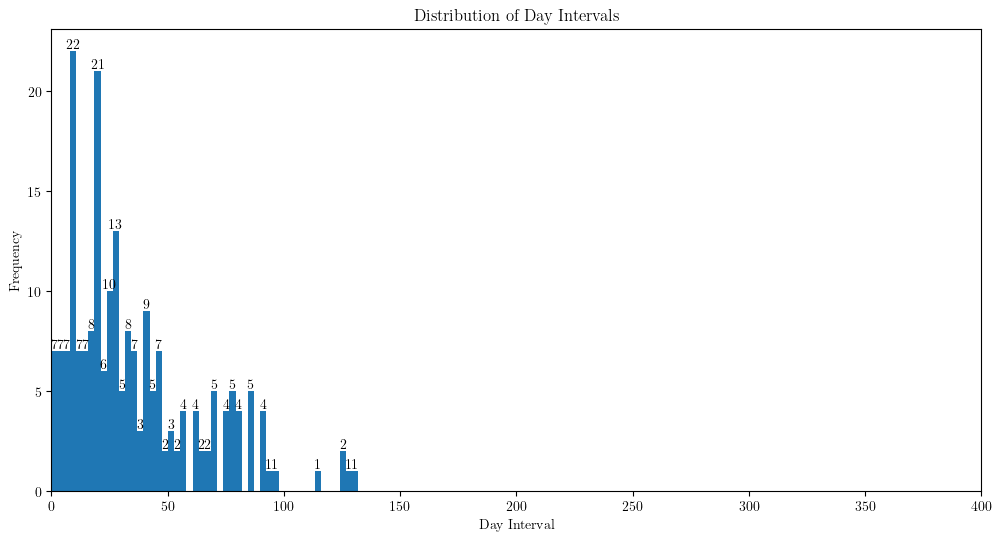

In [28]:
# Purpose: Plot a histogram of the 'day_interval' column in the spillover_table DataFrame.
#look at the distribution of spillover_table.day_interval in plot
plt.figure(figsize=(12, 6))
ax = spillover_table['ancestor_day_interval'].hist(bins=50)
plt.xlabel('Day Interval')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom')
plt.ylabel('Frequency')
#limit x-axis to 400
plt.xlim(0, 400)

plt.title('Distribution of Day Intervals')
plt.grid(False)
plt.show()

In [31]:
# Purpose: Load and process augur JSON data for non-cattle-related H5N1 outbreaks to identify state transitions and spillover events.
#THIS IS FOR OTHER H5N1
from datetime import datetime
heatmap_color="viridis"
div_df = pd.DataFrame(columns=['state1', 'state2', 'divergence'])
spillover_table = pd.DataFrame(columns=['spillover_type', 'decimal_date', 'state', 'all_host', 'day_interval', 'spillover_id', 'ancestor_day_interval', 'leaf_count'])
leaf_table= pd.DataFrame(columns=['location', 'host', 'date', 'name'])

with open("../intermediate_data/bvbrc_nextstrain_2026_01_08.auspice.json", "r") as f:
    augur_output = json.load(f)
    child_count = 0
    div_df, child_data = augur_recurse(list(augur_output.items())[2][1], div_df, init_count=0)
    print(f"child count is {child_count}")

print(len(div_df))
state_corrections = {'Baja California':'California', 'British_Columbia':"Washington","Durango":"Colorado","Brookings":"Oregon","Maricopa County, AZ":"Arizona","Sonora":"California","Torres":"Texas"}
spillover_table['state'] = spillover_table['state'].replace(state_corrections)
spillover_table = spillover_table[spillover_table['ancestor_day_interval'] <= 140]
leaf_table['location'] = leaf_table['location'].replace(state_corrections)
other_spillover_2026 = spillover_table.copy()
print(spillover_table.spillover_type.value_counts())
print(f"Number of Human hosts in leaf table: {len(leaf_table[leaf_table['host'].str.contains('Human', na=False)])}")
other_leaves_2026=leaf_table.copy()

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/2616898101.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  leaf_table = pd.concat([leaf_table, pd.DataFrame([{
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/2616898101.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  spillover_table = pd.concat([spillover_table, pd.DataFrame([{


child count is 12091
0
spillover_type
Avian-Wild,Chicken                      170
Avian-Wild,Turkey                        79
Chicken,Turkey                           58
Avian-Wild,Nonhuman-mammal               19
Chicken,Domestic-Duck                     9
Chicken,Human                             8
Avian-Wild,Domestic-Duck                  8
Chicken,Nonhuman-mammal                   6
Avian-Wild,Cattle                         5
Avian-Domestic-Other,Avian-Wild           4
Avian-Domestic-Other,Chicken              2
Nonhuman-mammal,Turkey                    2
Avian-Domestic-Other,Nonhuman-mammal      1
Human,Turkey                              1
Avian-Domestic-Other,Turkey               1
Cattle,Human                              1
Avian-Wild,Human                          1
Cattle,Chicken                            1
Name: count, dtype: int64
Number of Human hosts in leaf table: 16


In [33]:
#Finalize spilover and leaf table
other_spillover=other_spillover_2026.copy()
other_leaves=other_leaves_2026.copy()

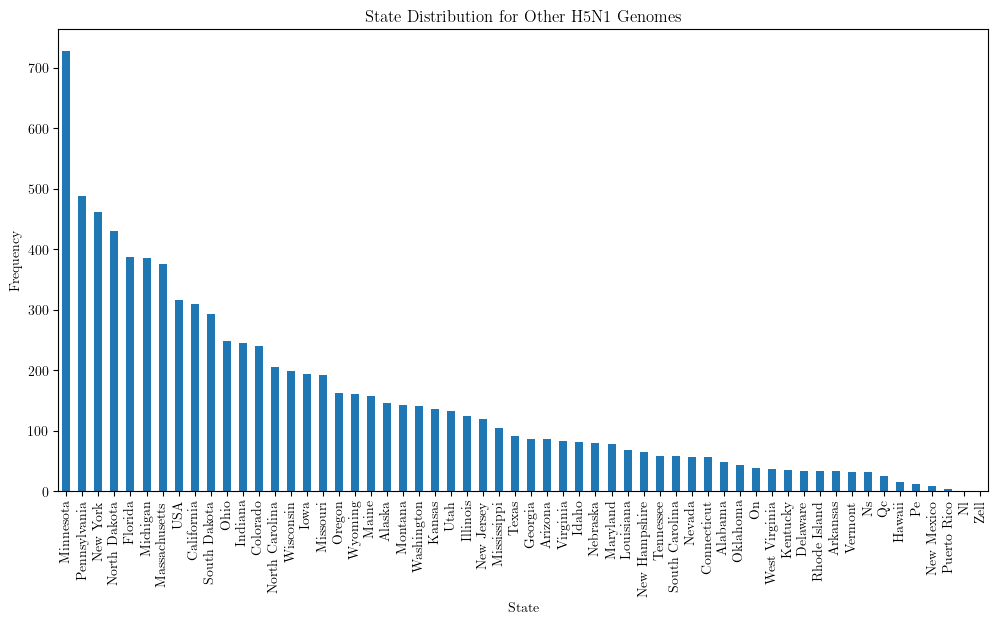

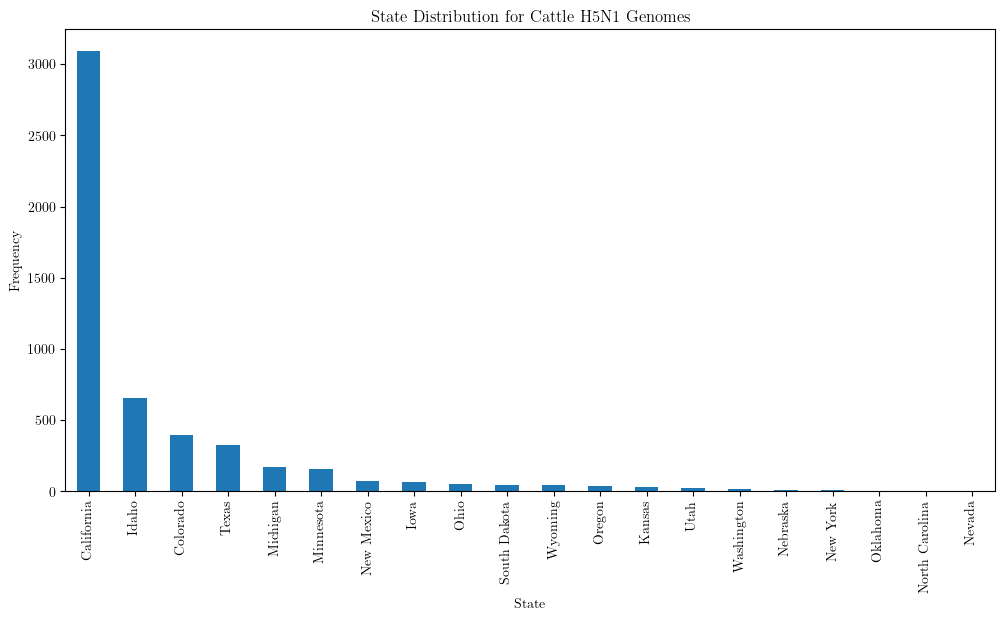

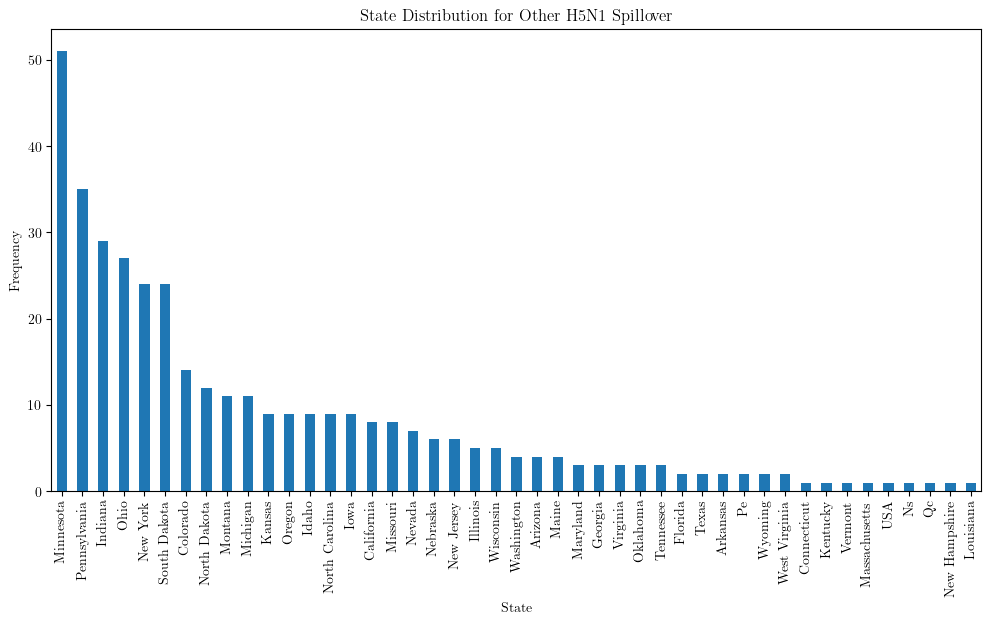

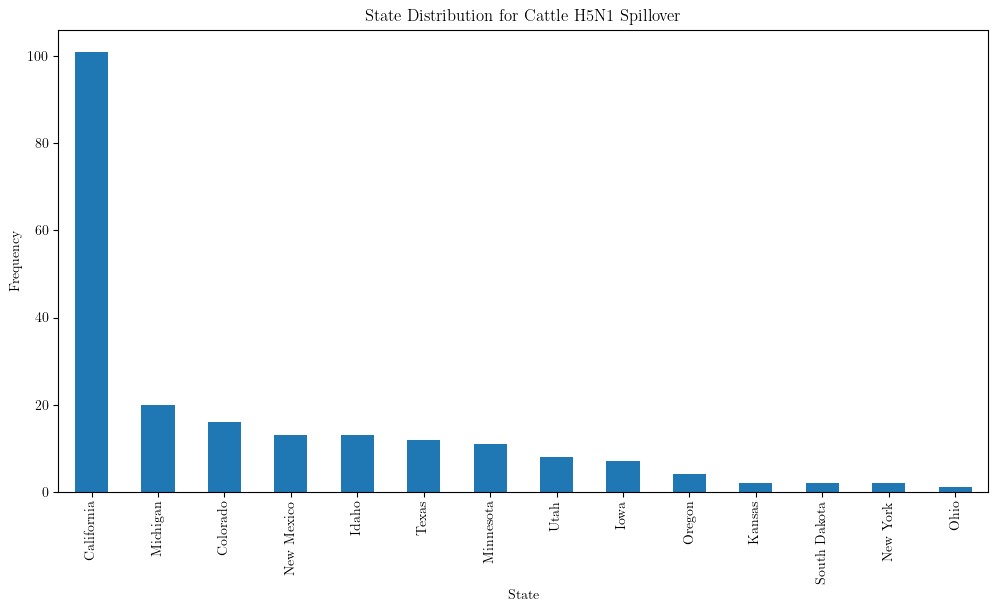

In [34]:
# Purpose: Plot bar charts showing the state distribution of genomes and spillover events for both cattle and other H5N1 types.
#plot state distribution barplot for other_leaves and cattle_leaves
plt.figure(figsize=(12, 6))
#plot state distribution barplot for other_leaves
other_leaves['location'].value_counts().plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('State Distribution for Other H5N1 Genomes')
plt.grid(False)
plt.show()
#plot state distribution barplot for cattle_leaves
plt.figure(figsize=(12, 6))
cattle_leaves['location'].value_counts().plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('State Distribution for Cattle H5N1 Genomes')
plt.grid(False)
plt.show()
#plot the state distribution in the spillover tables other_spillover and cattle_spillover
plt.figure(figsize=(12, 6))
#plot state distribution barplot for other_spillover
other_spillover['state'].value_counts().plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('State Distribution for Other H5N1 Spillover')
plt.grid(False)
plt.show()
#plot state distribution barplot for cattle_spillover
plt.figure(figsize=(12, 6))
cattle_spillover['state'].value_counts().plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('State Distribution for Cattle H5N1 Spillover')
plt.grid(False)
plt.show()

In [35]:
# Purpose: Combine cattle and other spillover data, handle spillover types with more than two hosts by splitting them into pairs, and display the value counts of the processed spillover types.
#for each spillover_type with more than three entries split them up and contribute the counts to all possible pairs for the same state,date
cattle_spillover["genotype"]="b3.13"
other_spillover["genotype"]="other"
spillover_table=pd.concat([cattle_spillover, other_spillover])
watch_list=[]

# Iterate over each row in spillover_table
for index, row in spillover_table.iterrows():
    spillover_type = row['spillover_type']
    spillover_types = spillover_type.split(",")
    if len(spillover_types) > 2:
        watch_list.append(spillover_type)
        for i in range(len(spillover_types)):
            for j in range(i + 1, len(spillover_types)):
                new_type = ",".join(sorted([spillover_types[i], spillover_types[j]]))
                spillover_table = pd.concat([spillover_table, pd.DataFrame({'spillover_type': [new_type], 'decimal_date': [row['decimal_date']], 'state': [row['state']]})], ignore_index=True)
#drop all rows with spillover_type in watch_list
spillover_table=spillover_table.drop(spillover_table[spillover_table.spillover_type.isin(watch_list)].index)
spillover_table.spillover_type.value_counts()

spillover_type
Avian-Wild,Chicken                      178
Avian-Wild,Turkey                        79
Chicken,Turkey                           77
Cattle,Chicken                           60
Cattle,Nonhuman-mammal                   33
Avian-Wild,Cattle                        28
Avian-Wild,Nonhuman-mammal               24
Cattle,Turkey                            23
Cattle,Human                             16
Chicken,Nonhuman-mammal                  15
Chicken,Human                            12
Chicken,Domestic-Duck                     9
Avian-Wild,Domestic-Duck                  8
Environment,Nonhuman-mammal               8
Nonhuman-mammal,Turkey                    5
Avian-Domestic-Other,Avian-Wild           4
Cattle,Environment                        3
Avian-Domestic-Other,Chicken              2
Human,Turkey                              1
Avian-Domestic-Other,Nonhuman-mammal      1
Avian-Domestic-Other,Turkey               1
Avian-Wild,Human                          1
Name: count, dtyp

In [37]:
# Purpose: Analyze the host category distribution for D1.1 genoflu type in Nextstrain and investigate the geographic locations of D1.1 and non-D1.1/non-B3.13 entries with missing state information.
print(nextstrain[nextstrain.genoflu == 'D1.1'].host_category.value_counts())
print(nextstrain[(nextstrain.genoflu == 'D1.1') & (nextstrain.division == "?")].head(n=5))
#get list from nextstrain[(nextstrain.genoflu == 'D1.1') & (nextstrain.division == "?")].isolate_id
other_id_list = nextstrain[(nextstrain.genoflu != 'D1.1') & (nextstrain.genoflu != 'B3.13')].isolate_id.values
no_state_list = nextstrain[(nextstrain.genoflu != 'D1.1') & (nextstrain.genoflu != 'B3.13') & (nextstrain.division == "?")].isolate_id.values
#look at the state for no_state_list from bv_brc
bv_brc[bv_brc['SRA Accession'].isin(no_state_list)]['Geographic Location'].value_counts()

host_category
Avian-Wild              3727
Chicken                  747
Turkey                   303
Nonhuman-mammal          110
Cattle                    46
Domestic-Duck             33
Avian-Domestic-Other      24
Human                      9
Unknown                    1
Name: count, dtype: int64
     data_source                                         strain      virus  \
4667     genbank  A/Americangreen-wingedteal/USA/IZ24_0776/2024  avian_flu   
4668     genbank  A/Americangreen-wingedteal/USA/IZ24_0777/2024  avian_flu   
4669     genbank                   A/mallard/USA/IZ24_0675/2024  avian_flu   
4671     genbank           A/northernpintail/USA/IZ24_0555/2024  avian_flu   
4672     genbank           A/northernpintail/USA/IZ24_0566/2024  avian_flu   

     isolate_id        date         region country division location  \
4667   PV602142  2024-10-17  North America     USA        ?        ?   
4668   PV602150  2024-10-17  North America     USA        ?        ?   
4669   PV60216

Geographic Location
USA        119
USA: WA      1
USA: VA      1
USA: OH      1
Name: count, dtype: int64

In [39]:
# Purpose: Convert decimal dates to year-month format, create datetime objects, group genome and spillover data by month and location/state, and display the heads of the resulting DataFrames.
#compute year-month from decimal year representation in date
def year_month(date):
    year = int(date)
    month = int((date - int(date))*12)
    if month == 0:
        month = 1
    return f"{year}-{month:02d}"
spillover_table['month'] = spillover_table['decimal_date'].apply(lambda x: year_month(x))
#make date a datetime object
spillover_table['date'] = pd.to_datetime(spillover_table['month'], format='%Y-%m')
cattle_leaves['genotype']="b3.13"
other_leaves['genotype']="other"
genomes_table = pd.concat([cattle_leaves, other_leaves])
genomes_table['month'] = genomes_table['date'].apply(lambda x: year_month(x))
genomes_month= genomes_table.groupby(['month', 'location', 'host']).size().reset_index(name='count')
print(spillover_table.head())
spillover_month = spillover_table.groupby(['month', 'state', 'spillover_type']).size().reset_index(name='count')
spillover_month2 = spillover_table.groupby(['month', 'state', 'spillover_type','genotype']).size().reset_index(name='count')

# 1. Group the raw genomes_table by month and location to get the total sampling depth
# This counts ALL genomes (Cattle B3.13 + Other) sequenced in that state-month
sampling_effort = genomes_table.groupby(['month', 'location']).size().reset_index(name='total_samples')
sampling_effort = sampling_effort.rename(columns={'location': 'state'})

print("Sampling Effort Head:")
print(sampling_effort.head())

               spillover_type  decimal_date       state all_host day_interval  \
0  Avian-Wild,Nonhuman-mammal      2024.326  New Mexico      NaN            4   
1      Cattle,Nonhuman-mammal      2024.269  New Mexico      NaN            4   
2      Cattle,Nonhuman-mammal      2024.259  New Mexico      NaN            4   
3              Cattle,Chicken      2024.231  New Mexico      NaN           10   
4              Cattle,Chicken      2024.217  New Mexico      NaN           11   

                                        spillover_id ancestor_day_interval  \
0  A/HouseMouse/NM/24-014780-002-original/2024,A/...                    13   
1  A/cat/NM/24-012046-001-original/2024,A/cat/NM/...                    13   
2  A/cat/NM/24-012046-003-original/2024,A/cat/NM/...                    17   
3  A/CATTLE/USA/24-015837-001/2024,A/cattle/NM/24...                    20   
4  A/cattle/NM/24-023930-012-original/2024,A/chic...                    32   

  leaf_count                                

In [40]:
# Purpose: Display the top 20 rows of the spillover data between January 2022 and January 2023, sorted by count.
#sort spillover_month by count
spillover_month[(spillover_month['month'] >= '2022-01') & (spillover_month['month'] < '2023-01')].sort_values(by='count', ascending=False).head(20)

,month,state,spillover_type,count
17,2022-01,Minnesota,"Avian-Wild,Turkey",13
37,2022-02,Minnesota,"Avian-Wild,Turkey",4
30,2022-01,South Dakota,"Avian-Wild,Turkey",4
34,2022-02,Idaho,"Avian-Wild,Chicken",3
39,2022-02,Montana,"Avian-Wild,Chicken",3
24,2022-01,North Dakota,"Avian-Wild,Chicken",3
45,2022-03,Minnesota,"Avian-Wild,Turkey",2
41,2022-02,North Carolina,"Chicken,Turkey",2
52,2022-11,Pennsylvania,"Avian-Wild,Chicken",2
48,2022-03,Pennsylvania,"Avian-Wild,Chicken",2


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>month</th>
      <th>state</th>
      <th>spillover_type</th>
      <th>count</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>7</th>
      <td>2022-01</td>
      <td>Minnesota</td>
      <td>Avian-Wild,Turkey</td>
      <td>27</td>
    </tr>
    <tr>
      <th>10</th>
      <td>2022-01</td>
      <td>North Carolina</td>
      <td>Chicken,Turkey</td>
      <td>22</td>
    </tr>
    <tr>
      <th>26</th>
      <td>2022-03</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Chicken</td>
      <td>10</td>
    </tr>
    <tr>
      <th>13</th>
      <td>2022-01</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Chicken</td>
      <td>9</td>
    </tr>
    <tr>
      <th>20</th>
      <td>2022-02</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Chicken</td>
      <td>6</td>
    </tr>
    <tr>
      <th>19</th>
      <td>2022-02</td>
      <td>North Carolina</td>
      <td>Chicken,Turkey</td>
      <td>5</td>
    </tr>
    <tr>
      <th>8</th>
      <td>2022-01</td>
      <td>Minnesota</td>
      <td>Chicken,Turkey</td>
      <td>4</td>
    </tr>
    <tr>
      <th>41</th>
      <td>2022-10</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Chicken</td>
      <td>3</td>
    </tr>
    <tr>
      <th>16</th>
      <td>2022-02</td>
      <td>Idaho</td>
      <td>Avian-Wild,Chicken</td>
      <td>3</td>
    </tr>
    <tr>
      <th>38</th>
      <td>2022-09</td>
      <td>California</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>35</th>
      <td>2022-08</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>32</th>
      <td>2022-07</td>
      <td>USA</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>31</th>
      <td>2022-06</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Turkey</td>
      <td>2</td>
    </tr>
    <tr>
      <th>24</th>
      <td>2022-03</td>
      <td>Minnesota</td>
      <td>Avian-Wild,Turkey</td>
      <td>2</td>
    </tr>
    <tr>
      <th>28</th>
      <td>2022-03</td>
      <td>USA</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>42</th>
      <td>2022-10</td>
      <td>Pennsylvania</td>
      <td>Avian-Wild,Turkey</td>
      <td>2</td>
    </tr>
    <tr>
      <th>5</th>
      <td>2022-01</td>
      <td>Michigan</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>2</th>
      <td>2022-01</td>
      <td>Idaho</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>6</th>
      <td>2022-01</td>
      <td>Minnesota</td>
      <td>Avian-Wild,Chicken</td>
      <td>2</td>
    </tr>
    <tr>
      <th>18</th>
      <td>2022-02</td>
      <td>North Carolina</td>
      <td>Avian-Wild,Turkey</td>
      <td>1</td>
    </tr>
  </tbody>
</table>
</div>

In [41]:
# Purpose: Define a function to compute the Pearson correlation coefficient and p-value between two series.
import pandas as pd
from scipy.stats import pearsonr

def compute_corr_and_p(counts, risk_scores):
    # Compute correlation coefficient and p-value
    r, p_value = pearsonr(counts, risk_scores)
    return pd.Series({'correlation': r, 'p_value': p_value})

     month state      spillover_type  count state_code     time       subtype  \
0  2022-01  Iowa  Avian-Wild,Chicken      1         19  2022-01  ckn-broilers   
1  2022-01  Iowa  Avian-Wild,Chicken      1         19  2022-01    ckn-layers   
2  2022-01  Iowa  Avian-Wild,Chicken      1         19  2022-01         ducks   
3  2022-01  Iowa  Avian-Wild,Chicken      1         19  2022-01         dairy   
4  2022-01  Iowa  Avian-Wild,Chicken      1         19  2022-01       turkeys   

          0         1         2         3         4         5       date  \
0  0.009410  0.019716  0.053761  0.004171  0.001562  0.000718 2022-01-01   
1  0.101744  0.214391  0.388323  0.043719  0.016619  0.007531 2022-01-01   
2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000 2022-01-01   
3  0.001502  0.002759  0.010782  0.001731  0.000797  0.000371 2022-01-01   
4  0.150186  0.382189  0.761032  0.127022  0.047102  0.020219 2022-01-01   

       risk  
0  0.019716  
1  0.214391  
2  0.000000  


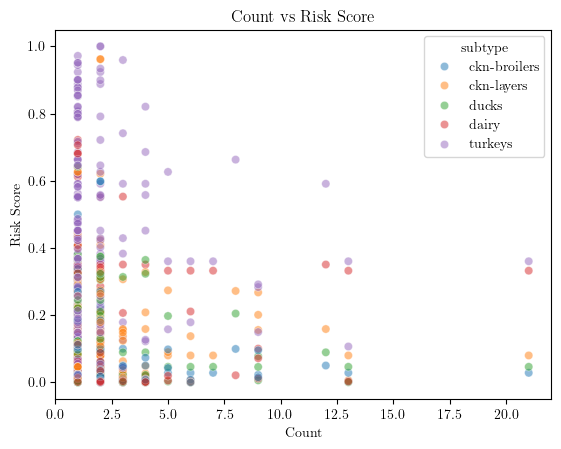

In [42]:
import seaborn as sns
# Purpose: Merge spillover and conditional risk data, filter for relevant spillover types, and plot a scatter plot of spillover count versus risk score by subtype.
spillover_analysis = spillover_month.merge(st_risk_scores, on=['month', 'state'], how='inner')
spillover_analysis = spillover_analysis.drop(spillover_analysis[spillover_analysis.spillover_type=="Human,Turkey"].index)
keep_list = spillover_analysis.spillover_type.unique()
keep_list = [i for i in keep_list if len(i.split(',')) <3 and "Nonhuman" not in i and "Other" not in i and "Environment" not in i]
print(spillover_analysis.head())
#compute corelation between count and risk score for each (spillover_type, subtype) pair
spillover_analysis['spillover_type'] = spillover_analysis['spillover_type'].astype(str)
spillover_analysis['subtype'] = spillover_analysis['subtype'].astype(str)
#group by spillover_type and subtype
# for spillover_corr = spillover_analysis.groupby(['spillover_type', 'subtype']).apply(lambda x: x['count'] plot the count vs risk score in a scatter plot
#plot using seaborn
scatter_df = spillover_analysis[['count', 'risk','subtype']].dropna()
sns.scatterplot(data=scatter_df, x='count', y='risk', alpha=0.5,hue=scatter_df['subtype'])
plt.xlabel('Count')
plt.ylabel('Risk Score')
plt.title('Count vs Risk Score')
plt.show()

/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


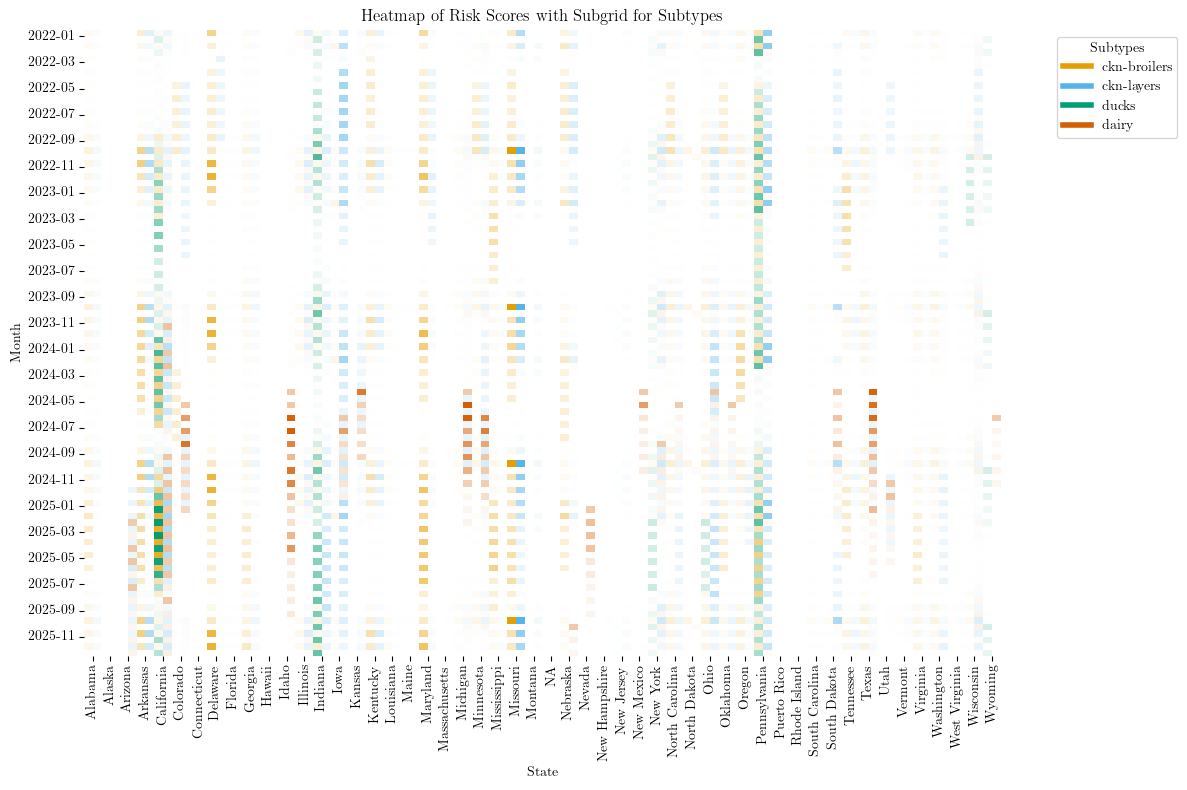

In [43]:
# Purpose: Generate a heatmap of conditional risk scores with a subgrid for the first 4 subtypes, using custom color-blind friendly colors.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get the first 4 unique subtypes
unique_subtypes = st_risk_scores['subtype'].unique()[:4]

# Pivot the data for each subtype
subtype_data = {
    subtype: st_risk_scores[st_risk_scores['subtype'] == subtype]
    .pivot(index='month', columns='state', values='risk')
    for subtype in unique_subtypes
}

# Create the main heatmap data by averaging the risk scores across subtypes
main_heatmap = st_risk_scores.pivot_table(index='month', columns='state', values='risk', aggfunc='mean')
#set all values in main_heatmap to NaN
main_heatmap[:] = np.nan

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
ax=sns.heatmap(main_heatmap, cmap="viridis", ax=ax)
#remove the cbar but keep the margin for it
cbar = ax.collections[0].colorbar
cbar.remove()
ax.set_title('Heatmap of Risk Scores with Subgrid for Subtypes')
ax.set_xlabel('State')
ax.set_ylabel('Month')

# Define colors for each subtype
#subtype_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
import matplotlib.colors as mcolors

# Define your red/green color blind friendly hex colors:
#custom_hex_colors = ["#0073E6", "#F5E900", "#5928ED", "#00B4C5"]
custom_hex_colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00"]
# Convert them to RGBA tuples (each element is a 4-tuple of floats)
subtype_colors = np.array([mcolors.to_rgba(color) for color in custom_hex_colors])

# Overlay subgrid heatmaps for the first 4 subtypes
for x, state in enumerate(main_heatmap.columns):
    for y, month in enumerate(main_heatmap.index):
        for i, subtype in enumerate(unique_subtypes):
            if state in subtype_data[subtype].columns and month in subtype_data[subtype].index:
                sub_value = subtype_data[subtype].loc[month, state]
                if not np.isnan(sub_value):
                    # Normalize the saturation relative to the max value for the subtype
                    max_value = subtype_data[subtype].max().max()
                    saturation = sub_value / max_value if max_value > 0 else 0
                    # Define subgrid position
                    sub_x = x + (i % 2) * 0.5
                    sub_y = y + (i // 2) * 0.5
                    # Determine color with adjusted saturation
                    color = subtype_colors[i]
                    color_with_saturation = [1 - (1 - c) * saturation for c in color[:3]] + [color[3]]
                    ax.add_patch(plt.Rectangle((sub_x, sub_y), 0.5, 0.5, color=color_with_saturation, ec=None))
# Create a legend for the subtype to color mapping
legend_elements = [
    plt.Line2D([0], [0], color=subtype_colors[i], lw=4, label=subtype)
    for i, subtype in enumerate(unique_subtypes)
]
ax.legend(handles=legend_elements, title="Subtypes", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


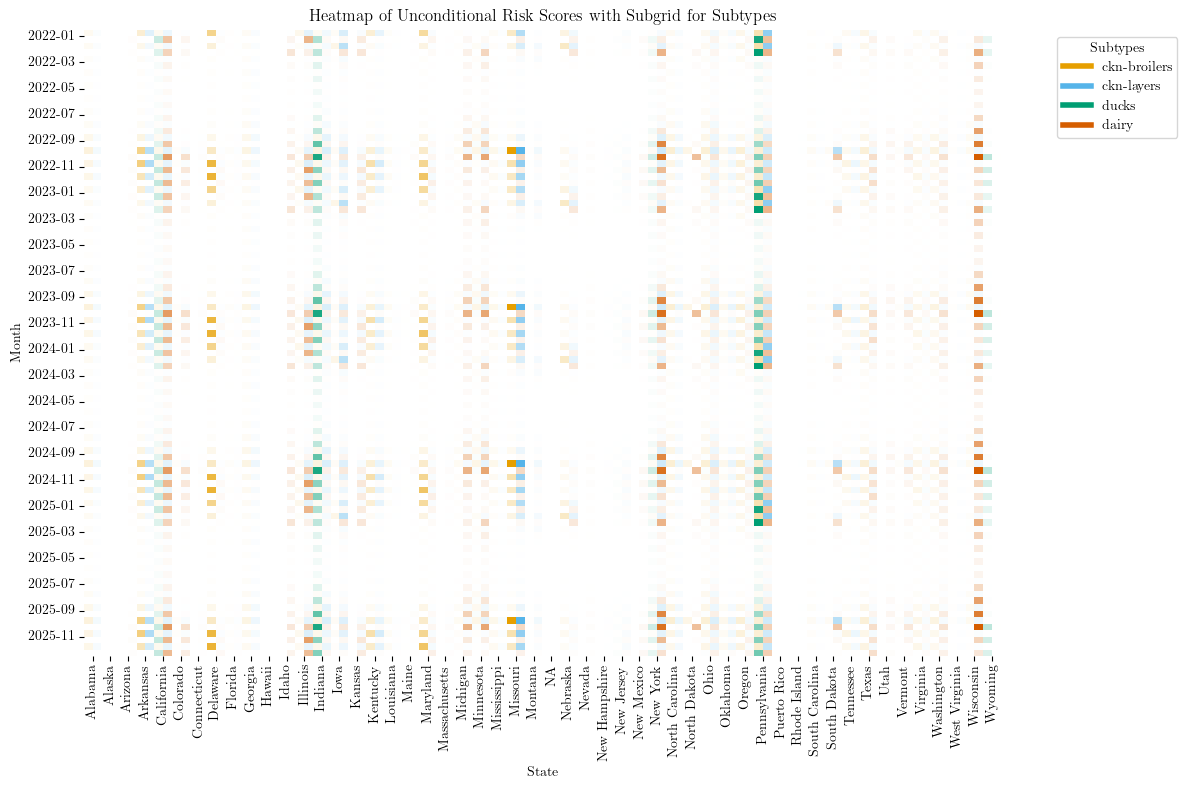

In [44]:
# Purpose: Generate a heatmap of unconditional risk scores with a subgrid for the first 4 subtypes, using custom color-blind friendly colors.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get the first 4 unique subtypes
unique_subtypes = unc_risk_scores['subtype'].unique()[:4]

# Pivot the data for each subtype
subtype_data = {
    subtype: unc_risk_scores[unc_risk_scores['subtype'] == subtype]
    .pivot(index='month', columns='state', values='risk')
    for subtype in unique_subtypes
}

# Create the main heatmap data by averaging the risk scores across subtypes
main_heatmap = unc_risk_scores.pivot_table(index='month', columns='state', values='risk', aggfunc='mean')
#set all values in main_heatmap to NaN
main_heatmap[:] = np.nan

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
ax=sns.heatmap(main_heatmap, cmap="viridis", ax=ax)
#remove the cbar but keep the margin for it
cbar = ax.collections[0].colorbar
cbar.remove()
ax.set_title('Heatmap of Unconditional Risk Scores with Subgrid for Subtypes')
ax.set_xlabel('State')
ax.set_ylabel('Month')

# Define colors for each subtype
#subtype_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
import matplotlib.colors as mcolors

# Define your red/green color blind friendly hex colors:
#custom_hex_colors = ["#0073E6", "#F5E900", "#5928ED", "#00B4C5"]
custom_hex_colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00"]
# Convert them to RGBA tuples (each element is a 4-tuple of floats)
subtype_colors = np.array([mcolors.to_rgba(color) for color in custom_hex_colors])

# Overlay subgrid heatmaps for the first 4 subtypes
for x, state in enumerate(main_heatmap.columns):
    for y, month in enumerate(main_heatmap.index):
        for i, subtype in enumerate(unique_subtypes):
            if state in subtype_data[subtype].columns and month in subtype_data[subtype].index:
                sub_value = subtype_data[subtype].loc[month, state]
                if not np.isnan(sub_value):
                    # Normalize the saturation relative to the max value for the subtype
                    max_value = subtype_data[subtype].max().max()
                    saturation = sub_value / max_value if max_value > 0 else 0
                    # Define subgrid position
                    sub_x = x + (i % 2) * 0.5
                    sub_y = y + (i // 2) * 0.5
                    # Determine color with adjusted saturation
                    color = subtype_colors[i]
                    color_with_saturation = [1 - (1 - c) * saturation for c in color[:3]] + [color[3]]
                    ax.add_patch(plt.Rectangle((sub_x, sub_y), 0.5, 0.5, color=color_with_saturation, ec=None))
# Create a legend for the subtype to color mapping
legend_elements = [
    plt.Line2D([0], [0], color=subtype_colors[i], lw=4, label=subtype)
    for i, subtype in enumerate(unique_subtypes)
]
ax.legend(handles=legend_elements, title="Subtypes", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


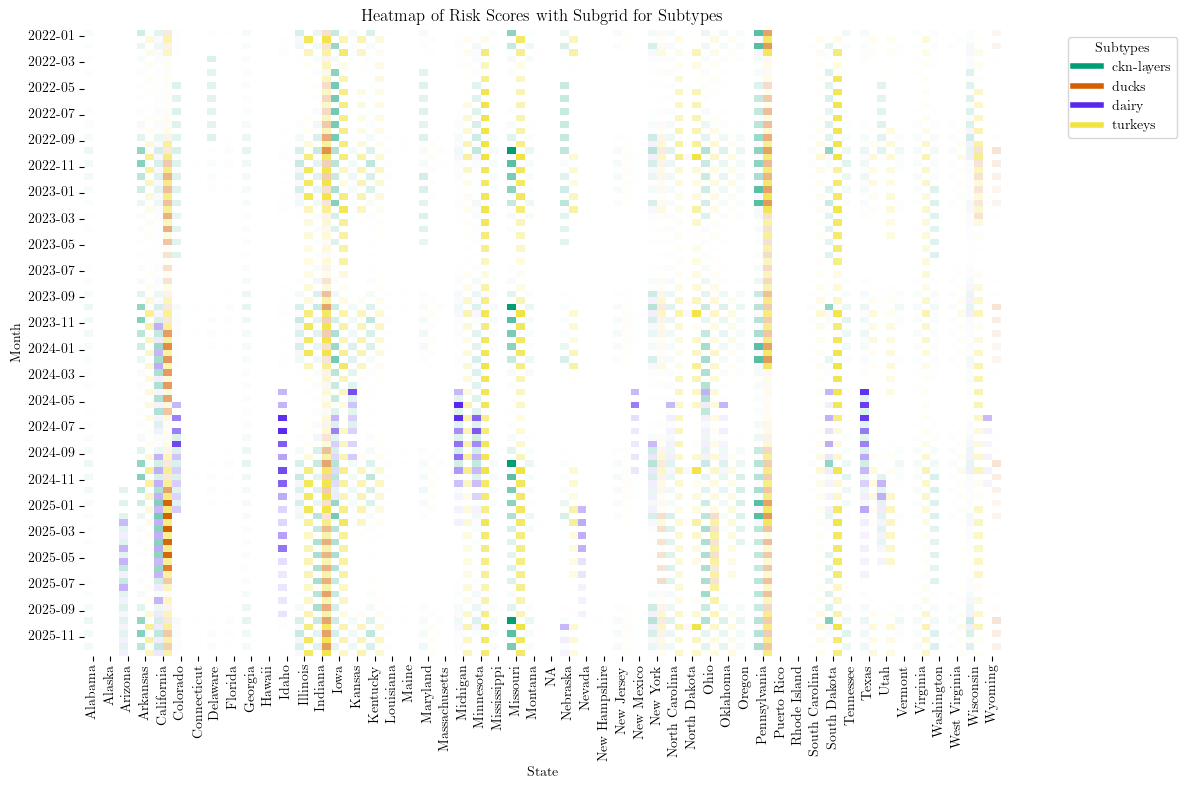

In [45]:
# Purpose: Generate a heatmap of conditional risk scores with a subgrid for the last 4 subtypes, using custom color-blind friendly colors.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get the first 4 unique subtypes
unique_subtypes = st_risk_scores['subtype'].unique()[-4:]

# Pivot the data for each subtype
subtype_data = {
    subtype: st_risk_scores[st_risk_scores['subtype'] == subtype]
    .pivot(index='month', columns='state', values='risk')
    for subtype in unique_subtypes
}

# Create the main heatmap data by averaging the risk scores across subtypes
main_heatmap = st_risk_scores.pivot_table(index='month', columns='state', values='risk', aggfunc='mean')
#set all values in main_heatmap to NaN
main_heatmap[:] = np.nan

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
ax=sns.heatmap(main_heatmap, cmap="viridis", ax=ax)
#remove the cbar but keep the margin for it
cbar = ax.collections[0].colorbar
cbar.remove()
ax.set_title('Heatmap of Risk Scores with Subgrid for Subtypes')
ax.set_xlabel('State')
ax.set_ylabel('Month')

# Define colors for each subtype
#subtype_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
import matplotlib.colors as mcolors

# Define your red/green color blind friendly hex colors:
#custom_hex_colors = ["#0073E6", "#F5E900", "#5928ED", "#00B4C5"]
custom_hex_colors = ["#009E73", "#D55E00", "#5928ED","#F0E442"]
# Convert them to RGBA tuples (each element is a 4-tuple of floats)
subtype_colors = np.array([mcolors.to_rgba(color) for color in custom_hex_colors])

# Overlay subgrid heatmaps for the first 4 subtypes
for x, state in enumerate(main_heatmap.columns):
    for y, month in enumerate(main_heatmap.index):
        for i, subtype in enumerate(unique_subtypes):
            if state in subtype_data[subtype].columns and month in subtype_data[subtype].index:
                sub_value = subtype_data[subtype].loc[month, state]
                if not np.isnan(sub_value):
                    # Normalize the saturation relative to the max value for the subtype
                    max_value = subtype_data[subtype].max().max()
                    saturation = sub_value / max_value if max_value > 0 else 0
                    # Define subgrid position
                    sub_x = x + (i % 2) * 0.5
                    sub_y = y + (i // 2) * 0.5
                    # Determine color with adjusted saturation
                    color = subtype_colors[i]
                    color_with_saturation = [1 - (1 - c) * saturation for c in color[:3]] + [color[3]]
                    ax.add_patch(plt.Rectangle((sub_x, sub_y), 0.5, 0.5, color=color_with_saturation, ec=None))
# Create a legend for the subtype to color mapping
legend_elements = [
    plt.Line2D([0], [0], color=subtype_colors[i], lw=4, label=subtype)
    for i, subtype in enumerate(unique_subtypes)
]
ax.legend(handles=legend_elements, title="Subtypes", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/anwarren/miniforge_ape/envs/escape/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


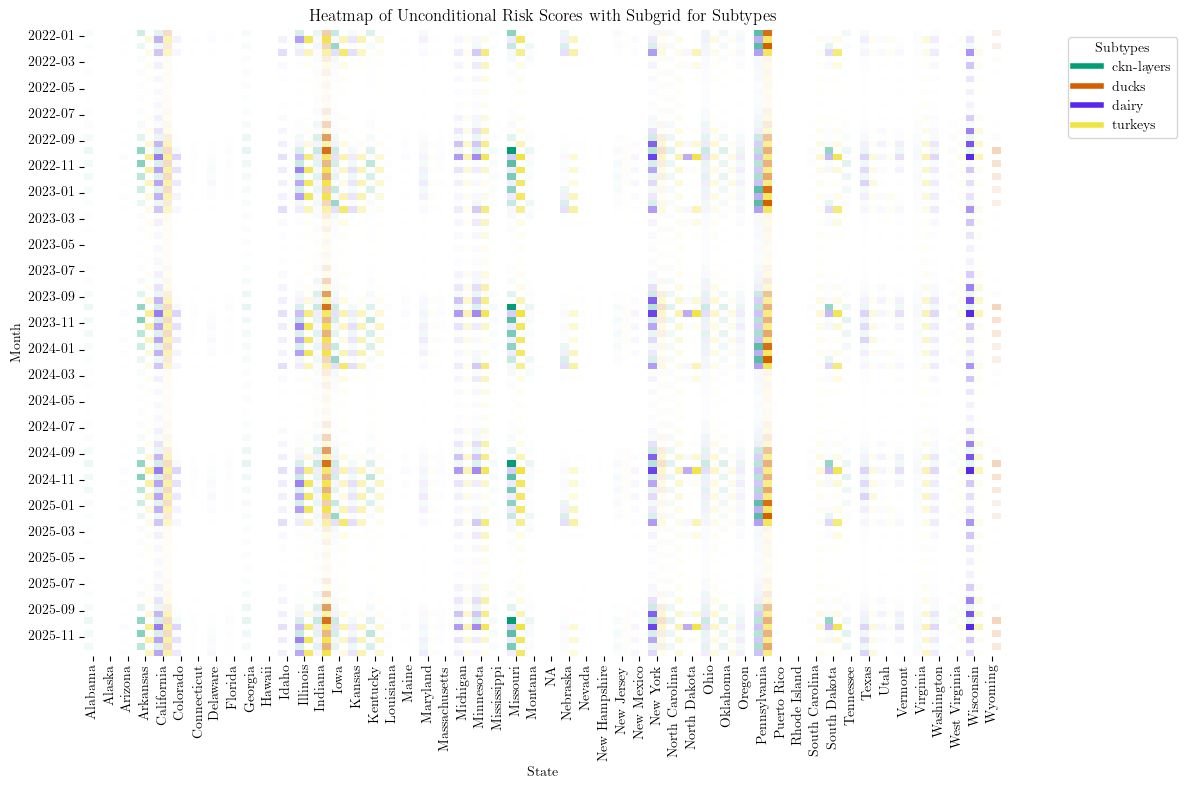

In [30]:
# Purpose: Generate a heatmap of unconditional risk scores with a subgrid for the last 4 subtypes, using custom color-blind friendly colors.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get the first 4 unique subtypes
unique_subtypes = unc_risk_scores['subtype'].unique()[-4:]

# Pivot the data for each subtype
subtype_data = {
    subtype: unc_risk_scores[unc_risk_scores['subtype'] == subtype]
    .pivot(index='month', columns='state', values='risk')
    for subtype in unique_subtypes
}

# Create the main heatmap data by averaging the risk scores across subtypes
main_heatmap = unc_risk_scores.pivot_table(index='month', columns='state', values='risk', aggfunc='mean')
#set all values in main_heatmap to NaN
main_heatmap[:] = np.nan

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
ax=sns.heatmap(main_heatmap, cmap="viridis", ax=ax)
#remove the cbar but keep the margin for it
cbar = ax.collections[0].colorbar
cbar.remove()
ax.set_title('Heatmap of Unconditional Risk Scores with Subgrid for Subtypes')
ax.set_xlabel('State')
ax.set_ylabel('Month')

# Define colors for each subtype
#subtype_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
import matplotlib.colors as mcolors

# Define your red/green color blind friendly hex colors:
#custom_hex_colors = ["#0073E6", "#F5E900", "#5928ED", "#00B4C5"]
custom_hex_colors = ["#009E73", "#D55E00", "#5928ED","#F0E442"]
# Convert them to RGBA tuples (each element is a 4-tuple of floats)
subtype_colors = np.array([mcolors.to_rgba(color) for color in custom_hex_colors])

# Overlay subgrid heatmaps for the first 4 subtypes
for x, state in enumerate(main_heatmap.columns):
    for y, month in enumerate(main_heatmap.index):
        for i, subtype in enumerate(unique_subtypes):
            if state in subtype_data[subtype].columns and month in subtype_data[subtype].index:
                sub_value = subtype_data[subtype].loc[month, state]
                if not np.isnan(sub_value):
                    # Normalize the saturation relative to the max value for the subtype
                    max_value = subtype_data[subtype].max().max()
                    saturation = sub_value / max_value if max_value > 0 else 0
                    # Define subgrid position
                    sub_x = x + (i % 2) * 0.5
                    sub_y = y + (i // 2) * 0.5
                    # Determine color with adjusted saturation
                    color = subtype_colors[i]
                    color_with_saturation = [1 - (1 - c) * saturation for c in color[:3]] + [color[3]]
                    ax.add_patch(plt.Rectangle((sub_x, sub_y), 0.5, 0.5, color=color_with_saturation, ec=None))
# Create a legend for the subtype to color mapping
legend_elements = [
    plt.Line2D([0], [0], color=subtype_colors[i], lw=4, label=subtype)
    for i, subtype in enumerate(unique_subtypes)
]
ax.legend(handles=legend_elements, title="Subtypes", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

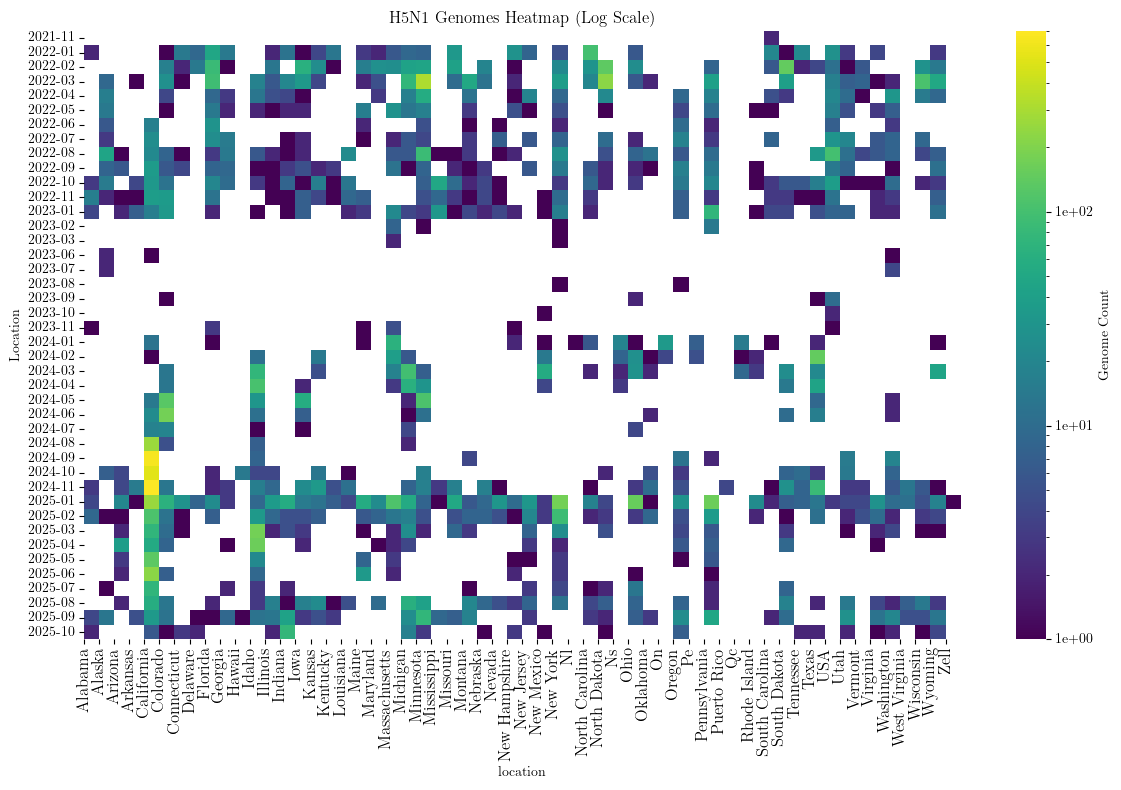

In [46]:
# Purpose: Generate a heatmap of H5N1 genome counts by month and state, with a log-scaled color bar.
# Generate a similar heatmap for the genomes_month with a log scale color bar
genome_heatmap_data = genomes_month.groupby(['month', 'location'])['count'].sum().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(genome_heatmap_data, cmap='viridis', annot=False, fmt='g', cbar_kws={'label': 'Genome Count', 'format': '%.0e'}, norm=plt.matplotlib.colors.LogNorm(vmin=genome_heatmap_data.min().min(), vmax=genome_heatmap_data.max().max()))
plt.title('H5N1 Genomes Heatmap (Log Scale)')
plt.ylabel('Location')
#plt.xticks(ticks=range(len(genome_heatmap_data.columns)), labels=genome_heatmap_data.columns, rotation=90, fontsize=6)
ax.set_xticks(range(len(genome_heatmap_data.columns)))
ax.set_xticklabels(genome_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
plt.tight_layout()
plt.show()

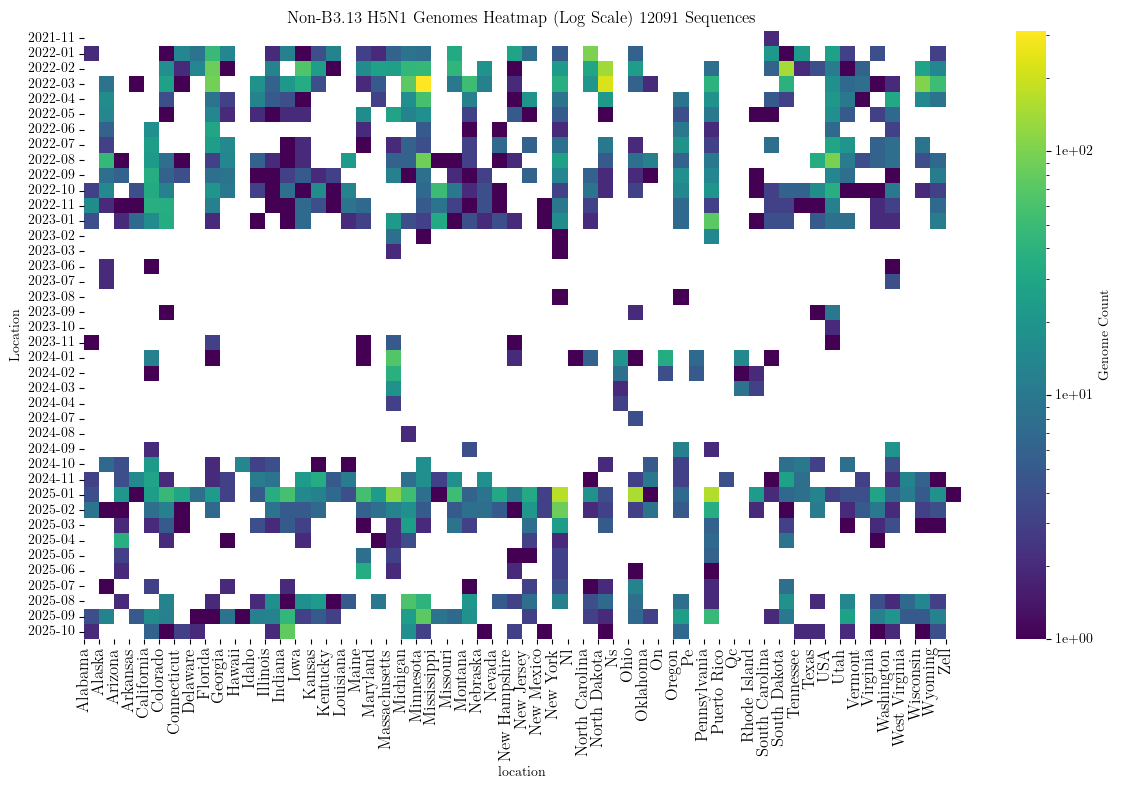

location  Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
month                                                                
2021-11         0       0        0         0           0         0   
2022-01         2       0        0         0           0         1   
2022-02         0       0        0         0           0        17   
2022-03         0       9        0         1           0        26   
2022-04         0      16        0         0           0         4   
2022-05         0      14        0         0           0         1   
2022-06         0       6        0         0          17         0   
2022-07         0       3        0         0          24         0   
2022-08         0      46        1         0          22         8   
2022-09         0       8        6         0          36         6   
2022-10         3      15        0         4          33        12   
2022-11        16       2        1         1          37        36   
2023-01         4   

In [48]:
# Purpose: Generate a heatmap of H5N1 genome counts by month and state, with a log-scaled color bar.
# Generate a similar heatmap for the genomes_month with a log scale color bar
genomes_month_nonb313= genomes_table[genomes_table.genotype!="b3.13"].groupby(['month', 'location', 'host']).size().reset_index(name='count')

bird_heatmap_data = genomes_month_nonb313.groupby(['month', 'location'])['count'].sum().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(bird_heatmap_data, cmap='viridis', annot=False, fmt='g', cbar_kws={'label': 'Genome Count', 'format': '%.0e'}, norm=plt.matplotlib.colors.LogNorm(vmin=bird_heatmap_data.min().min(), vmax=bird_heatmap_data.max().max()))
#make a title like plt.title('Non-B3.13 H5N1 Genomes Heatmap (Log Scale) 12,096 Sequences')
num_nonb313_sequences = len(genomes_table[genomes_table.genotype!="b3.13"])
plt.title(f'Non-B3.13 H5N1 Genomes Heatmap (Log Scale) {num_nonb313_sequences} Sequences')
plt.ylabel('Location')
#plt.xticks(ticks=range(len(genome_heatmap_data.columns)), labels=genome_heatmap_data.columns, rotation=90, fontsize=6)
ax.set_xticks(range(len(bird_heatmap_data.columns)))
ax.set_xticklabels(bird_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
plt.tight_layout()
plt.show()
#print plain text counts of genome_heatmap_data
print(bird_heatmap_data.fillna(0).astype(int))

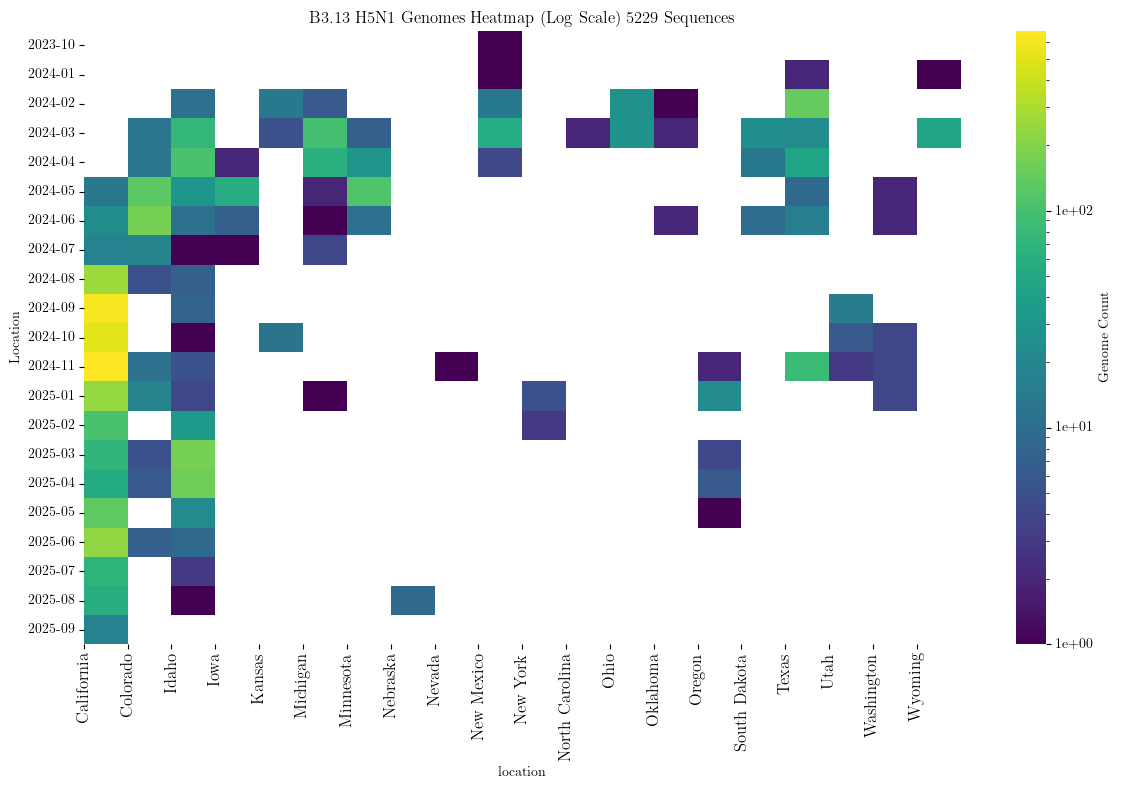

location  California  Colorado  Idaho  Iowa  Kansas  Michigan  Minnesota  \
month                                                                      
2023-10            0         0      0     0       0         0          0   
2024-01            0         0      0     0       0         0          0   
2024-02            0         0     11     0      14         6          0   
2024-03            0        13     74     0       5        96          7   
2024-04            0        13    103     2       0        64         30   
2024-05           14       129     31    58       0         2        111   
2024-06           23       173     11     7       0         1         11   
2024-07           18        19      1     1       0         4          0   
2024-08          260         5      7     0       0         0          0   
2024-09          633         0      8     0       0         0          0   
2024-10          502         0      1     0      12         0          0   
2024-11     

In [49]:
# Purpose: Generate a heatmap of H5N1 genome counts by month and state, with a log-scaled color bar.
# Generate a similar heatmap for the genomes_month with a log scale color bar
genomes_month_b313= genomes_table[genomes_table.genotype=="b3.13"].groupby(['month', 'location', 'host']).size().reset_index(name='count')

cow_heatmap_data = genomes_month_b313.groupby(['month', 'location'])['count'].sum().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(cow_heatmap_data, cmap='viridis', annot=False, fmt='g', cbar_kws={'label': 'Genome Count', 'format': '%.0e'}, norm=plt.matplotlib.colors.LogNorm(vmin=cow_heatmap_data.min().min(), vmax=cow_heatmap_data.max().max()))
#make a title like plt.title('B3.13 H5N1 Genomes Heatmap (Log Scale) 5,229 Sequences') but calculate the number of sequences
num_b313_sequences = len(genomes_table[genomes_table.genotype=="b3.13"])
plt.title(f'B3.13 H5N1 Genomes Heatmap (Log Scale) {num_b313_sequences} Sequences')
plt.ylabel('Location')
#plt.xticks(ticks=range(len(genome_heatmap_data.columns)), labels=genome_heatmap_data.columns, rotation=90, fontsize=6)
ax.set_xticks(range(len(cow_heatmap_data.columns)))
ax.set_xticklabels(cow_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
plt.tight_layout()
plt.show()
print(cow_heatmap_data.fillna(0).astype(int))

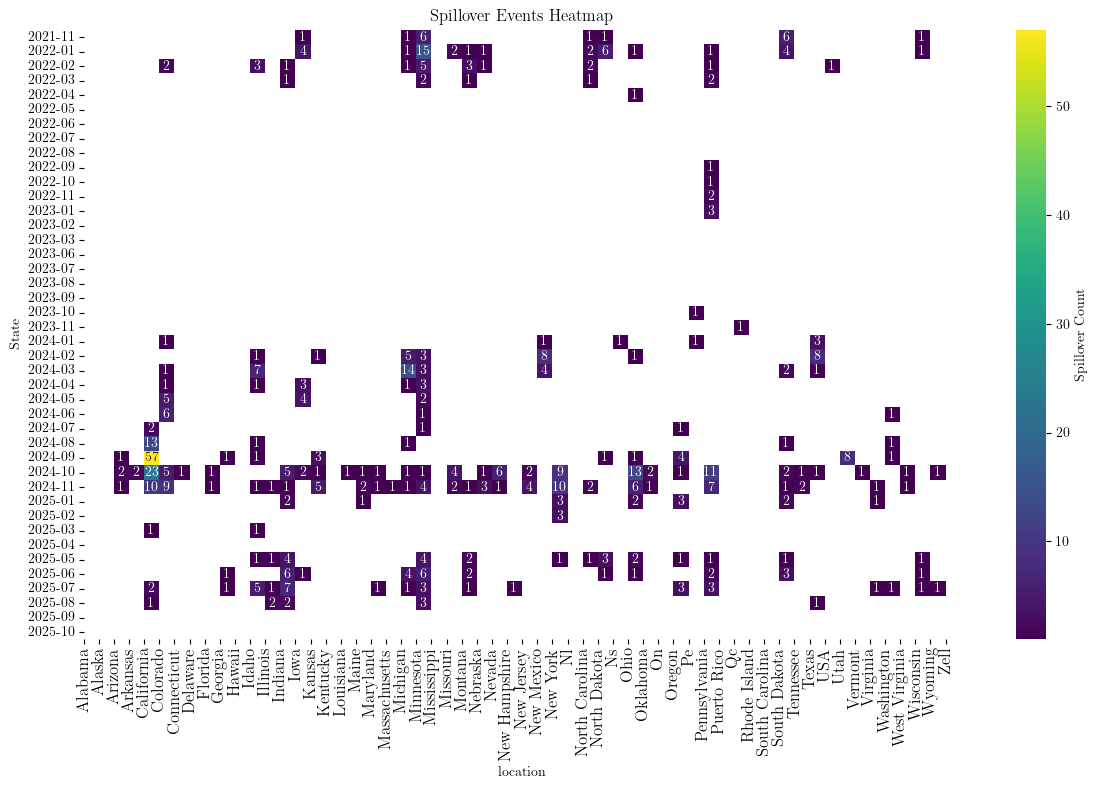

location  Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
month                                                                
2021-11         0       0        0         0           0         0   
2022-01         0       0        0         0           0         0   
2022-02         0       0        0         0           0         2   
2022-03         0       0        0         0           0         0   
2022-04         0       0        0         0           0         0   
2022-05         0       0        0         0           0         0   
2022-06         0       0        0         0           0         0   
2022-07         0       0        0         0           0         0   
2022-08         0       0        0         0           0         0   
2022-09         0       0        0         0           0         0   
2022-10         0       0        0         0           0         0   
2022-11         0       0        0         0           0         0   
2023-01         0   

In [51]:
# Purpose: Generate a heatmap of spillover event counts by month and state.
import seaborn as sns

import matplotlib.pyplot as plt

# Pivot the spillover_month dataframe to have states as rows and months as columns
heatmap_data = spillover_month2.groupby(['month', 'state'])['count'].sum().unstack()
#use the same columns and index genome_heatmap_data
heatmap_data = heatmap_data.reindex(columns=genome_heatmap_data.columns, index=genome_heatmap_data.index)

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='g', cbar_kws={'label': 'Spillover Count'})
plt.title('Spillover Events Heatmap')
#plt.xlabel('Month')
plt.ylabel('State')
#plt.xticks(rotation=90)
ax.set_xticks(range(len(genome_heatmap_data.columns)))
ax.set_xticklabels(genome_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
# Ensure all columns and rows, even if all are NaNs, are displayed
plt.matplotlib.rcParams['axes.formatter.useoffset'] = False
plt.tight_layout()
plt.show()

#print plain text counts of heatmap_data
print(heatmap_data.fillna(0).astype(int))

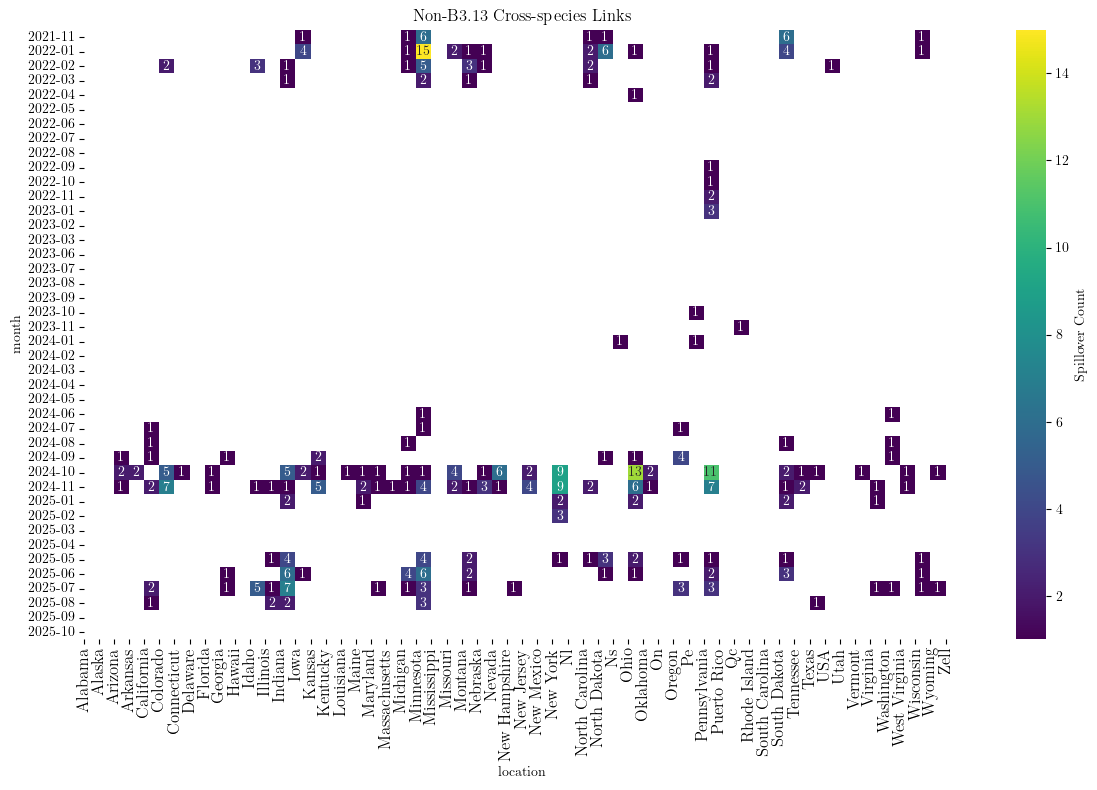

location  Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
month                                                                
2021-11         0       0        0         0           0         0   
2022-01         0       0        0         0           0         0   
2022-02         0       0        0         0           0         2   
2022-03         0       0        0         0           0         0   
2022-04         0       0        0         0           0         0   
2022-05         0       0        0         0           0         0   
2022-06         0       0        0         0           0         0   
2022-07         0       0        0         0           0         0   
2022-08         0       0        0         0           0         0   
2022-09         0       0        0         0           0         0   
2022-10         0       0        0         0           0         0   
2022-11         0       0        0         0           0         0   
2023-01         0   

In [53]:
# Purpose: Generate a heatmap of spillover event counts by month and state.
import seaborn as sns

import matplotlib.pyplot as plt

# Pivot the spillover_month dataframe to have states as rows and months as columns
heatmap_data = spillover_month2[spillover_month2.genotype == "other"].groupby(['month', 'state'])['count'].sum().unstack()
#use the same columns and index genome_heatmap_data
heatmap_data = heatmap_data.reindex(columns=genome_heatmap_data.columns, index=genome_heatmap_data.index)

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='g', cbar_kws={'label': 'Spillover Count'})
plt.title('Non-B3.13 Cross-species Links')
#plt.xlabel('Month')
#plt.ylabel('State')
#plt.xticks(rotation=90)
ax.set_xticks(range(len(genome_heatmap_data.columns)))
ax.set_xticklabels(genome_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
# Ensure all columns and rows, even if all are NaNs, are displayed
plt.matplotlib.rcParams['axes.formatter.useoffset'] = False
plt.tight_layout()
plt.show()
print(heatmap_data.fillna(0).astype(int))

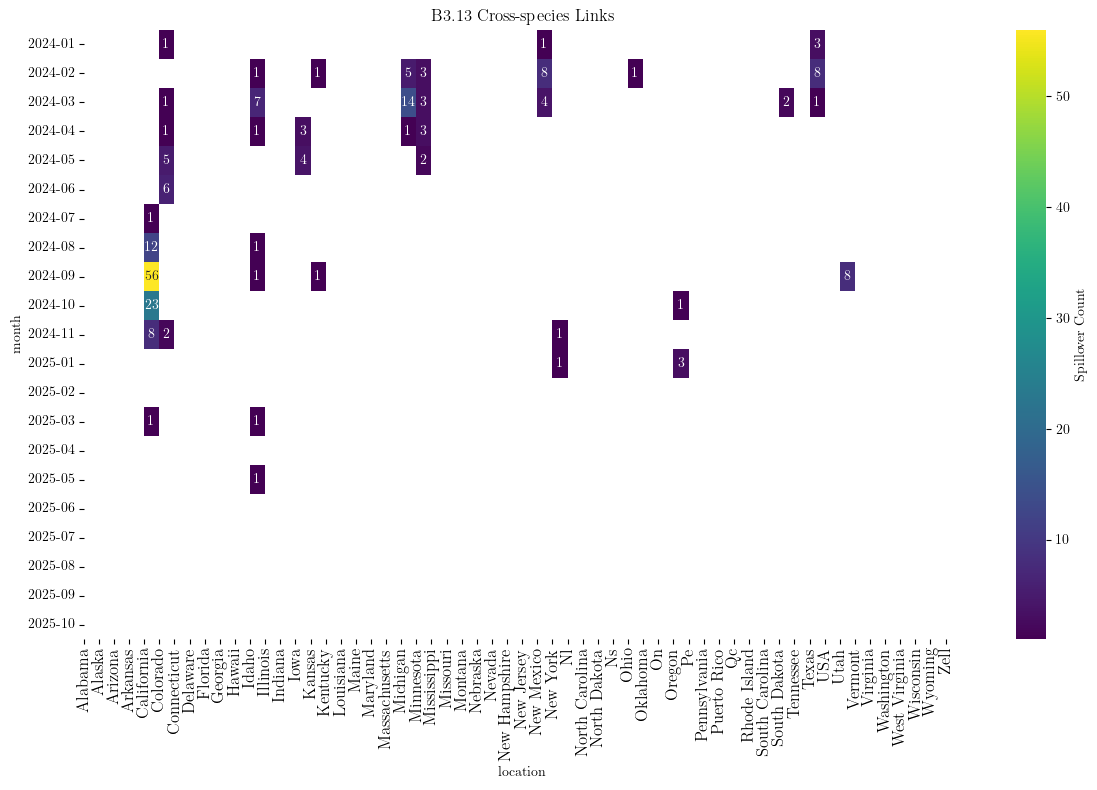

location  Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
month                                                                
2024-01         0       0        0         0           0         1   
2024-02         0       0        0         0           0         0   
2024-03         0       0        0         0           0         1   
2024-04         0       0        0         0           0         1   
2024-05         0       0        0         0           0         5   
2024-06         0       0        0         0           0         6   
2024-07         0       0        0         0           1         0   
2024-08         0       0        0         0          12         0   
2024-09         0       0        0         0          56         0   
2024-10         0       0        0         0          23         0   
2024-11         0       0        0         0           8         2   
2025-01         0       0        0         0           0         0   
2025-02         0   

In [54]:
# Purpose: Generate a heatmap of spillover event counts by month and state.
import seaborn as sns

import matplotlib.pyplot as plt

# Pivot the spillover_month dataframe to have states as rows and months as columns
heatmap_data = spillover_month2[spillover_month2.genotype == "b3.13"].groupby(['month', 'state'])['count'].sum().unstack()
#use the same columns and index genome_heatmap_data
heatmap_data = heatmap_data.reindex(columns=genome_heatmap_data.columns, index=genome_heatmap_data.index)

#remove rows before 2024
heatmap_data = heatmap_data.loc[heatmap_data.index >= '2024-01']

# Plot the heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='g', cbar_kws={'label': 'Spillover Count'})
plt.title('B3.13 Cross-species Links')
#plt.xlabel('Month')
#plt.ylabel('State')
#plt.xticks(rotation=90)
#turn off y-axis variable name
ax.set_xticks(range(len(genome_heatmap_data.columns)))
ax.set_xticklabels(genome_heatmap_data.columns, rotation=90, fontsize=12, ha='center', position=(0.1, 0))
# Ensure all columns and rows, even if all are NaNs, are displayed
plt.matplotlib.rcParams['axes.formatter.useoffset'] = False
plt.tight_layout()
plt.show()
print(heatmap_data.fillna(0).astype(int))

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


All Genotypes: Cross-species Link Heatmap by Host Type Pair Matrix Values:
Value at (Avian-Domestic-Other, Avian-Domestic-Other): 8
Value at (Avian-Domestic-Other, Avian-Wild): 4
Value at (Avian-Domestic-Other, Cattle): 0
Value at (Avian-Domestic-Other, Chicken): 2
Value at (Avian-Domestic-Other, Domestic-Duck): 0
Value at (Avian-Domestic-Other, Environment): 0
Value at (Avian-Domestic-Other, Human): 0
Value at (Avian-Domestic-Other, Nonhuman-mammal): 1
Value at (Avian-Domestic-Other, Turkey): 1
Value at (Avian-Wild, Avian-Domestic-Other): 4
Value at (Avian-Wild, Avian-Wild): 322
Value at (Avian-Wild, Cattle): 28
Value at (Avian-Wild, Chicken): 178
Value at (Avian-Wild, Domestic-Duck): 8
Value at (Avian-Wild, Environment): 0
Value at (Avian-Wild, Human): 1
Value at (Avian-Wild, Nonhuman-mammal): 24
Value at (Avian-Wild, Turkey): 79
Value at (Cattle, Avian-Domestic-Other): 0
Value at (Cattle, Avian-Wild): 28
Value at (Cattle, Cattle): 163
Value at (Cattle, Chicken): 60
Value at (Cattle,

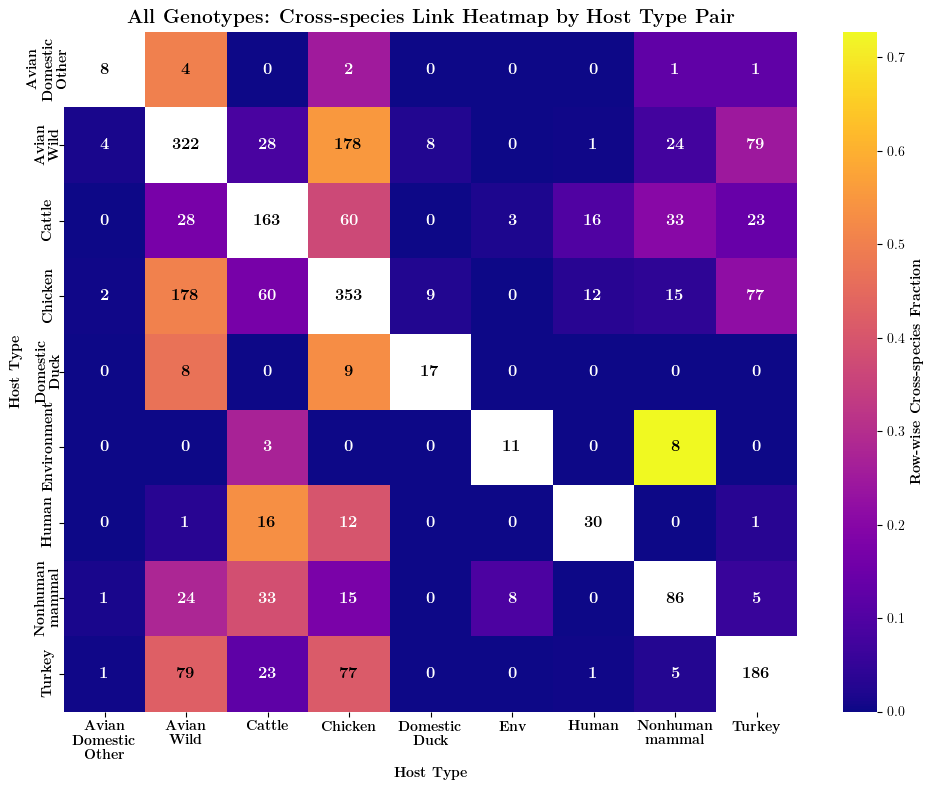

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


Non-B3.13 Genotypes: Cross-species Link Heatmap by Host Type Pair Matrix Values:
Value at (Avian-Domestic-Other, Avian-Domestic-Other): 8
Value at (Avian-Domestic-Other, Avian-Wild): 4
Value at (Avian-Domestic-Other, Cattle): 0
Value at (Avian-Domestic-Other, Chicken): 2
Value at (Avian-Domestic-Other, Domestic-Duck): 0
Value at (Avian-Domestic-Other, Human): 0
Value at (Avian-Domestic-Other, Nonhuman-mammal): 1
Value at (Avian-Domestic-Other, Turkey): 1
Value at (Avian-Wild, Avian-Domestic-Other): 4
Value at (Avian-Wild, Avian-Wild): 286
Value at (Avian-Wild, Cattle): 5
Value at (Avian-Wild, Chicken): 170
Value at (Avian-Wild, Domestic-Duck): 8
Value at (Avian-Wild, Human): 1
Value at (Avian-Wild, Nonhuman-mammal): 19
Value at (Avian-Wild, Turkey): 79
Value at (Cattle, Avian-Domestic-Other): 0
Value at (Cattle, Avian-Wild): 5
Value at (Cattle, Cattle): 7
Value at (Cattle, Chicken): 1
Value at (Cattle, Domestic-Duck): 0
Value at (Cattle, Human): 1
Value at (Cattle, Nonhuman-mammal): 0


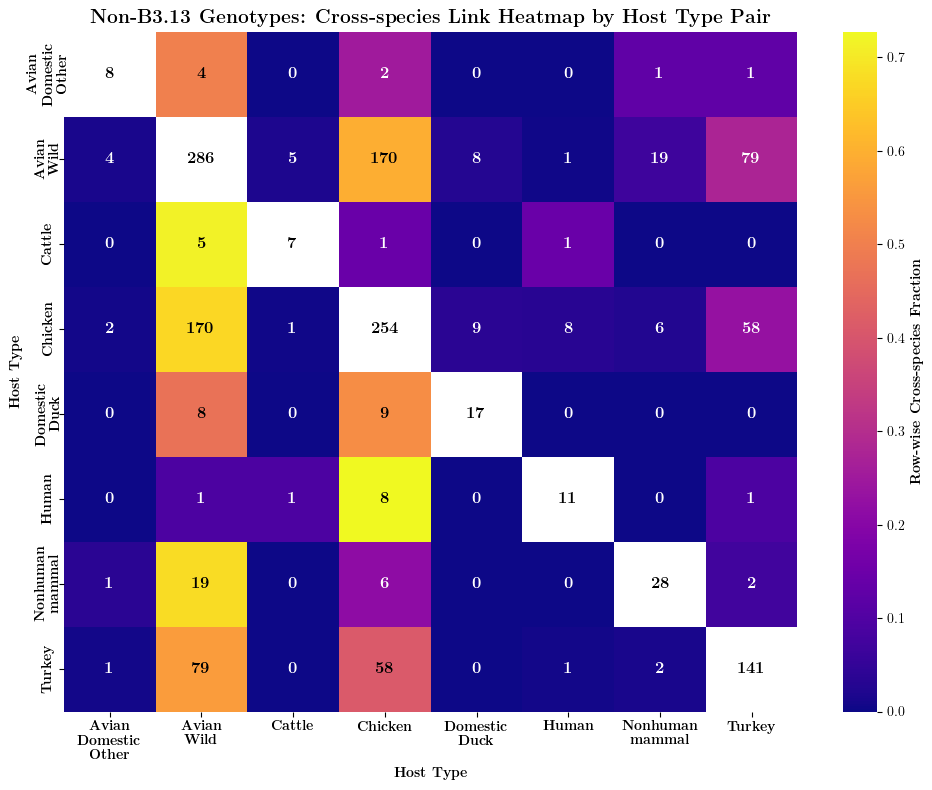

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


B3.13 Genotypes: Cross-species Link Heatmap by Host Type Pair Matrix Values:
Value at (Avian-Wild, Avian-Wild): 36
Value at (Avian-Wild, Cattle): 23
Value at (Avian-Wild, Chicken): 8
Value at (Avian-Wild, Environment): 0
Value at (Avian-Wild, Human): 0
Value at (Avian-Wild, Nonhuman-mammal): 5
Value at (Avian-Wild, Turkey): 0
Value at (Cattle, Avian-Wild): 23
Value at (Cattle, Cattle): 156
Value at (Cattle, Chicken): 59
Value at (Cattle, Environment): 3
Value at (Cattle, Human): 15
Value at (Cattle, Nonhuman-mammal): 33
Value at (Cattle, Turkey): 23
Value at (Chicken, Avian-Wild): 8
Value at (Chicken, Cattle): 59
Value at (Chicken, Chicken): 99
Value at (Chicken, Environment): 0
Value at (Chicken, Human): 4
Value at (Chicken, Nonhuman-mammal): 9
Value at (Chicken, Turkey): 19
Value at (Environment, Avian-Wild): 0
Value at (Environment, Cattle): 3
Value at (Environment, Chicken): 0
Value at (Environment, Environment): 11
Value at (Environment, Human): 0
Value at (Environment, Nonhuman-m

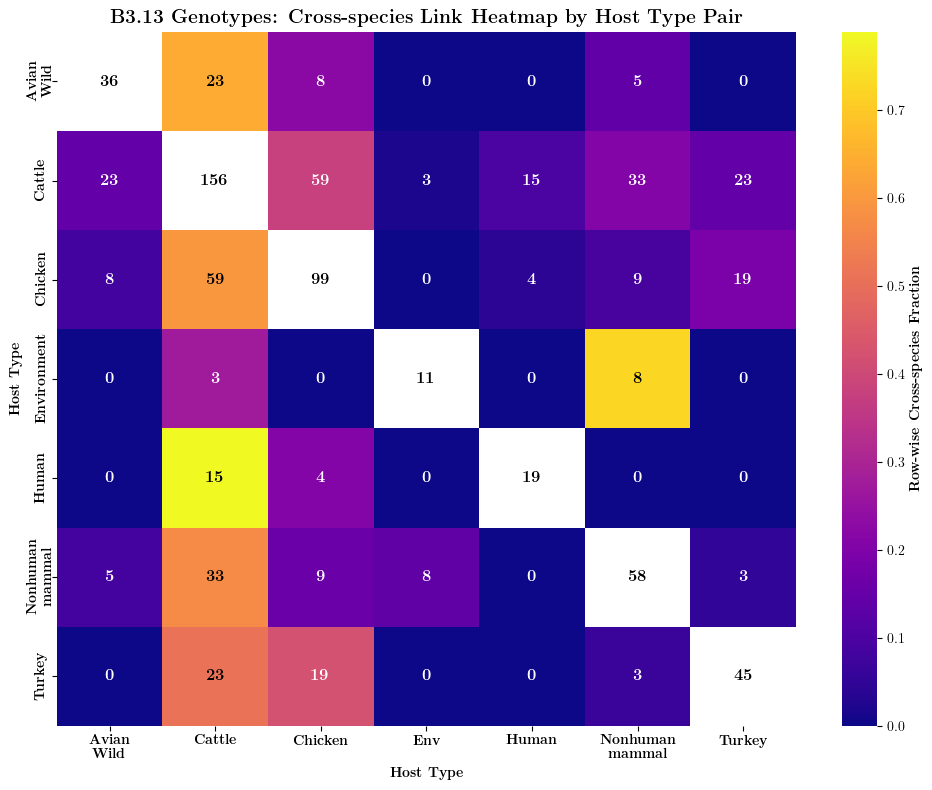

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


Cross-species Link Heatmap (2022-01 to 2025-05) Matrix Values:
Value at (Avian-Domestic-Other, Avian-Domestic-Other): 2
Value at (Avian-Domestic-Other, Avian-Wild): 1
Value at (Avian-Domestic-Other, Cattle): 0
Value at (Avian-Domestic-Other, Chicken): 0
Value at (Avian-Domestic-Other, Environment): 0
Value at (Avian-Domestic-Other, Human): 0
Value at (Avian-Domestic-Other, Nonhuman-mammal): 1
Value at (Avian-Domestic-Other, Turkey): 0
Value at (Avian-Wild, Avian-Domestic-Other): 1
Value at (Avian-Wild, Avian-Wild): 227
Value at (Avian-Wild, Cattle): 28
Value at (Avian-Wild, Chicken): 135
Value at (Avian-Wild, Environment): 0
Value at (Avian-Wild, Human): 1
Value at (Avian-Wild, Nonhuman-mammal): 23
Value at (Avian-Wild, Turkey): 39
Value at (Cattle, Avian-Domestic-Other): 0
Value at (Cattle, Avian-Wild): 28
Value at (Cattle, Cattle): 163
Value at (Cattle, Chicken): 60
Value at (Cattle, Environment): 3
Value at (Cattle, Human): 16
Value at (Cattle, Nonhuman-mammal): 33
Value at (Cattle,

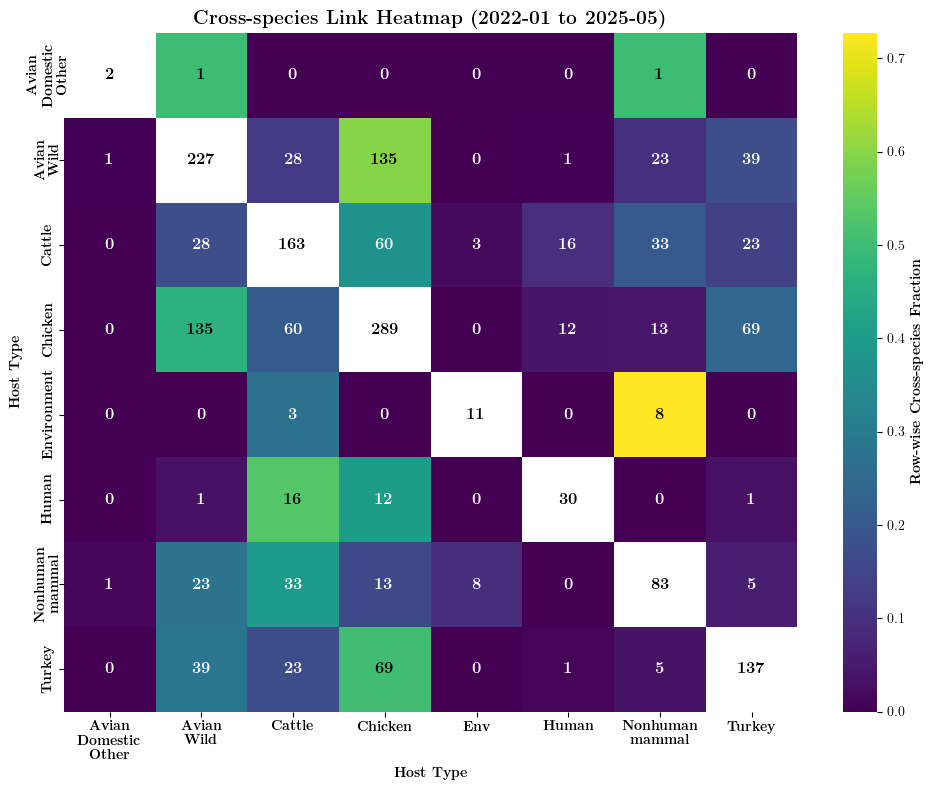

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


Cross-species Link Heatmap (2024-01 to 2025-05) Matrix Values:
Value at (Avian-Domestic-Other, Avian-Domestic-Other): 2
Value at (Avian-Domestic-Other, Avian-Wild): 1
Value at (Avian-Domestic-Other, Cattle): 0
Value at (Avian-Domestic-Other, Chicken): 0
Value at (Avian-Domestic-Other, Environment): 0
Value at (Avian-Domestic-Other, Human): 0
Value at (Avian-Domestic-Other, Nonhuman-mammal): 1
Value at (Avian-Domestic-Other, Turkey): 0
Value at (Avian-Wild, Avian-Domestic-Other): 1
Value at (Avian-Wild, Avian-Wild): 163
Value at (Avian-Wild, Cattle): 27
Value at (Avian-Wild, Chicken): 102
Value at (Avian-Wild, Environment): 0
Value at (Avian-Wild, Human): 1
Value at (Avian-Wild, Nonhuman-mammal): 22
Value at (Avian-Wild, Turkey): 10
Value at (Cattle, Avian-Domestic-Other): 0
Value at (Cattle, Avian-Wild): 27
Value at (Cattle, Cattle): 162
Value at (Cattle, Chicken): 60
Value at (Cattle, Environment): 3
Value at (Cattle, Human): 16
Value at (Cattle, Nonhuman-mammal): 33
Value at (Cattle,

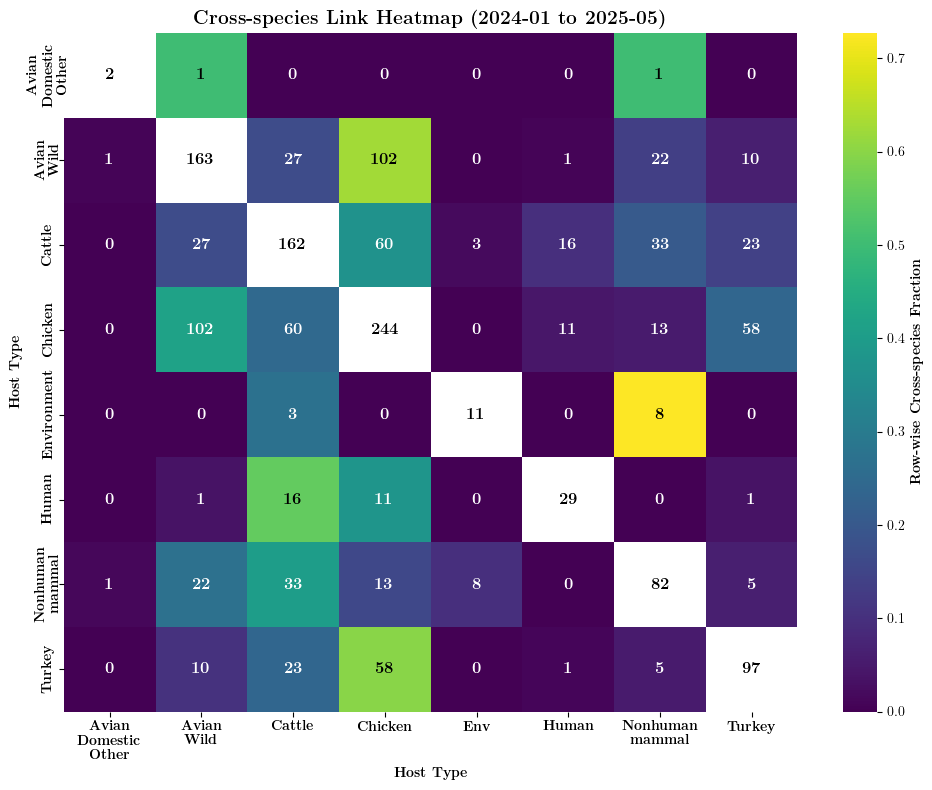

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/3143038359.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])


Cross-species Link Heatmap (2022-01 to 2023-12) Matrix Values:
Value at (Avian-Wild, Avian-Wild): 64
Value at (Avian-Wild, Cattle): 1
Value at (Avian-Wild, Chicken): 33
Value at (Avian-Wild, Human): 0
Value at (Avian-Wild, Nonhuman-mammal): 1
Value at (Avian-Wild, Turkey): 29
Value at (Cattle, Avian-Wild): 1
Value at (Cattle, Cattle): 1
Value at (Cattle, Chicken): 0
Value at (Cattle, Human): 0
Value at (Cattle, Nonhuman-mammal): 0
Value at (Cattle, Turkey): 0
Value at (Chicken, Avian-Wild): 33
Value at (Chicken, Cattle): 0
Value at (Chicken, Chicken): 45
Value at (Chicken, Human): 1
Value at (Chicken, Nonhuman-mammal): 0
Value at (Chicken, Turkey): 11
Value at (Human, Avian-Wild): 0
Value at (Human, Cattle): 0
Value at (Human, Chicken): 1
Value at (Human, Human): 1
Value at (Human, Nonhuman-mammal): 0
Value at (Human, Turkey): 0
Value at (Nonhuman-mammal, Avian-Wild): 1
Value at (Nonhuman-mammal, Cattle): 0
Value at (Nonhuman-mammal, Chicken): 0
Value at (Nonhuman-mammal, Human): 0
Val

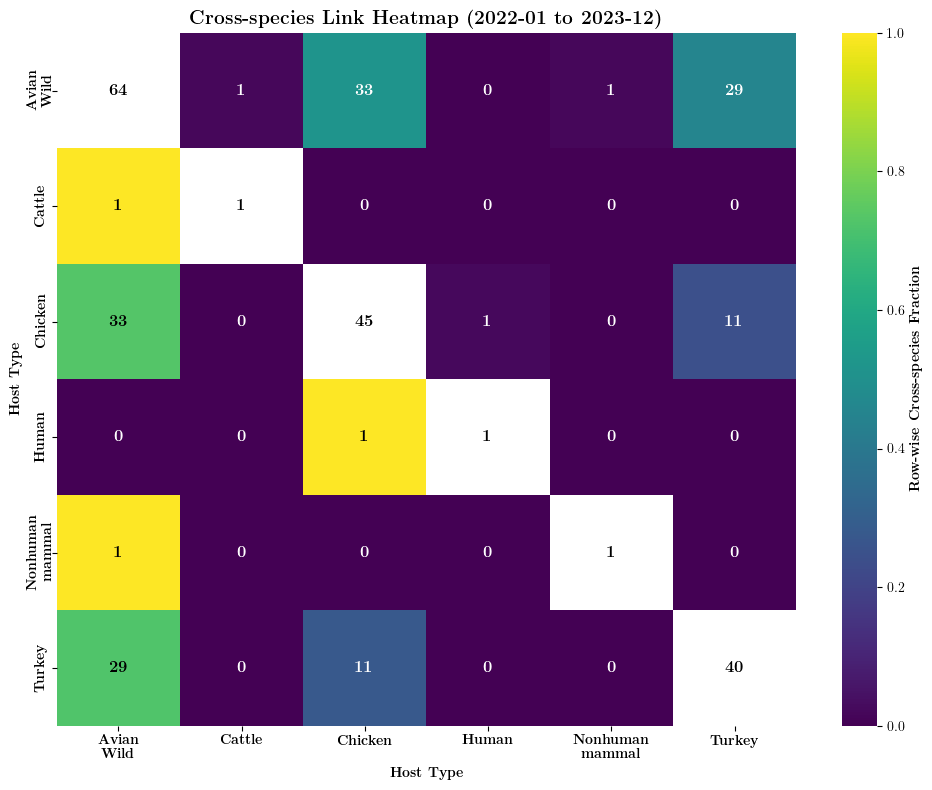

In [56]:
# Purpose: Generate a heatmap of spillover events counts of one host type by the other host type in the pair in spillover_type
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Create a list of unique host types involved in the pairwise spillovers
# This assumes spillover_type is in the format "Host1,Host2"
all_hosts = sorted(list(set(','.join(spillover_table['spillover_type'].unique()).replace(',', ' ').split())))
#remove "no host" from all_hosts
if "no" in all_hosts:
    all_hosts.remove("no")
if "host" in all_hosts:
    all_hosts.remove("host")

def generate_spillover_heatmap(data, title, heatmap_color="viridis"):
    # Create an empty matrix to store the counts
    spillover_matrix = pd.DataFrame(0, index=all_hosts, columns=all_hosts)
    #get total counts for each spillover_type
    spillover_counts = data.groupby('spillover_type')['spillover_id'].nunique()

    # Populate the matrix using spillover_counts
    for spillover_type, count in spillover_counts.items():
        hosts = sorted(spillover_type.split(','))

        if len(hosts) == 2:
            host1, host2 = hosts
            # Add count to the off-diagonal for the pair
            # For the off-diagonal, we want the count of UNIQUE spillover_ids that include both hosts in the type
            # We already grouped by spillover_type and counted unique IDs, so 'count' here is already correct for the type
            spillover_matrix.loc[host1, host2] += count
            spillover_matrix.loc[host2, host1] += count  # Matrix is symmetric for pairs

            # For the diagonal, we want the total count of UNIQUE spillover_ids for each host
            # This needs to be calculated separately based on which spillover_ids contain each host type.
            # This approach to populating the matrix will still inflate the diagonal because each pair adds to two diagonals.
            # A better approach for the diagonal is to count unique spillover_ids per host type.
 
    #remove rows that are all zeros
    #spillover_matrix = spillover_matrix.dropna(how='all', axis=0).loc[(spillover_matrix != 0).any(axis=1)]
    #spillover_matrix = spillover_matrix.dropna(how='all', axis=1).loc[:, (spillover_matrix != 0).any(axis=0)]


    # Calculate the diagonal counts correctly by counting unique spillover_ids per host type
    for host in all_hosts:
        # Find all spillover_ids that contain this host in their spillover_type
        spillover_ids_with_host = data[data['spillover_type'].str.contains(host, na=False)]['spillover_id'].unique()
        spillover_matrix.loc[host, host] = len(spillover_ids_with_host)

    to_keep = spillover_matrix.index[(spillover_matrix != 0).any(axis=1)]
    spillover_matrix = spillover_matrix.loc[to_keep, to_keep]

    # Create a matrix for the off-diagonal values as fractions
    fraction_matrix = spillover_matrix.astype(float).copy()
    for i in range(fraction_matrix.shape[0]):
        for j in range(fraction_matrix.shape[1]):
            if i != j: # Only for off-diagonal elements
                host1 = fraction_matrix.index[i]
                # Calculate fraction relative to the total spillovers involving host1
                # Avoid division by zero
                fraction_matrix.loc[host1, fraction_matrix.columns[j]] = spillover_matrix.loc[host1, fraction_matrix.columns[j]] / spillover_matrix.loc[host1, host1] if spillover_matrix.loc[host1, host1] != 0 else 0

    # Set diagonal of the fraction matrix to NaN for color scaling based on fractions
    off_diagonal_fraction_matrix = fraction_matrix.copy()
    np.fill_diagonal(off_diagonal_fraction_matrix.values, np.nan)

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(off_diagonal_fraction_matrix, annot=False, fmt='', cmap=heatmap_color, cbar_kws={'label': r"\textbf{Row-wise Cross-species Fraction}"},
                vmax=np.nanmax(off_diagonal_fraction_matrix)) # Set vmax based on the max off-diagonal fraction value
    
    # 1. The Title
    # Use double backslashes for LaTeX commands in Python strings
    plt.title(rf"\textbf{{{title}}}", fontsize=14)

    # 2. Axis Labels (if you decide to keep them)
    plt.xlabel(r"\textbf{Host Type}",fontsize=10)
    plt.ylabel(r"\textbf{Host Type}",fontsize=10)

    current_ticks = cbar.get_ticks()
    cbar.set_ticklabels([f"{t:.2f}" for t in current_ticks])

    # 3. Bold the Tick Labels (The Host Names)
    new_labels = ["\n".join([rf"\textbf{{{part.strip()}}}" for part in label.get_text().split('-')]) 
    for label in ax.get_xticklabels()
    ]
    #in new_labels replace Environment with Env
    new_labels = [label.replace("Environment", "Env") for label in new_labels]
    ax.set_xticklabels(new_labels, rotation=0, ha='center')
    new_labels = ["\n".join([rf"\textbf{{{part.strip()}}}" for part in label.get_text().split('-')]) 
    for label in ax.get_yticklabels()
    ]
    ax.set_yticklabels(new_labels, rotation=90, ha='center', position=(-0.008, 0))
    #scoot the y-axis labels to the left a bit
    plt.tight_layout()
    # Get the colormap object
    cmap = plt.get_cmap(heatmap_color)
    # Get the normalization used for the colors (vmax is what you defined earlier)
    norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(off_diagonal_fraction_matrix))

    #print plain text values of spillover_matrix
    print(f"{title} Matrix Values:")
    for i in range(spillover_matrix.shape[0]):
        for j in range(spillover_matrix.shape[1]):
            val = spillover_matrix.iloc[i, j]
            print(f"Value at ({spillover_matrix.index[i]}, {spillover_matrix.columns[j]}): {val}")

    # Manually add annotations
    for i in range(spillover_matrix.shape[0]):
        for j in range(spillover_matrix.shape[1]):
            val = spillover_matrix.iloc[i, j]
            
            if i == j: # Diagonal (usually white/empty in your fraction matrix)
                text_color = 'black'
            else: # Off-diagonal
                # 1. Get the fraction value used for the background color
                fraction_val = off_diagonal_fraction_matrix.iloc[i, j]
                
                # 2. Get the RGB color of the cell from the colormap
                rgb = cmap(norm(fraction_val))[:3] # Returns (R, G, B)
                
                # 3. Calculate luminance
                luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
                
                # 4. Choose black for bright backgrounds, white for dark
                text_color = 'black' if luminance > 0.5 else 'white'
            ax.text(j + 0.5, i + 0.5, rf"\textbf{{{int(val)}}}",
                    ha='center', va='center', 
                    color=text_color, 
                    fontsize=12)


    plt.show()

# Generate heatmaps for all genotypes, non-B3.13, and B3.13
generate_spillover_heatmap(spillover_table, 'All Genotypes: Cross-species Link Heatmap by Host Type Pair', heatmap_color="plasma")
generate_spillover_heatmap(spillover_table[spillover_table['genotype'] != 'b3.13'], 'Non-B3.13 Genotypes: Cross-species Link Heatmap by Host Type Pair', heatmap_color="plasma")
generate_spillover_heatmap(spillover_table[spillover_table['genotype'] == 'b3.13'], 'B3.13 Genotypes: Cross-species Link Heatmap by Host Type Pair', heatmap_color="plasma")

# Generate heatmaps for specified date ranges
generate_spillover_heatmap(spillover_table[(spillover_table['month'] >= '2022-01') & (spillover_table['month'] < '2025-05')], 'Cross-species Link Heatmap (2022-01 to 2025-05)')
generate_spillover_heatmap(spillover_table[(spillover_table['month'] >= '2024-01') & (spillover_table['month'] < '2025-05')], 'Cross-species Link Heatmap (2024-01 to 2025-05)')
generate_spillover_heatmap(spillover_table[(spillover_table['month'] >= '2022-01') & (spillover_table['month'] < '2023-12')], 'Cross-species Link Heatmap (2022-01 to 2023-12)')

In [ ]:
# Purpose: Display the head of the spillover_month DataFrame.
spillover_month.head()

,month,state,spillover_type,count
0,2021-07,Washington,"Avian-Wild,Human",1
1,2022-01,Idaho,"Avian-Wild,Chicken",2
2,2022-01,Indiana,"Avian-Wild,Chicken",1
3,2022-01,Iowa,"Chicken,Turkey",1
4,2022-01,Michigan,"Avian-Wild,Chicken",1


In [40]:
spillover_month2.head()

,month,state,spillover_type,genotype,count
0,2021-07,Washington,"Avian-Wild,Nonhuman-mammal",other,1
1,2021-11,Utah,"Avian-Wild,Chicken",other,1
2,2022-01,Idaho,"Avian-Wild,Chicken",other,2
3,2022-01,Indiana,"Avian-Wild,Chicken",other,1
4,2022-01,Iowa,"Chicken,Turkey",other,1


Processing Spillover Type: Avian-Wild,Cattle, Subtype: ckn-broilers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Cattle, Subtype: ckn-layers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Cattle, Subtype: dairy | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Cattle, Subtype: turkeys | Merged Data Shape: (1248, 4)
Processing Spillover Type: Cattle,Chicken, Subtype: ckn-broilers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Cattle,Chicken, Subtype: ckn-layers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Cattle,Chicken, Subtype: dairy | Merged Data Shape: (1248, 4)
Processing Spillover Type: Cattle,Chicken, Subtype: turkeys | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-broilers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-layers | Merged Data Shape: (1248, 4)
Processing Spillover Type: Avian-Wild,Chicken, Sub

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/485516927.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([rf"\textbf{{{t:.2f}}}" for t in current_ticks])


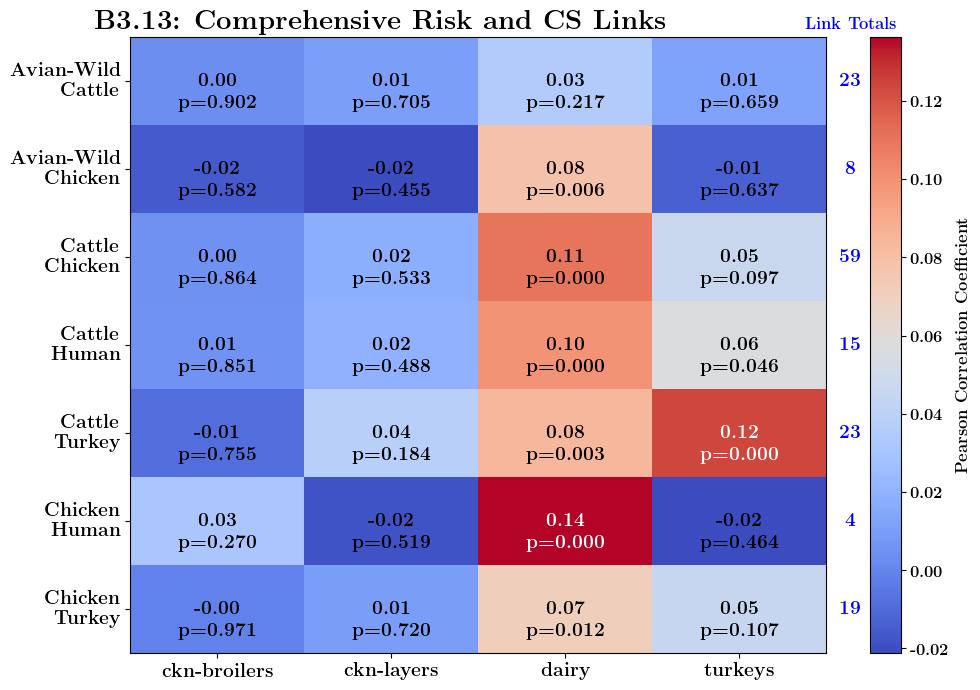


### Spillover Totals for B3.13 ###
- Type: Avian-Wild,Cattle | Total Count: 23
- Type: Avian-Wild,Chicken | Total Count: 8
- Type: Avian-Wild,Nonhuman-mammal | Total Count: 5
- Type: Cattle,Chicken | Total Count: 59
- Type: Cattle,Environment | Total Count: 3
- Type: Cattle,Human | Total Count: 15
- Type: Cattle,Nonhuman-mammal | Total Count: 33
- Type: Cattle,Turkey | Total Count: 23
- Type: Chicken,Human | Total Count: 4
- Type: Chicken,Nonhuman-mammal | Total Count: 9
- Type: Chicken,Turkey | Total Count: 19
- Type: Environment,Nonhuman-mammal | Total Count: 8
- Type: Nonhuman-mammal,Turkey | Total Count: 3


In [58]:
#Purpose: (looking at risk vs occurence) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

heatmap_color="viridis"


plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"font.serif": ["Computer Modern Roman"],
})

# 1. FILTER FIRST (Isolate B3.13)
target_genotype = spillover_month2[spillover_month2["genotype"]=="b3.13"]
spillover_totals = target_genotype.groupby('spillover_type')['count'].sum().to_dict()
#from the target_genotype df get the earliest month
earliest_month = target_genotype['month'].min()

# --- CORRELATION LOGIC (Keep as is) ---
results = []
raw_types = spillover_month2[spillover_month2["genotype"]=="b3.13"]['spillover_type'].unique()
keep_list = [i for i in raw_types if len(i.split(',')) < 3 and "Nonhuman" not in i and "Other" not in i and "Environment" not in i]

for sp_type in keep_list:
    for sub_type in st_risk_scores[st_risk_scores['subtype']!="ducks"]['subtype'].unique():
    #for sub_type in st_risk_scores[st_risk_scores['subtype']!="ducks"]['subtype'].unique():
        risk_data = st_risk_scores[st_risk_scores['subtype'] == sub_type][['month', 'state', 'risk']]
        #filter risk_data to only include months >= earliest_month
        risk_data = risk_data[risk_data['month'] >= earliest_month]
        sp_data = target_genotype[target_genotype['spillover_type'] == sp_type][['month', 'state', 'count']]
        merged = risk_data.merge(sp_data, on=['month', 'state'], how='left')
        merged['count'] = merged['count'].fillna(0)
        #print the sub_type and the dimensions of the merged dataframe
        print(f"Processing Spillover Type: {sp_type}, Subtype: {sub_type} | Merged Data Shape: {merged.shape}")
        
        if len(merged) > 1 and merged['count'].std() > 0 and merged['risk'].std() > 0:
            r, p = pearsonr(merged['count'], merged['risk'])
            results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': r, 'p_value': p})
        else:
             results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': np.nan, 'p_value': np.nan})

spillover_corr = pd.DataFrame(results)
spillover_corr_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='correlation').dropna(how='all')
spillover_pval_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='p_value').dropna(how='all')

print("\n### DATA SUMMARY B3.13 Correlation between Spillover Count and Comprehensive Risk Score - Occurrence' ###")
for _, row in spillover_corr.dropna(subset=['correlation']).iterrows():
    significance = "Significant" if row['p_value'] < 0.05 else "Not Significant"
    print(f"- Type: {row['spillover_type']}, Subtype: {row['subtype']} | "
          f"Corr: {row['correlation']:.3f}, p: {row['p_value']:.4f} ({significance})")

# --- PLOTTING LOGIC (FIXED INTERFACE) ---

# ADDED: Explicitly create fig and ax
fig, ax = plt.subplots(figsize=(12, 8)) 
ax.title.set_position([0.36, 1.05])
ax.set_title(r"\textbf{B3.13: Comprehensive Risk and CS Links}", fontsize=20)
heatmap = ax.imshow(spillover_corr_pivot, cmap='coolwarm', aspect='auto')

# Standard colorbar
cbar = plt.colorbar(heatmap, ax=ax)
#cbar set title and font size
cbar.set_label(r"\textbf{Pearson Correlation Coefficient}", fontsize=12)
current_ticks = cbar.get_ticks()
cbar.set_ticklabels([rf"\textbf{{{t:.2f}}}" for t in current_ticks])
#set colorbar font size
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(range(len(spillover_corr_pivot.columns)))
ax.set_xticklabels(spillover_corr_pivot.columns, rotation=90)
ax.set_yticks(range(len(spillover_corr_pivot.index)))
ax.set_yticklabels(spillover_corr_pivot.index)

ax.set_xticklabels([rf"\textbf{{{l.get_text()}}}" for l in ax.get_xticklabels()], rotation=0, fontsize=14)

labels = ax.get_yticklabels()

new_labels = [
    "\n".join([rf"\textbf{{{part.strip()}}}" for part in label.get_text().split(',')]) 
    for label in labels
]
ax.set_yticklabels(new_labels, rotation=0, va='center', fontsize=14)

# Add text annotations...
for i in range(spillover_corr_pivot.shape[0]):
    for j in range(spillover_corr_pivot.shape[1]):
        val = spillover_corr_pivot.iloc[i, j]
        p_val = spillover_pval_pivot.iloc[i, j]
        if not np.isnan(val):
            color = 'black' if abs(val) < 0.12 else 'white'
            ax.text(j, i, rf"\textbf{{{val:.2f}}}", ha='center', va='center', color=color, fontsize=14)
            if not np.isnan(p_val):
                ax.text(j, i+0.25, rf"\textbf{{p={p_val:.3f}}}", ha='center', va='center', color=color, fontsize=14)

# --- ADDED CODE: NEW COLUMN FOR TOTALS ---
num_cols = len(spillover_corr_pivot.columns)

# We use the ax.text coordinate system (x=columns, y=rows)
# x = num_cols - 0.5 is the right edge of the heatmap. 
# We move slightly further right (+ 0.7) to put it between heatmap and legend.
header_x = num_cols - 0.5 + 0.14

ax.text(header_x, -.6, r"\textbf{Link Totals}", fontweight='bold', ha='center', color='blue', fontsize=12)

for i, sp_type in enumerate(spillover_corr_pivot.index):
    total = spillover_totals.get(sp_type, 0)
    ax.text(header_x, i, rf"\textbf{{{int(total)}}}", 
            ha='center', va='center', fontweight='bold', color='blue', clip_on=False, fontsize=14)

# This creates extra space on the right for the new text labels
plt.subplots_adjust(right=0.85) 
plt.savefig("../results/b313_correlation_comprehensive_risk.pdf", format='pdf', bbox_inches='tight')
plt.show()

#also print out the spillover_totals dictionary
print("\n### Spillover Totals for B3.13 ###")
for sp_type, total in spillover_totals.items():
    print(f"- Type: {sp_type} | Total Count: {total}")



### DATA SUMMARY B3.13 Correlation between Spillover Count and Unconditional Risk Score - Occurrence' ###
- Type: Avian-Wild,Cattle, Subtype: ckn-broilers | Corr: -0.003, p: 0.9169 (Not Significant)
- Type: Avian-Wild,Cattle, Subtype: ckn-layers | Corr: -0.002, p: 0.9538 (Not Significant)
- Type: Avian-Wild,Cattle, Subtype: dairy | Corr: 0.058, p: 0.0411 (Significant)
- Type: Avian-Wild,Cattle, Subtype: turkeys | Corr: 0.019, p: 0.5076 (Not Significant)
- Type: Cattle,Chicken, Subtype: ckn-broilers | Corr: 0.009, p: 0.7633 (Not Significant)
- Type: Cattle,Chicken, Subtype: ckn-layers | Corr: 0.031, p: 0.2812 (Not Significant)
- Type: Cattle,Chicken, Subtype: dairy | Corr: 0.142, p: 0.0000 (Significant)
- Type: Cattle,Chicken, Subtype: turkeys | Corr: 0.068, p: 0.0157 (Significant)
- Type: Avian-Wild,Chicken, Subtype: ckn-broilers | Corr: -0.018, p: 0.5241 (Not Significant)
- Type: Avian-Wild,Chicken, Subtype: ckn-layers | Corr: -0.007, p: 0.8139 (Not Significant)
- Type: Avian-Wild,Ch

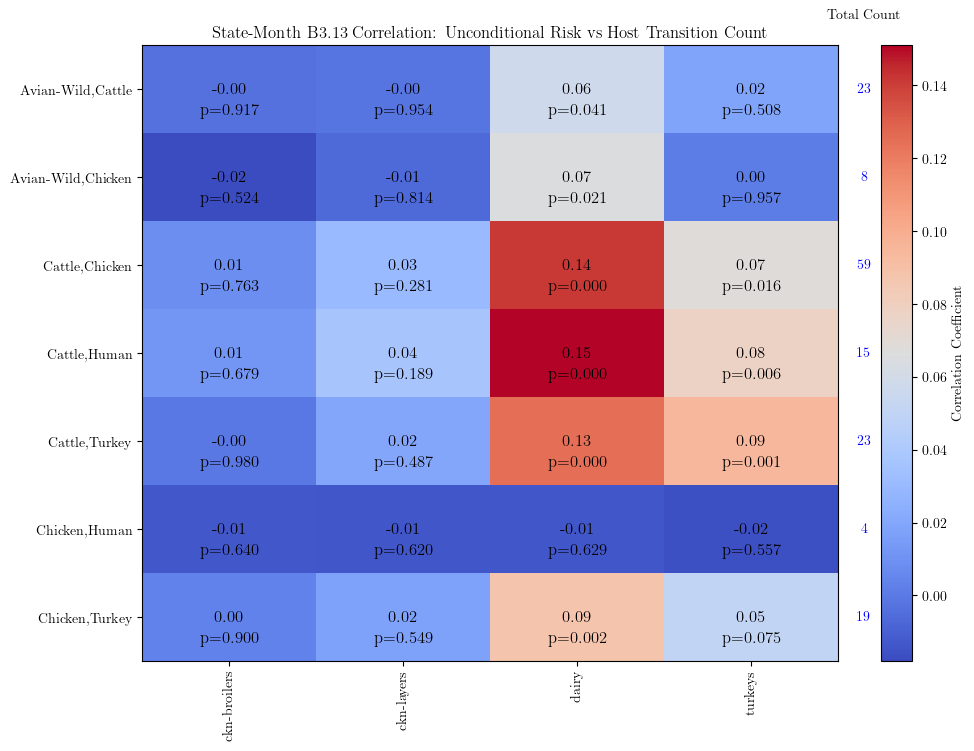


### Spillover Totals for B3.13 ###
- Type: Avian-Wild,Cattle | Total Count: 23
- Type: Avian-Wild,Chicken | Total Count: 8
- Type: Avian-Wild,Nonhuman-mammal | Total Count: 5
- Type: Cattle,Chicken | Total Count: 59
- Type: Cattle,Environment | Total Count: 3
- Type: Cattle,Human | Total Count: 15
- Type: Cattle,Nonhuman-mammal | Total Count: 33
- Type: Cattle,Turkey | Total Count: 23
- Type: Chicken,Human | Total Count: 4
- Type: Chicken,Nonhuman-mammal | Total Count: 9
- Type: Chicken,Turkey | Total Count: 19
- Type: Environment,Nonhuman-mammal | Total Count: 8
- Type: Nonhuman-mammal,Turkey | Total Count: 3


In [59]:
#Purpose: investigating purpose of NaNs (looking at risk vs occurence) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

heatmap_color="viridis"

# 1. FILTER FIRST (Isolate B3.13)
target_genotype = spillover_month2[spillover_month2["genotype"]=="b3.13"]
spillover_totals = target_genotype.groupby('spillover_type')['count'].sum().to_dict()
earliest_month = target_genotype['month'].min()

# --- CORRELATION LOGIC (Keep as is) ---
results = []
raw_types = spillover_month2[spillover_month2["genotype"]=="b3.13"]['spillover_type'].unique()
keep_list = [i for i in raw_types if len(i.split(',')) < 3 and "Nonhuman" not in i and "Other" not in i and "Environment" not in i]

for sp_type in keep_list:
    for sub_type in unc_risk_scores[unc_risk_scores['subtype']!='ducks']['subtype'].unique():
        risk_data = unc_risk_scores[unc_risk_scores['subtype'] == sub_type][['month', 'state', 'risk']]
        #filter risk_data to only include months >= earliest_month
        risk_data = risk_data[risk_data['month'] >= earliest_month]
        sp_data = target_genotype[target_genotype['spillover_type'] == sp_type][['month', 'state', 'count']]
        merged = risk_data.merge(sp_data, on=['month', 'state'], how='left')
        merged['count'] = merged['count'].fillna(0)
        
        if len(merged) > 1 and merged['count'].std() > 0 and merged['risk'].std() > 0:
            r, p = pearsonr(merged['count'], merged['risk'])
            results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': r, 'p_value': p})
        else:
             results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': np.nan, 'p_value': np.nan})

spillover_corr = pd.DataFrame(results)
spillover_corr_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='correlation').dropna(how='all')
spillover_pval_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='p_value').dropna(how='all')

print("\n### DATA SUMMARY B3.13 Correlation between Spillover Count and Unconditional Risk Score - Occurrence' ###")
for _, row in spillover_corr.dropna(subset=['correlation']).iterrows():
    significance = "Significant" if row['p_value'] < 0.05 else "Not Significant"
    print(f"- Type: {row['spillover_type']}, Subtype: {row['subtype']} | "
          f"Corr: {row['correlation']:.3f}, p: {row['p_value']:.4f} ({significance})")

# --- PLOTTING LOGIC (FIXED INTERFACE) ---

# ADDED: Explicitly create fig and ax
fig, ax = plt.subplots(figsize=(12, 8)) 

ax.set_title('State-Month B3.13 Correlation: Unconditional Risk vs Host Transition Count')
heatmap = ax.imshow(spillover_corr_pivot, cmap='coolwarm', aspect='auto')

# Standard colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Correlation Coefficient')

ax.set_xticks(range(len(spillover_corr_pivot.columns)))
ax.set_xticklabels(spillover_corr_pivot.columns, rotation=90)
ax.set_yticks(range(len(spillover_corr_pivot.index)))
ax.set_yticklabels(spillover_corr_pivot.index)

# Add text annotations...
for i in range(spillover_corr_pivot.shape[0]):
    for j in range(spillover_corr_pivot.shape[1]):
        val = spillover_corr_pivot.iloc[i, j]
        p_val = spillover_pval_pivot.iloc[i, j]
        if not np.isnan(val):
            color = 'black' if abs(val) < 0.5 else 'white'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=12)
            if not np.isnan(p_val):
                ax.text(j, i+0.25, f"p={p_val:.3f}", ha='center', va='center', color=color, fontsize=12)

# --- ADDED CODE: NEW COLUMN FOR TOTALS ---
num_cols = len(spillover_corr_pivot.columns)

# We use the ax.text coordinate system (x=columns, y=rows)
# x = num_cols - 0.5 is the right edge of the heatmap. 
# We move slightly further right (+ 0.7) to put it between heatmap and legend.
header_x = num_cols - 0.5 + 0.15

ax.text(header_x, -.8, 'Total Count', fontweight='bold', ha='center', color='black')

for i, sp_type in enumerate(spillover_corr_pivot.index):
    total = spillover_totals.get(sp_type, 0)
    ax.text(header_x, i, f"{int(total)}", 
            ha='center', va='center', fontweight='bold', color='blue', clip_on=False)

# This creates extra space on the right for the new text labels
plt.subplots_adjust(right=0.85) 
plt.show()

#also print out the spillover_totals dictionary
print("\n### Spillover Totals for B3.13 ###")
for sp_type, total in spillover_totals.items():
    print(f"- Type: {sp_type} | Total Count: {total}")

Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: dairy | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: turkeys | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: dairy | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: turkeys | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey,

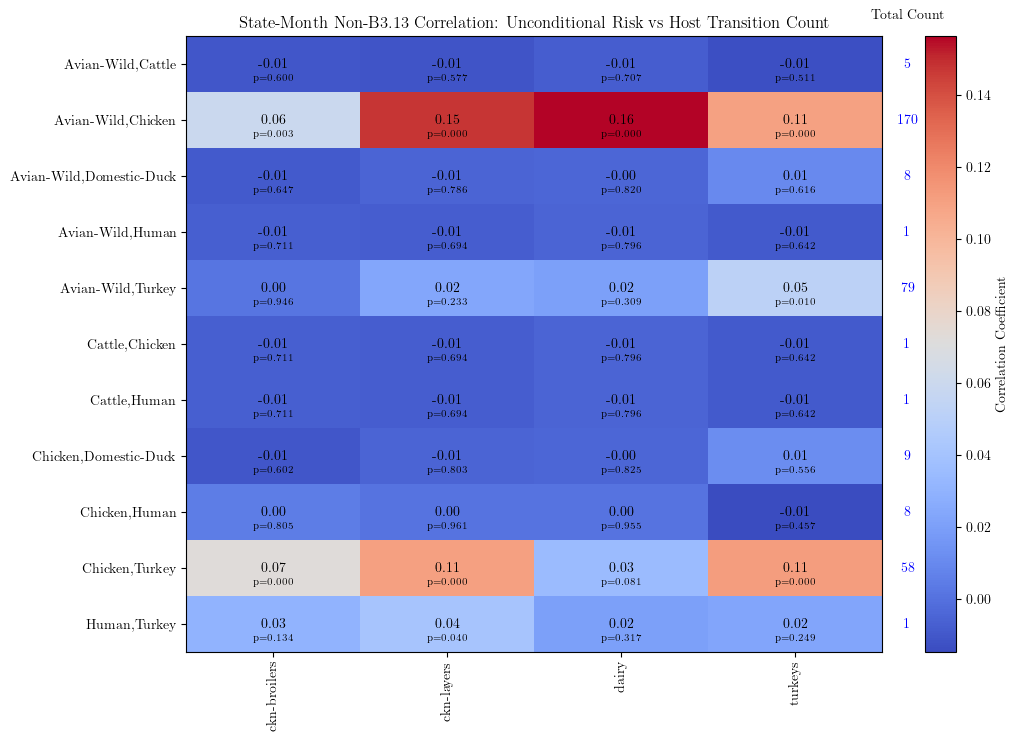


### Spillover Totals for B3.13 ###
- Type: Avian-Domestic-Other,Avian-Wild | Total Count: 4
- Type: Avian-Domestic-Other,Chicken | Total Count: 2
- Type: Avian-Domestic-Other,Nonhuman-mammal | Total Count: 1
- Type: Avian-Domestic-Other,Turkey | Total Count: 1
- Type: Avian-Wild,Cattle | Total Count: 5
- Type: Avian-Wild,Chicken | Total Count: 170
- Type: Avian-Wild,Domestic-Duck | Total Count: 8
- Type: Avian-Wild,Human | Total Count: 1
- Type: Avian-Wild,Nonhuman-mammal | Total Count: 19
- Type: Avian-Wild,Turkey | Total Count: 79
- Type: Cattle,Chicken | Total Count: 1
- Type: Cattle,Human | Total Count: 1
- Type: Chicken,Domestic-Duck | Total Count: 9
- Type: Chicken,Human | Total Count: 8
- Type: Chicken,Nonhuman-mammal | Total Count: 6
- Type: Chicken,Turkey | Total Count: 58
- Type: Human,Turkey | Total Count: 1
- Type: Nonhuman-mammal,Turkey | Total Count: 2


In [60]:
#Purpose: investigating purpose of NaNs (looking at risk vs occurence) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

heatmap_color="viridis"

# 1. FILTER FIRST (Isolate B3.13)
target_genotype = spillover_month2[spillover_month2["genotype"]=="other"]
spillover_totals = target_genotype.groupby('spillover_type')['count'].sum().to_dict()
earliest_month = target_genotype['month'].min()


# --- CORRELATION LOGIC (Keep as is) ---
results = []
raw_types = spillover_month2[spillover_month2["genotype"]=="other"]['spillover_type'].unique()
keep_list = [i for i in raw_types if len(i.split(',')) < 3 and "Nonhuman" not in i and "Other" not in i and "Environment" not in i]

for sp_type in keep_list:
    for sub_type in unc_risk_scores[unc_risk_scores['subtype']!='ducks']['subtype'].unique():
    #for sub_type in unc_risk_scores['subtype'].unique():
        risk_data = unc_risk_scores[unc_risk_scores['subtype'] == sub_type][['month', 'state', 'risk']]
        risk_data = risk_data[risk_data['month'] >= earliest_month]
        sp_data = target_genotype[target_genotype['spillover_type'] == sp_type][['month', 'state', 'count']]
        merged = risk_data.merge(sp_data, on=['month', 'state'], how='left')
        merged['count'] = merged['count'].fillna(0)
        print(f"Processing Spillover Type: {sp_type}, Subtype: {sub_type} | Merged Data Shape: {merged.shape}")

        
        if len(merged) > 1 and merged['count'].std() > 0 and merged['risk'].std() > 0:
            r, p = pearsonr(merged['count'], merged['risk'])
            results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': r, 'p_value': p})
        else:
             results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': np.nan, 'p_value': np.nan})

spillover_corr = pd.DataFrame(results)
spillover_corr_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='correlation').dropna(how='all')
spillover_pval_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='p_value').dropna(how='all')

print("\n### DATA SUMMARY Non-B3.13 Correlation between Spillover Count and Unconditional Risk Score - Occurrence' ###")
for _, row in spillover_corr.dropna(subset=['correlation']).iterrows():
    significance = "Significant" if row['p_value'] < 0.05 else "Not Significant"
    print(f"- Type: {row['spillover_type']}, Subtype: {row['subtype']} | "
          f"Corr: {row['correlation']:.3f}, p: {row['p_value']:.4f} ({significance})")

# --- PLOTTING LOGIC (FIXED INTERFACE) ---

# ADDED: Explicitly create fig and ax
fig, ax = plt.subplots(figsize=(12, 8)) 

ax.set_title('State-Month Non-B3.13 Correlation: Unconditional Risk vs Host Transition Count')
heatmap = ax.imshow(spillover_corr_pivot, cmap='coolwarm', aspect='auto')

# Standard colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Correlation Coefficient')

ax.set_xticks(range(len(spillover_corr_pivot.columns)))
ax.set_xticklabels(spillover_corr_pivot.columns, rotation=90)
ax.set_yticks(range(len(spillover_corr_pivot.index)))
ax.set_yticklabels(spillover_corr_pivot.index)

# Add text annotations...
for i in range(spillover_corr_pivot.shape[0]):
    for j in range(spillover_corr_pivot.shape[1]):
        val = spillover_corr_pivot.iloc[i, j]
        p_val = spillover_pval_pivot.iloc[i, j]
        if not np.isnan(val):
            color = 'black' if abs(val) < 0.5 else 'white'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=color)
            if not np.isnan(p_val):
                ax.text(j, i+0.25, f"p={p_val:.3f}", ha='center', va='center', color=color, fontsize=7)

# --- ADDED CODE: NEW COLUMN FOR TOTALS ---
num_cols = len(spillover_corr_pivot.columns)

# We use the ax.text coordinate system (x=columns, y=rows)
# x = num_cols - 0.5 is the right edge of the heatmap. 
# We move slightly further right (+ 0.7) to put it between heatmap and legend.
header_x = num_cols - 0.5 + 0.15

ax.text(header_x, -.8, 'Total Count', fontweight='bold', ha='center', color='black')

for i, sp_type in enumerate(spillover_corr_pivot.index):
    total = spillover_totals.get(sp_type, 0)
    ax.text(header_x, i, f"{int(total)}", 
            ha='center', va='center', fontweight='bold', color='blue', clip_on=False)

# This creates extra space on the right for the new text labels
plt.subplots_adjust(right=0.85) 
plt.show()

#also print out the spillover_totals dictionary
print("\n### Spillover Totals for B3.13 ###")
for sp_type, total in spillover_totals.items():
    print(f"- Type: {sp_type} | Total Count: {total}")

Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: dairy | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Chicken, Subtype: turkeys | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: dairy | Merged Data Shape: (2496, 4)
Processing Spillover Type: Avian-Wild,Turkey, Subtype: turkeys | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey, Subtype: ckn-broilers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey, Subtype: ckn-layers | Merged Data Shape: (2496, 4)
Processing Spillover Type: Chicken,Turkey,

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_68234/245372728.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([rf"\textbf{{{t:.2f}}}" for t in current_ticks])


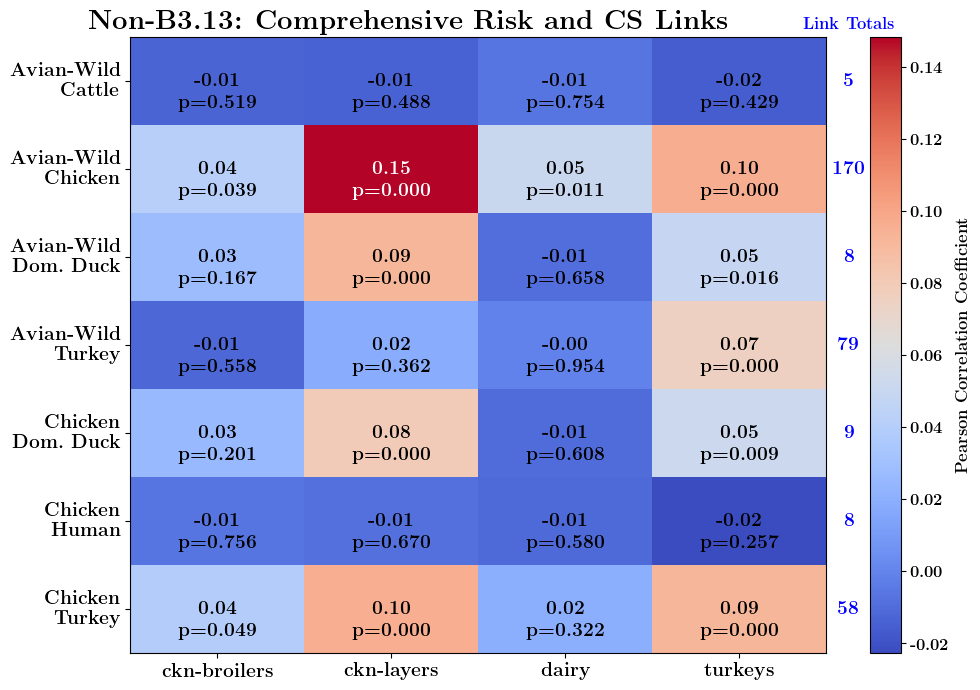


### Spillover Totals for B3.13 ###
- Type: Avian-Domestic-Other,Avian-Wild | Total Count: 4
- Type: Avian-Domestic-Other,Chicken | Total Count: 2
- Type: Avian-Domestic-Other,Nonhuman-mammal | Total Count: 1
- Type: Avian-Domestic-Other,Turkey | Total Count: 1
- Type: Avian-Wild,Cattle | Total Count: 5
- Type: Avian-Wild,Chicken | Total Count: 170
- Type: Avian-Wild,Domestic-Duck | Total Count: 8
- Type: Avian-Wild,Human | Total Count: 1
- Type: Avian-Wild,Nonhuman-mammal | Total Count: 19
- Type: Avian-Wild,Turkey | Total Count: 79
- Type: Cattle,Chicken | Total Count: 1
- Type: Cattle,Human | Total Count: 1
- Type: Chicken,Domestic-Duck | Total Count: 9
- Type: Chicken,Human | Total Count: 8
- Type: Chicken,Nonhuman-mammal | Total Count: 6
- Type: Chicken,Turkey | Total Count: 58
- Type: Human,Turkey | Total Count: 1
- Type: Nonhuman-mammal,Turkey | Total Count: 2


In [61]:
#Purpose: investigating purpose of NaNs (looking at risk vs occurence) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

heatmap_color="viridis"


plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"font.serif": ["Computer Modern Roman"],
})

# 1. FILTER FIRST (Isolate B3.13)
target_genotype = spillover_month2[spillover_month2["genotype"]!="b3.13"]
spillover_totals = target_genotype.groupby('spillover_type')['count'].sum().to_dict()
earliest_month = target_genotype['month'].min()

# --- CORRELATION LOGIC (Keep as is) ---
results = []
raw_types = spillover_month2[spillover_month2["genotype"]!="b3.13"]['spillover_type'].unique()
keep_list = [i for i in raw_types if len(i.split(',')) < 3 and "Nonhuman" not in i and "Other" not in i and "Environment" not in i 
             and "Cattle,Chicken" not in i and "Cattle,Human" not in i and "Avian-Wild,Human" not in i and "Human,Turkey" not in i]

for sp_type in keep_list:
    for sub_type in st_risk_scores[st_risk_scores['subtype']!="ducks"]['subtype'].unique():
    #for sub_type in st_risk_scores['subtype'].unique():
        risk_data = st_risk_scores[st_risk_scores['subtype'] == sub_type][['month', 'state', 'risk']]
        risk_data = risk_data[risk_data['month'] >= earliest_month]
        sp_data = target_genotype[target_genotype['spillover_type'] == sp_type][['month', 'state', 'count']]
        merged = risk_data.merge(sp_data, on=['month', 'state'], how='left')
        merged['count'] = merged['count'].fillna(0)
        print(f"Processing Spillover Type: {sp_type}, Subtype: {sub_type} | Merged Data Shape: {merged.shape}")

        if "Cattle" in sp_type:
            print(sp_type)
        if (len(merged) > 1 and merged['count'].std() > 0 and merged['risk'].std() > 0):
            r, p = pearsonr(merged['count'], merged['risk'])
            results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': r, 'p_value': p})
        else:
             results.append({'spillover_type': sp_type, 'subtype': sub_type, 'correlation': np.nan, 'p_value': np.nan})

spillover_corr = pd.DataFrame(results)
spillover_corr_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='correlation').dropna(how='all')
spillover_pval_pivot = spillover_corr.pivot(index='spillover_type', columns='subtype', values='p_value').dropna(how='all')

print("\n### DATA SUMMARY B3.13 Correlation between Spillover Count and Comprehensive Risk Score - Occurrence' ###")
for _, row in spillover_corr.dropna(subset=['correlation']).iterrows():
    significance = "Significant" if row['p_value'] < 0.05 else "Not Significant"
    print(f"- Type: {row['spillover_type']}, Subtype: {row['subtype']} | "
          f"Corr: {row['correlation']:.3f}, p: {row['p_value']:.4f} ({significance})")

# --- PLOTTING LOGIC (FIXED INTERFACE) ---

# ADDED: Explicitly create fig and ax
fig, ax = plt.subplots(figsize=(12, 8)) 
#make the title left aligned but also bump it out a little to the right
ax.title.set_position([0.40, 1.05])

ax.set_title(r"\textbf{Non-B3.13: Comprehensive Risk and CS Links}", fontsize=20)
heatmap = ax.imshow(spillover_corr_pivot, cmap='coolwarm', aspect='auto')

# Standard colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label(r"\textbf{Pearson Correlation Coefficient}", fontsize=12)
current_ticks = cbar.get_ticks()
cbar.set_ticklabels([rf"\textbf{{{t:.2f}}}" for t in current_ticks])
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(range(len(spillover_corr_pivot.columns)))
ax.set_xticklabels(spillover_corr_pivot.columns, rotation=90)
ax.set_yticks(range(len(spillover_corr_pivot.index)))
#ax.set_yticklabels(spillover_corr_pivot.index)
#set yticklabels to be spillover_corr_pivot.index but replace Domestic-Duck with Dom. Duck
new_yticklabels = [label.replace("Domestic-Duck", "Dom.~Duck") for label in spillover_corr_pivot.index]
ax.set_yticklabels(new_yticklabels)

ax.set_xticklabels([rf"\textbf{{{l.get_text()}}}" for l in ax.get_xticklabels()], rotation=0, fontsize=14)
#ax.set_yticklabels([rf"\textbf{{{l.get_text()}}}" for l in ax.get_yticklabels()])

labels = ax.get_yticklabels()

new_labels = [
    "\n".join([rf"\textbf{{{part.strip()}}}" for part in label.get_text().split(',')]) 
    for label in labels
]

ax.set_yticklabels(new_labels, rotation=0, va='center', fontsize=14)

# Add text annotations...
for i in range(spillover_corr_pivot.shape[0]):
    for j in range(spillover_corr_pivot.shape[1]):
        val = spillover_corr_pivot.iloc[i, j]
        p_val = spillover_pval_pivot.iloc[i, j]
        if not np.isnan(val):
            color = 'black' if abs(val) < 0.12 else 'white'
            ax.text(j, i, rf"\textbf{{{val:.2f}}}", ha='center', va='center', color=color, fontsize=14)
            if not np.isnan(p_val):
                ax.text(j, i+0.25, rf"\textbf{{p={p_val:.3f}}}", ha='center', va='center', color=color, fontsize=14)

# --- ADDED CODE: NEW COLUMN FOR TOTALS ---
num_cols = len(spillover_corr_pivot.columns)

# We use the ax.text coordinate system (x=columns, y=rows)
# x = num_cols - 0.5 is the right edge of the heatmap. 
# We move slightly further right (+ 0.7) to put it between heatmap and legend.
header_x = num_cols - 0.5 + 0.13

ax.text(header_x, -.6, r"\textbf{Link Totals}", fontweight='bold', ha='center', color='blue', fontsize=12)

for i, sp_type in enumerate(spillover_corr_pivot.index):
    total = spillover_totals.get(sp_type, 0)
    ax.text(header_x, i, rf"\textbf{{{int(total)}}}", 
            ha='center', va='center', fontweight='bold', color='blue', clip_on=False, fontsize=14)

# This creates extra space on the right for the new text labels
plt.subplots_adjust(right=0.85) 
#save as PDF
plt.savefig("../results/non_b313_correlation_comprehensive_risk.pdf", format='pdf', bbox_inches='tight')
plt.show()
#also print out the spillover_totals dictionary
print("\n### Spillover Totals for B3.13 ###")
for sp_type, total in spillover_totals.items():
    print(f"- Type: {sp_type} | Total Count: {total}")